In [ ]:
# In this attempt, we will try to accomplish the following  deterministically or stochastically:
# 1) Predict the dimensions of the tests
# 2) Predict the set of output values of tests
# From here, use the prior knowledge to
# 3) predict the tuples of transformation of the tests
# 4) then predict the tests by offering 3 candidate solutions

# The current attempt is more formalized in terms of prior knoweldge
# We will have to ground serious set operations and sequence completion
# algorithms, we already started this

In [1]:
# Factors for predicting dimensions
# Factors for predicting the outputs
from ARCsolver import *

In [2]:
from pathlib import Path
data_path = Path("/home/hshallal/Desktop/ARCsolver/data/")
training_path = data_path / 'training'
tt = load_set(training_path)

In [3]:
this_analysis = []
for n in range(len(tt)):
    #print(n)
    this_task = ARCsolver(tt[n])
    this_analysis.append(this_task)

In [4]:
# for classic prior knowledge
deduced = 0
for n in this_analysis:
    if n.dimension_status == 'deduced':
        deduced += 1
deduced # 363, 362, 361, 360

360

In [ ]:
# case 14: must allow singles of different colors to make shape

In [36]:
# this_object_data: 0:5 
# [vals[target_ind], counts[target_ind], vals[max_index], counts[max_index], vals[min_index],  counts[min_index],  len(vals), sum(counts)]
#        6                 7                 8               9                 10                11                 12           13     

# 30
# is_out_in_rel: True, (True, [(0, (2, 3))], 'contraction')
# is_out_obj_in_in_objs: [(True, 0)]
# overall_movement: [(True, (2, 3))]
# 299
# (True, [(0, (1, 1))], 'contraction')
# is_out_obj_in_in_objs: [(True, 2)]
# overall_movement: [(True, (1, 1))]

# 38: (True, [(0, (2, 2)), (5, (2, 5)), (3, (5, 2)), (2, (5, 5))], 'contraction'): output upper corner of an object
# 66: (True, [(0, (0, 0)), (3, (0, 3)), (0, (0, 6))], 'contraction'): output left or right half
# 82: (True, [(0, (0, 0)), (4, (0, 4)), (0, (3, 0)), (4, (3, 4))], 'expansion'): here, we 
# just initiate zero, add the input to the first quarter, and the 4 rotame in the second
# quarter, etc, notice, the order of populating rotamers may change with in the same case
# output more predictions or go with the consensus
# 105: (True, [(0, (0, 0)), (3, (0, 2)), (3, (2, 0)), (0, (2, 2))], 'expansion') same as above
# 115: (True, [(6, (0, 0)), (0, (3, 0))], 'expansion')
# 141: (True, [(0, (0, 0)), (7, (0, 3)), (6, (3, 0)), (4, (3, 3))], 'expansion')
# 151: (True, [(0, (0, 0)), (7, (0, 3)), (6, (3, 0)), (4, (3, 3))], 'expansion')
# 163 (True, [(0, (0, 0)), (7, (0, 3))], 'expansion')
# 103: (True, [(0, (0, 0)), (5, (0, 3)), (3, (3, 0)), (4, (3, 3))], 'expansion')
# 209: (True, [(0, (0, 0)), (6, (3, 0))], 'expansion')
# 210 (True, [(4, (0, 0)), (0, (0, 2)), (4, (3, 0)), (0, (3, 2)), (4, (6, 0)), (0, (6, 2))], 'expansion')
# last one is quite interesting
# 230: special case of 210, (True, [(0, (0, 0)), (7, (0, 1)), (0, (0, 2)), (7, (0, 3)), (0, (0, 4)), (7, (0, 5)), (0, (0, 6))], 'expansion')
# 241: (True, [(5, (4, 8)), (7, (5, 9)), (6, (8, 4)), (4, (8, 9)), (3, (9, 5)), (2, (9, 8))], 'contraction')
# last one is an indication the output is a transform of many parts of the rest
# 248: (True, [(0, (0, 0)), (0, (0, 3))], 'expansion')
# 204 (True, [(0, (0, 0))], 'expansion') is unacceptable
# 309: (True, [(0, (5, 5))], 'contraction')
# is_out_obj_in_in_objs: [(True, 40), (True, 54), (True, 64), (True, 81)]
# overall_movement: [(True, (5, 5)), (True, (5, 5)), (True, (5, -1)), (True, (5, 5))]
# output is the largest object starts with 5, 5
# 310: simple expansion (True, [(0, (0, 0)), (7, (0, 3))], 'expansion')


# 48 output the smallest [True, 0]
# [11, 21, 0, 10, 10, 10, 2, 72, 2, 72, 2, 72, 1, 72]
# [0, 10, 0, 10, 10, 10, 2, 72, 2, 72, 2, 72, 1, 72]
# 121: basic object movement to check and apply right away (same dim couple)
# here multiple movements may be recommended, stick to the options you have

# 139 solved with flips show as: overall_movement: [(True, (-1, -1))]
# 
def is_out_obj_in_in_objs(out_obj, in_objs):
    for obj in range(len(in_objs)):
        if in_objs[obj][4:14] == out_obj[4:14]:
            return True, obj
    return False, -1

def is_out_obj_shape_in_in_objs(out_obj, in_objs):
    for obj in range(len(in_objs)):
        if in_objs[obj][4:6] == out_obj[4:6] and in_objs[obj][7:8] == out_obj[7:8] and in_objs[obj][9:10] == out_obj[9:10] and in_objs[obj][11:14] == out_obj[11:14] :
            return True, obj
    return False, -1

def direct_obj_movement_detection(out_obj, in_objs):
    is_in, ind = is_out_obj_in_in_objs(out_obj, in_objs)
    if is_in:
        # Test movement
        is_move_vert = in_objs[ind][0] != out_obj[0]
        is_move_hori = in_objs[ind][2] != out_obj[2]
        if is_move_vert or is_move_hori:
            return True, (in_objs[ind][0] - out_obj[0], in_objs[ind][2] - out_obj[2])
    return False, ()
    
def overall_movement(out_objs, in_objs):
    moved = []
    for n in range(len(out_objs)):
        moved.append(direct_obj_movement_detection(out_objs[n], in_objs))
    return moved


In [ ]:
# objects in input are either selected or discarded.

In [8]:
def test_create(n):
    this_task = ARCsolver(tt[n])
    return this_task.is_same_dim_couple

In [10]:
test_create(0)

False

0
expansion [[0, 4, 0, 0, 4, 0, 4, 0, 0, 4, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0, 0, 0], [0, 7, 0, 7, 0, 0, 7, 0]] [[(0, 3), (0, 4), (0, 6), (3, 0), (3, 1), (3, 3), (3, 4), (3, 6), (6, 3), (6, 4), (6, 6)], [(0, 0), (0, 6), (6, 3)], [(3, 6), (6, 0), (6, 6)], [(0, 0), (0, 3), (3, 0), (6, 3), (6, 6)], [(0, 0), (0, 1), (0, 3), (0, 4), (0, 6), (6, 3), (6, 4), (6, 6)]]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


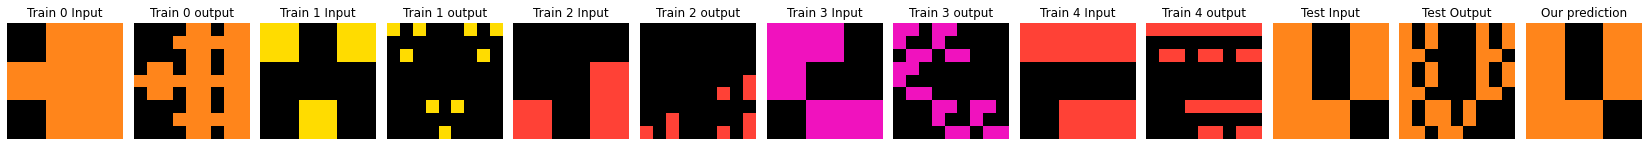

=====
2
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


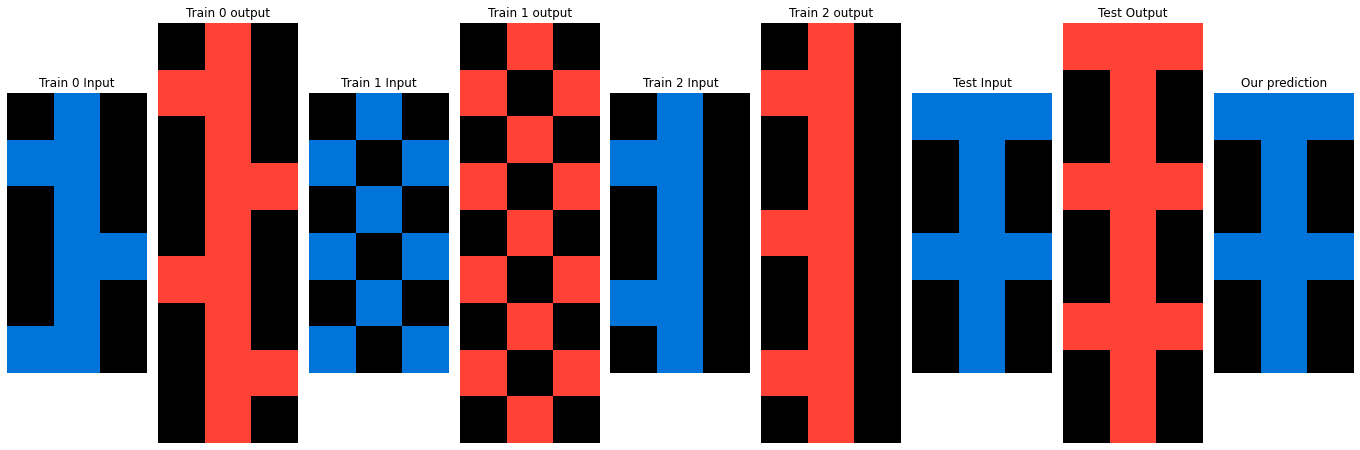

=====
5
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


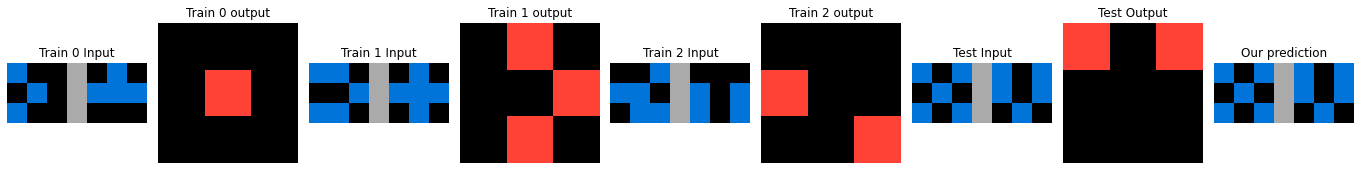

=====
13
contraction [[0], [0], [0]] [[(11, 0)], [(11, 10)], [(10, 0)]]
is_out_obj_in_in_objs: [(True, 0)]
is_in_obj_in_out_objs: [(True, 0), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (False, -1), (False, -1), (False, -1)]
overall_movement: [(True, (11, 0))]


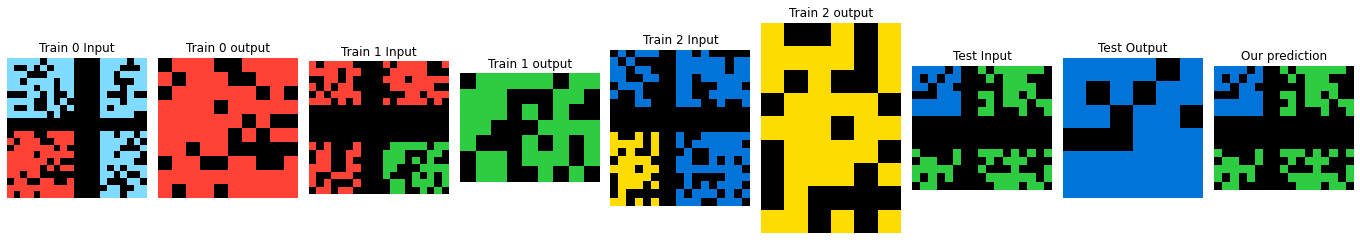

=====
18
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0)]
is_in_obj_in_out_objs: [(True, 4)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (True, (0, -4)), (False, ()), (False, ()), (False, ()), (False, ()), (True, (-2, 0)), (True, (-2, -4))]


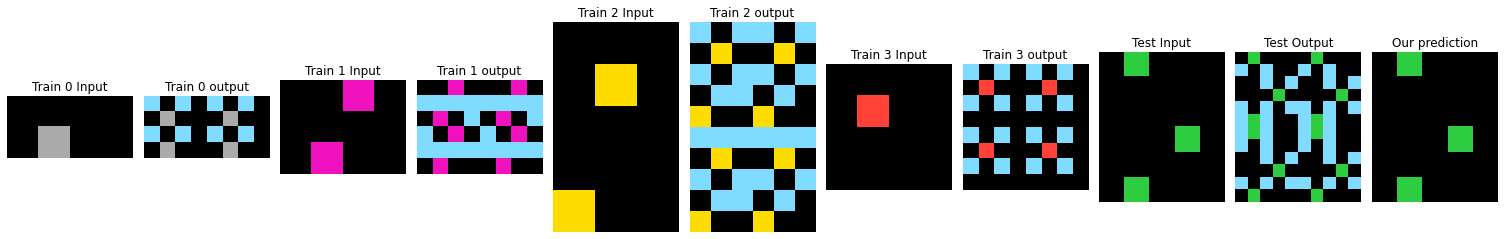

=====
20
contraction [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]] [[(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (9, 2), (9, 3), (9, 4), (9, 5), (9, 6), (10, 2), (10, 3), (10, 4), (10, 5), (10, 6), (11, 2), (11, 3), (11, 4), (11, 5), (11, 6), (12, 2), (12, 3), (12, 4), (12, 5), (12, 6), (13, 2), (13, 3), (13, 4), (13, 5), (13, 6)], [(0, 0), (0, 1), (0, 2), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (4, 0), (4, 1), (4, 

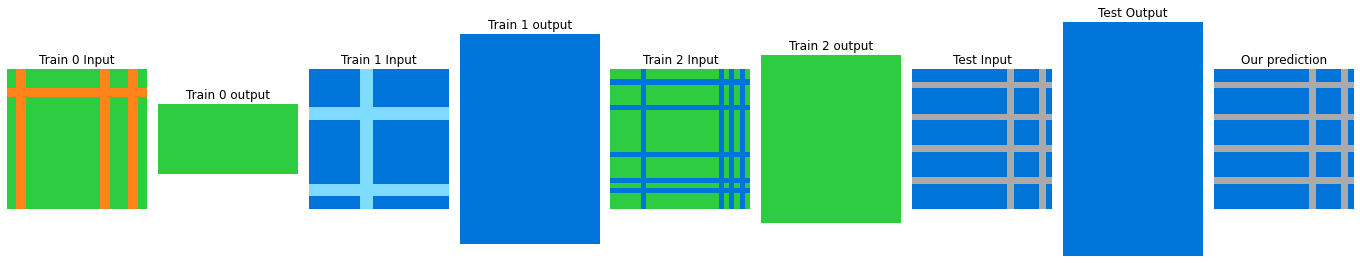

=====
21
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(True, 0), (True, 1), (True, 2), (True, 3)]
is_in_obj_in_out_objs: [(True, 0), (True, 1), (True, 2), (True, 3), (True, 3), (True, 3)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 1), (True, 1), (True, 3)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 1), (True, 1), (True, 3), (True, 3), (True, 3)]
overall_movement: [(True, (7, 4)), (True, (1, 2)), (True, (1, 6)), (True, (1, 6))]


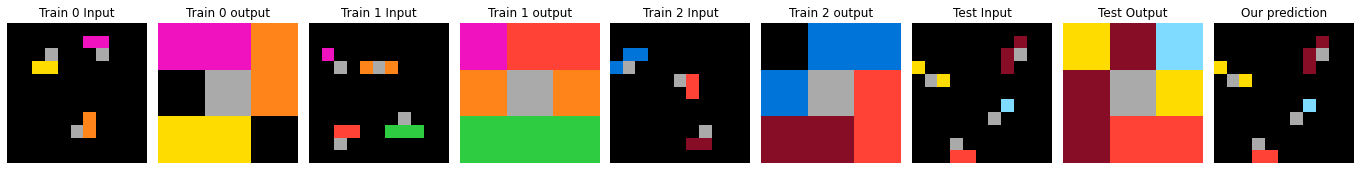

=====
25
non_dimension_related [[], [], [], [], []] [[], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 3)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 0), (False, -1)]
overall_movement: [(False, ())]


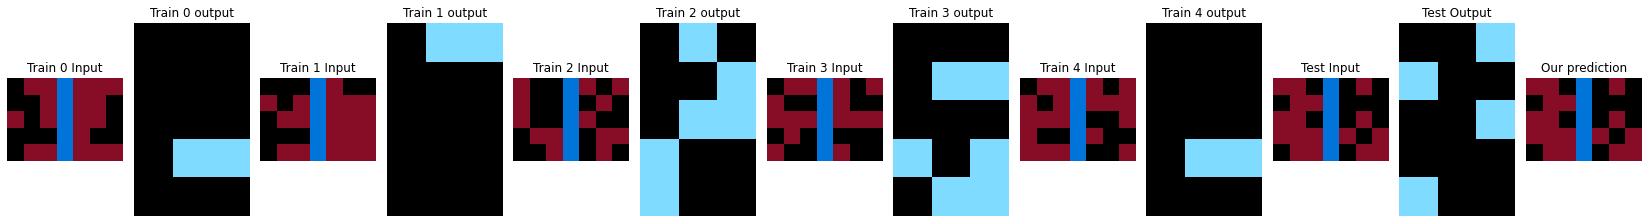

=====
28
contraction [[0], [0], [0]] [[(4, 5)], [(7, 3)], [(3, 4)]]
is_out_obj_in_in_objs: [(True, 8), (True, 14), (True, 10), (True, 18), (True, 11), (True, 36), (True, 52), (True, 50), (True, 50), (True, 49), (True, 50), (True, 52), (True, 130)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (False, -1), (True, 2), (True, 4), (False, -1), (True, 2), (True, 1), (True, 4), (True, 1), (True, 4), (True, 3), (False, -1), (True, 2), (True, 1), (True, 1), (False, -1), (False, -1), (True, 2), (False, -1), (True, 2), (True, 1), (True, 4), (False, -1), (True, 4), (True, 4), (False, -1), (False, -1), (True, 2), (True, 5), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 9), (True, 7), (False, -1), (True, 6), (True, 9), (False, -1), (True, 6), (False, -1), (True, 6), (True, 6), (True, 9), (Tru

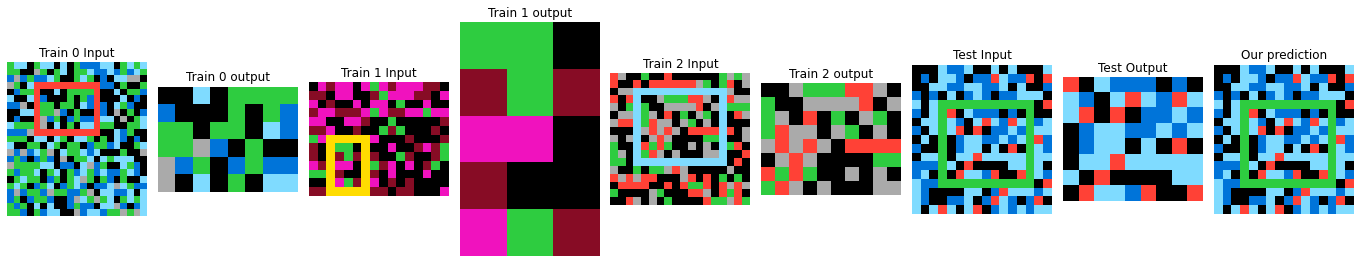

=====
30
contraction [[0], [0], [0]] [[(2, 3)], [(1, 2)], [(3, 3)]]
is_out_obj_in_in_objs: [(True, 0)]
is_in_obj_in_out_objs: [(True, 0)]
is_out_obj_shape_in_in_objs: [(True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0)]
overall_movement: [(True, (2, 3))]


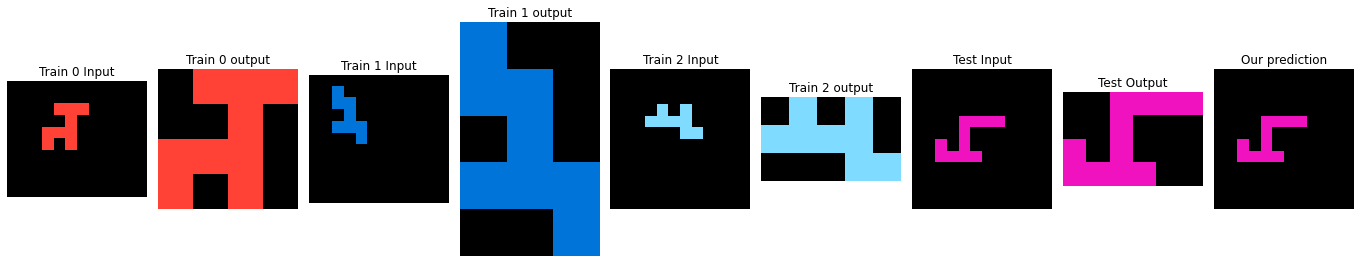

=====
35
contraction [[0], [0]] [[(10, 17)], [(9, 11)]]
is_out_obj_in_in_objs: [(True, 0)]
is_in_obj_in_out_objs: [(True, 0), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (Fa

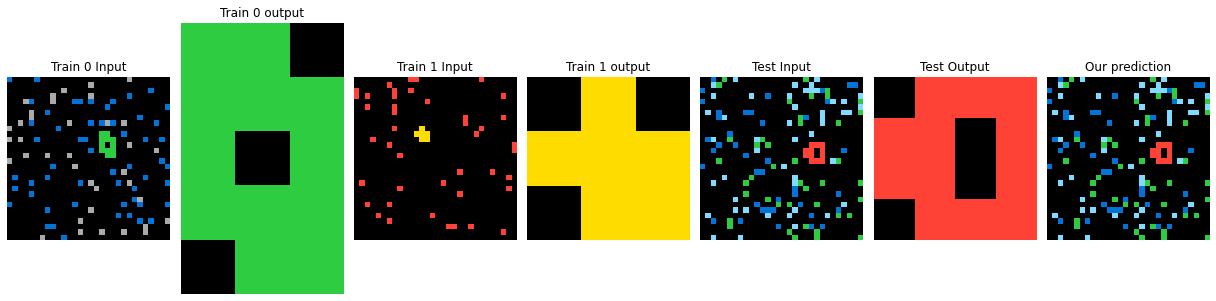

=====
37
contraction [[0, 4], [], []] [[(2, 1), (6, 2)], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


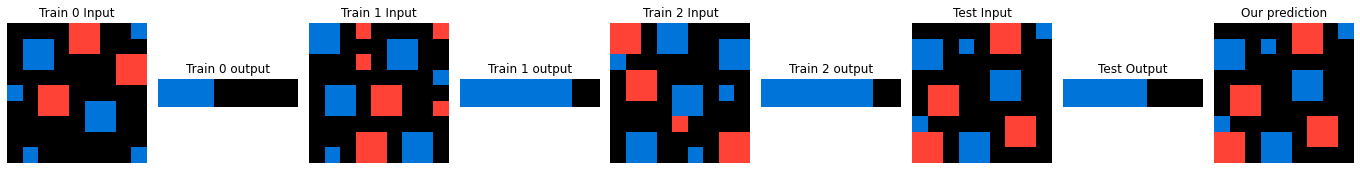

=====
38
contraction [[0, 5, 3, 2], [0, 5, 3, 4]] [[(2, 2), (2, 5), (5, 2), (5, 5)], [(1, 1), (1, 4), (4, 1), (4, 4)]]
is_out_obj_in_in_objs: [(False, -1), (True, 6), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1)]
is_out_obj_shape_in_in_objs: [(True, 6), (True, 6), (True, 6), (True, 6), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(False, ()), (True, (5, 2)), (False, ()), (False, ()), (False, ())]


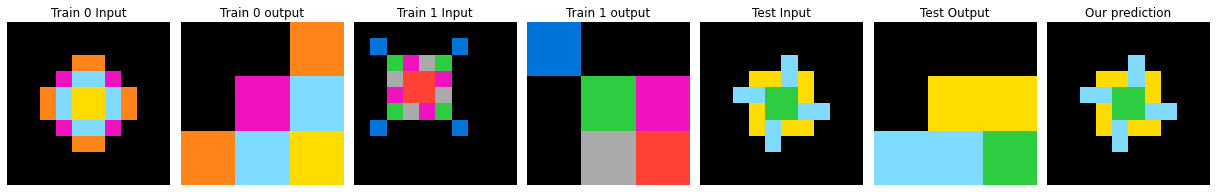

=====
45
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


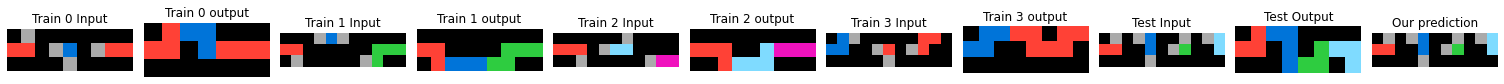

=====
47
non_dimension_related [[], [], [], [], [], []] [[], [], [], [], [], []]
is_out_obj_in_in_objs: []
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: []
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: []


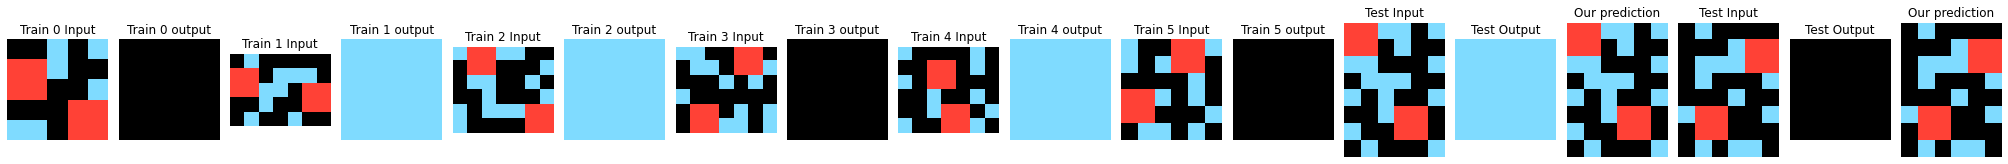

=====
48
contraction [[0], [0], [0], [0], [0]] [[(5, 3)], [(15, 14)], [(5, 5)], [(4, 3)], [(3, 11)]]
is_out_obj_in_in_objs: [(True, 0)]
is_in_obj_in_out_objs: [(True, 0), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (False, -1), (False, -1)]
overall_movement: [(True, (5, 3))]


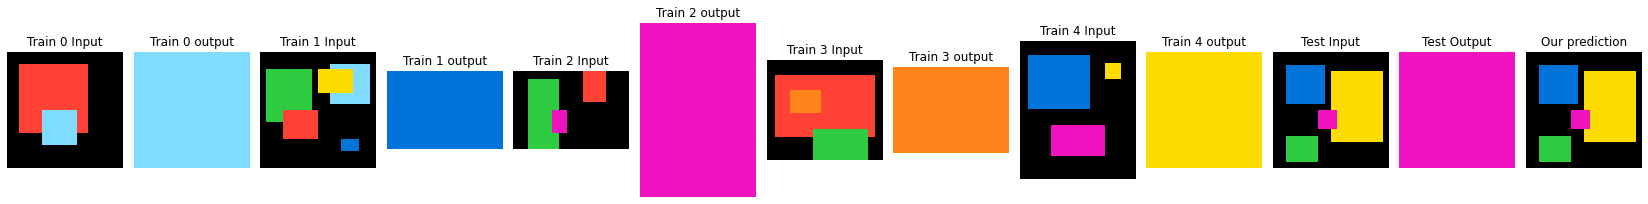

=====
55
non_dimension_related [[], [], [], [], [], [], []] [[], [], [], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ())]


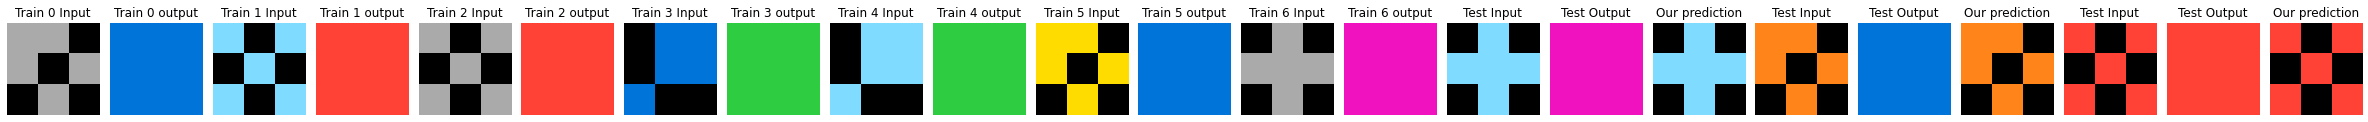

=====
56
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


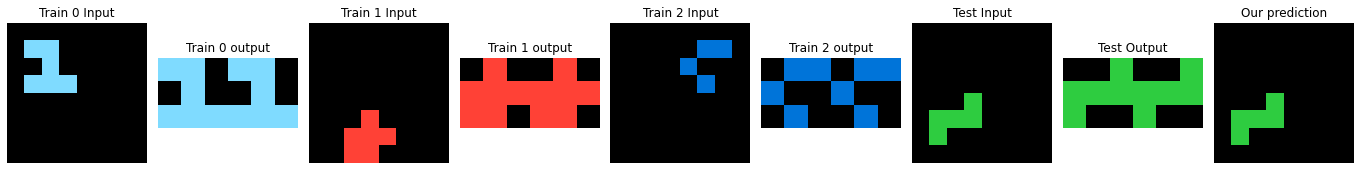

=====
64
contraction [[0], [0], [0]] [[(3, 0)], [(0, 4)], [(0, 0)]]
is_out_obj_in_in_objs: [(True, 3), (True, 4)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 0), (True, 1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 3), (True, 4)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 0), (True, 1), (False, -1)]
overall_movement: [(True, (3, 0)), (True, (3, 0))]


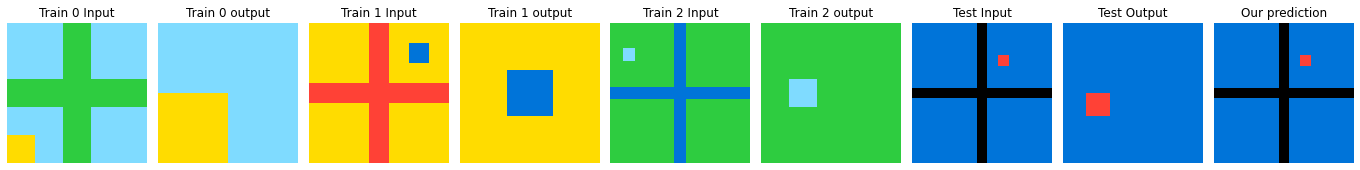

=====
66
contraction [[0, 3, 0], [0, 0, 0], [0, 7, 0, 7, 0]] [[(0, 0), (0, 3), (0, 6)], [(0, 0), (0, 4), (0, 8)], [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]]
is_out_obj_in_in_objs: [(False, -1), (True, 5), (True, 6), (True, 5), (True, 6)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 2), (True, 2), (True, 1)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 5), (True, 5), (True, 5), (True, 5)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (-2, -2)), (True, (2, -2))]


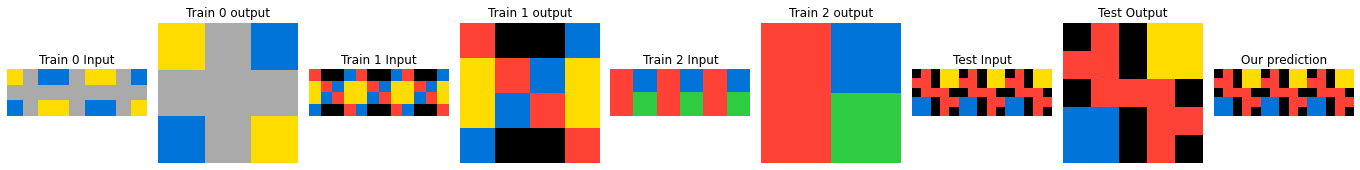

=====
71
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


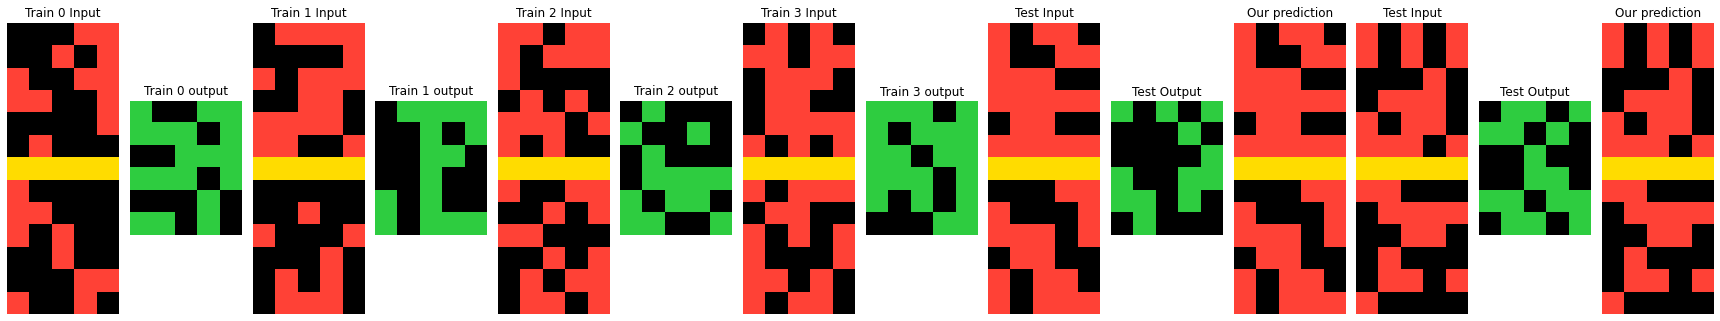

=====
78
contraction [[0, 0, 0], [0, 0, 0, 0], [0, 0]] [[(1, 2), (2, 10), (7, 3)], [(1, 2), (3, 11), (8, 9), (10, 2)], [(2, 2), (8, 8)]]
is_out_obj_in_in_objs: [(True, 0)]
is_in_obj_in_out_objs: [(True, 0), (True, 0), (False, -1), (True, 0), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (1, 2))]


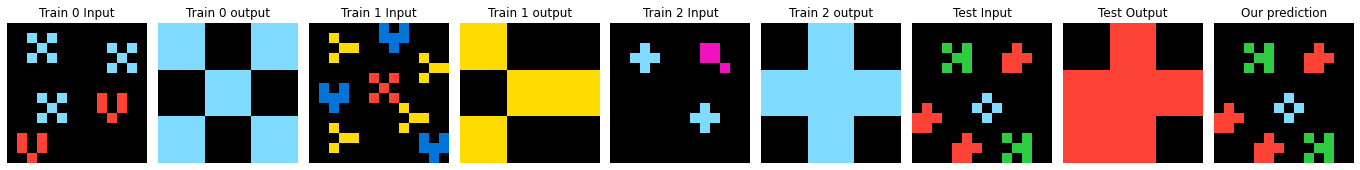

=====
82
expansion [[0, 4, 0, 4], [0, 7, 6, 4], [0, 7, 6, 4]] [[(0, 0), (0, 4), (3, 0), (3, 4)], [(0, 0), (0, 4), (3, 0), (3, 4)], [(0, 0), (0, 4), (3, 0), (3, 4)]]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


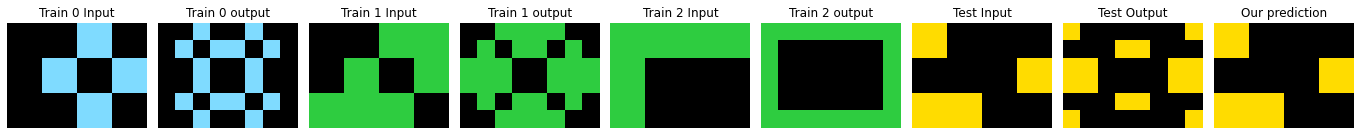

=====
87
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


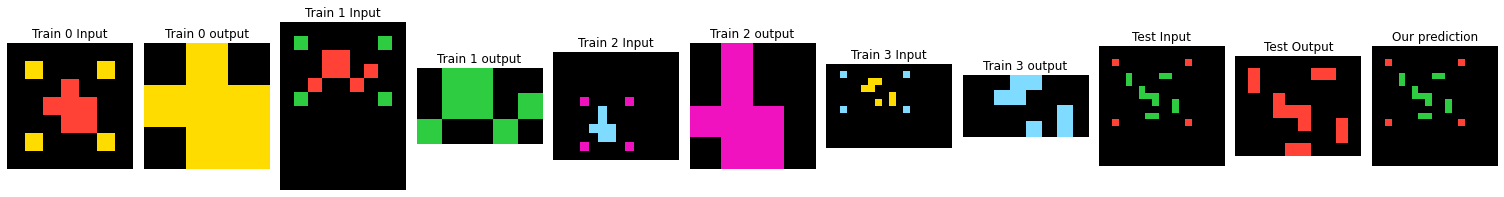

=====
90
contraction [[0], [0], [0]] [[(1, 1)], [(3, 2)], [(2, 3)]]
is_out_obj_in_in_objs: [(True, 0), (True, 0), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2)]
is_in_obj_in_out_objs: [(True, 0), (True, 0), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 0), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2)]
overall_movement: [(True, (1, 1)), (True, (1, 5)), (True, (1, 1)), (True, (5, -3)), (True, (3, -1)), (True, (1, -3)), (True, (5, 1))]


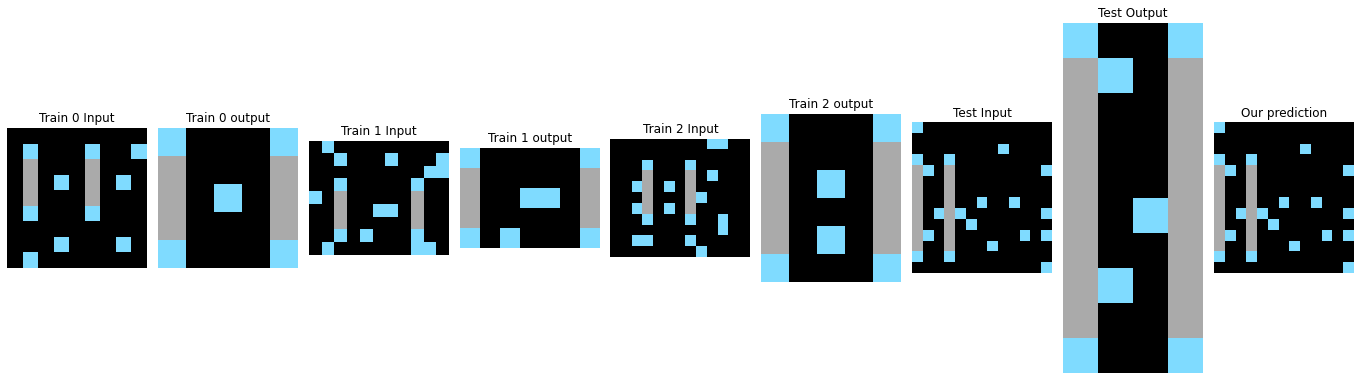

=====
95
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 3), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 10)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 4), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 13)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 4), (True, 4), (True, 4), (True, 4), (True, 4), (True, 4), (True, 4), (True, 4), (True, 10)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 4), (True, 4), (True, 4), (True, 5), (True, 5), (True, 5), (True, 5), (True, 5), (True, 5), (True, 13)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (True, (-1, 10)), (False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (True, (-1, 10))]


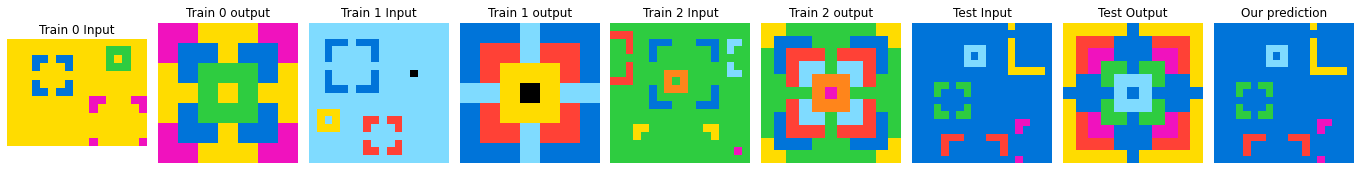

=====
99
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ())]


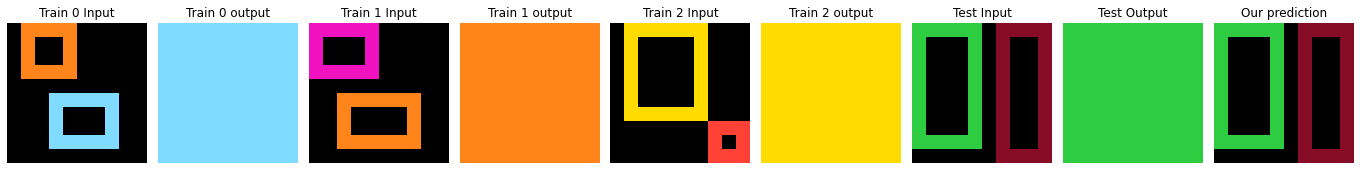

=====
102
non_dimension_related [[], [], [], [], [], []] [[], [], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ())]


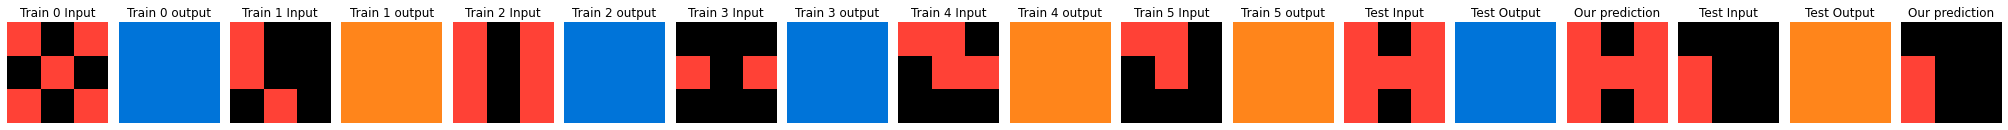

=====
103
non_dimension_related [[], []] [[], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ())]


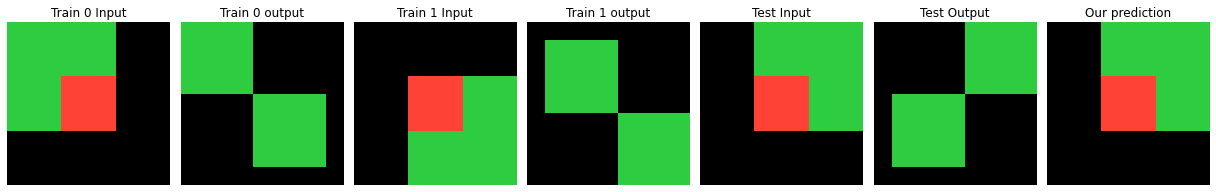

=====
105
expansion [[0, 3, 3, 0], [0, 5, 3, 2], [0, 5, 3, 4]] [[(0, 0), (0, 2), (2, 0), (2, 2)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


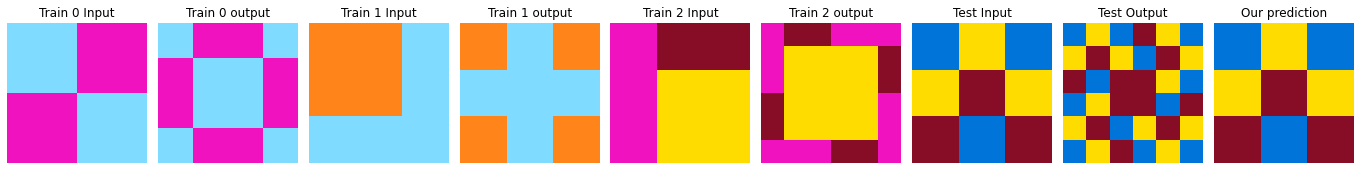

=====
106
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


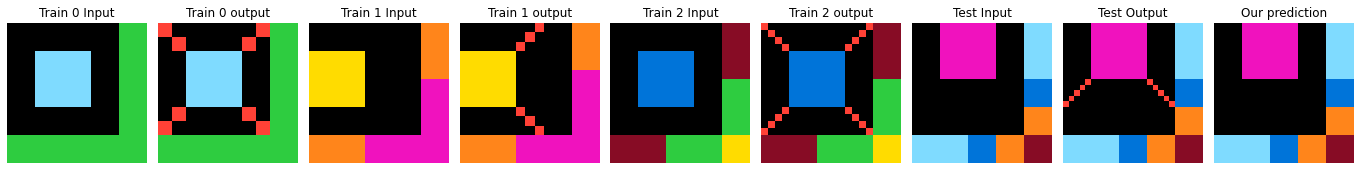

=====
107
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


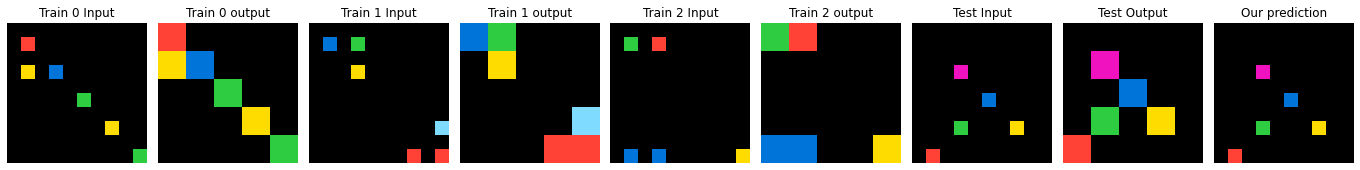

=====
108
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ())]


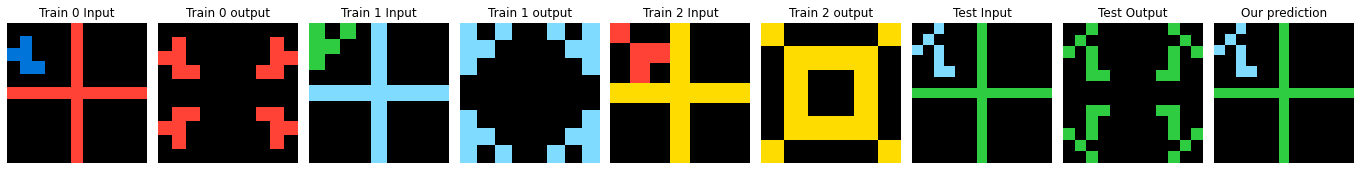

=====
110
contraction [[0], [0], [0]] [[(3, 2)], [(2, 6)], [(5, 6)]]
is_out_obj_in_in_objs: [(True, 1)]
is_in_obj_in_out_objs: [(False, -1), (True, 0), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 1)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (False, -1), (False, -1)]
overall_movement: [(True, (3, 2))]


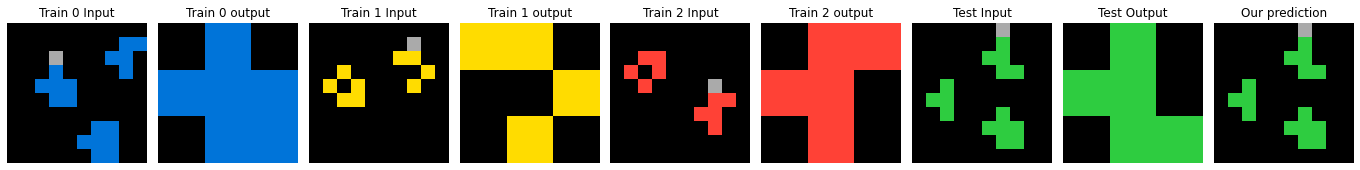

=====
113
expansion [[0], [0], [0]] [[(1, 1)], [(1, 1)], [(1, 1)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


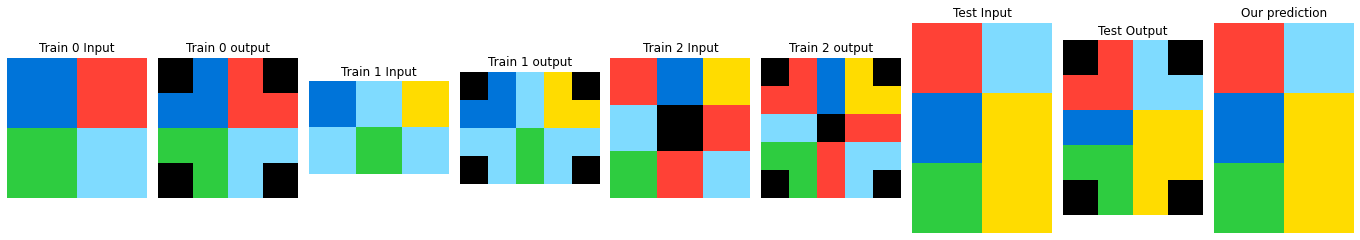

=====
114
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


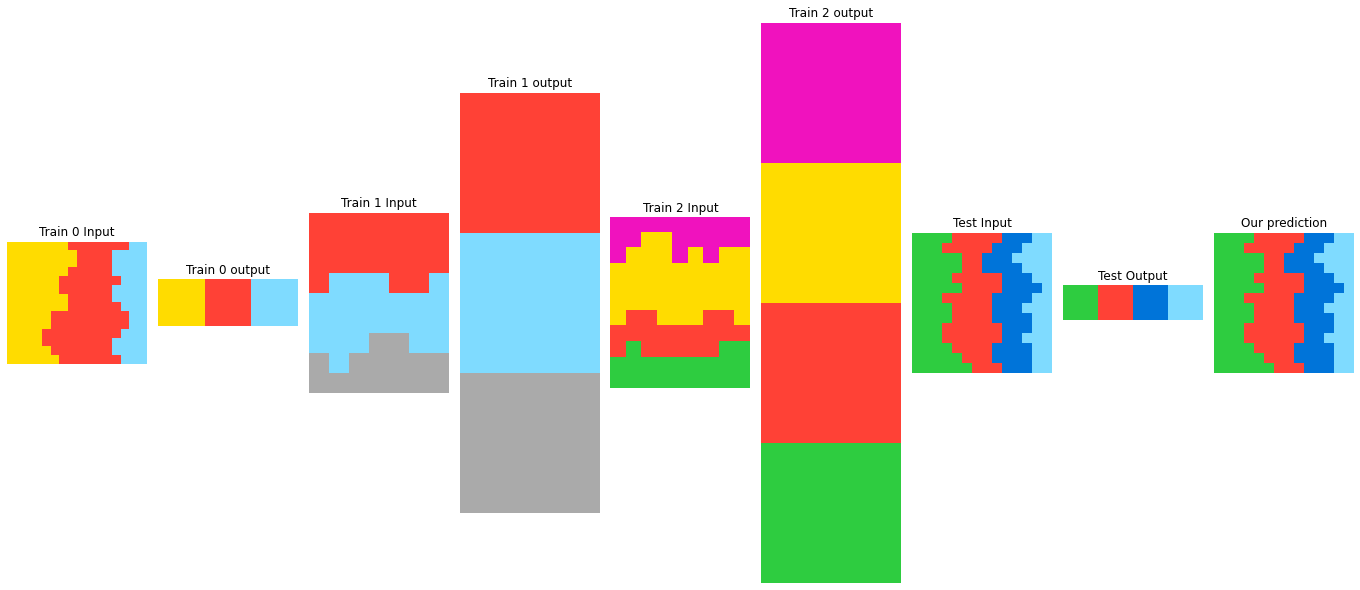

=====
115
expansion [[6, 0], [6, 0], [6, 0], [6, 0]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 2), (True, 2)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (True, 2)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (True, 2), (True, 2)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (True, 2)]
overall_movement: [(False, ()), (False, ()), (True, (-3, 0)), (True, (2, 0))]


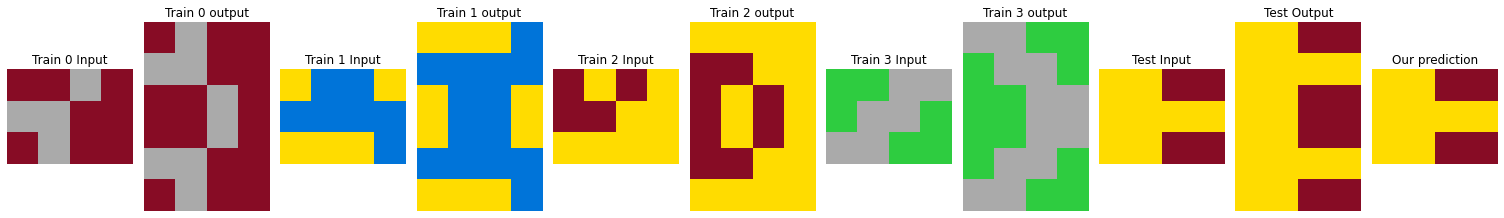

=====
120
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 2)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (True, 0), (False, -1), (False, -1)]
overall_movement: [(False, ())]


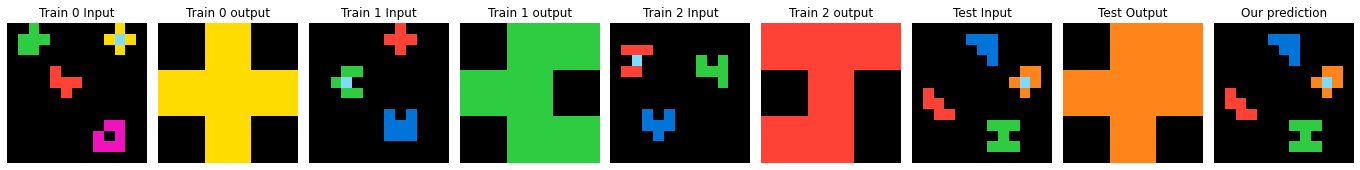

=====
122
non_dimension_related [[], [], [0, 0]] [[], [], [(0, 0), (5, 5)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 0), (True, 1), (False, -1)]
is_in_obj_in_out_objs: [(True, 2), (True, 3), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (True, 0), (True, 1), (False, -1)]
is_in_obj_shape_in_out_objs: [(True, 2), (True, 3), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


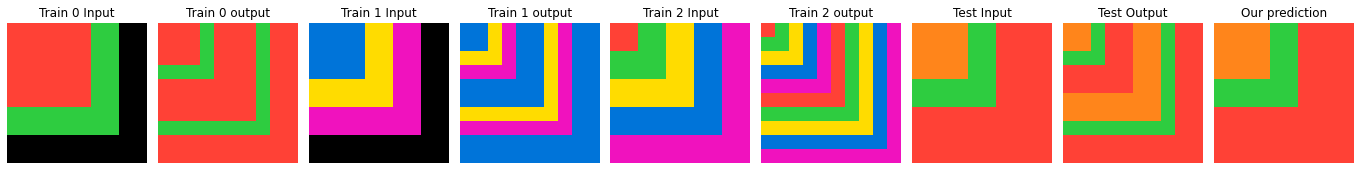

=====
123
expansion [[0], [0, 0, 0, 0, 0, 0], [0]] [[(0, 0)], [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0)], [(0, 0)]]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


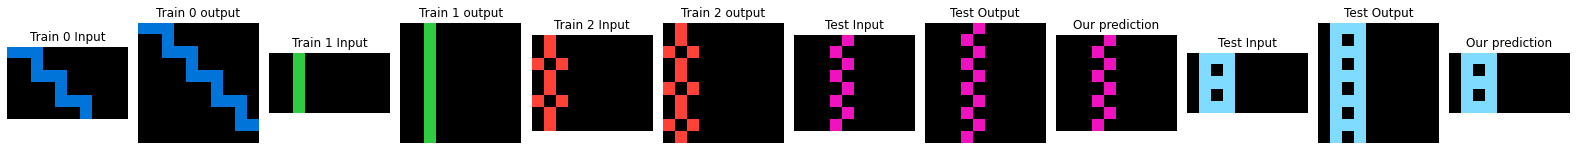

=====
129
non_dimension_related [[], []] [[], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


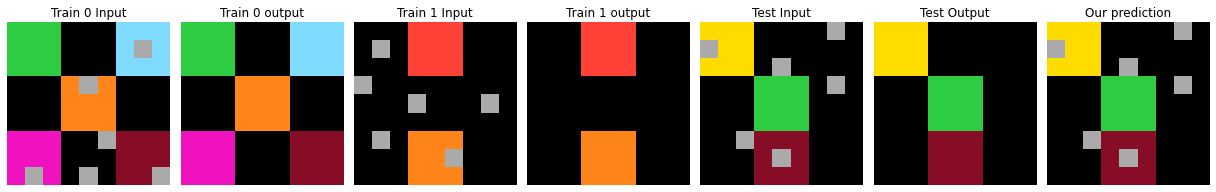

=====
133
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


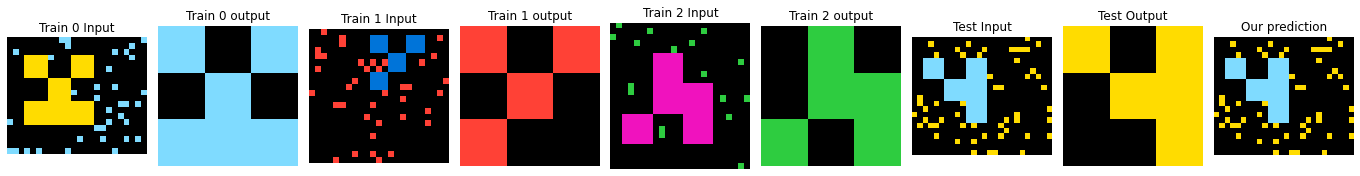

=====
134
contraction [[0], [0], [0], [0]] [[(0, 6)], [(0, 6)], [(0, 6)], [(0, 6)]]
is_out_obj_in_in_objs: [(True, 1), (True, 3), (True, 15), (True, 12), (True, 9)]
is_in_obj_in_out_objs: [(False, -1), (True, 0), (False, -1), (True, 1), (False, -1), (False, -1), (True, 1), (False, -1), (False, -1), (True, 4), (True, 1), (True, 1), (True, 3), (True, 3), (True, 4), (True, 2), (True, 4), (False, -1), (True, 4), (True, 1), (False, -1), (True, 2), (True, 3), (False, -1), (True, 3), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 1), (True, 3), (True, 3), (True, 3), (True, 3)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (False, -1), (False, -1)]
overall_movement: [(True, (0, 6)), (True, (4, 5)), (True, (3, 3)), (True

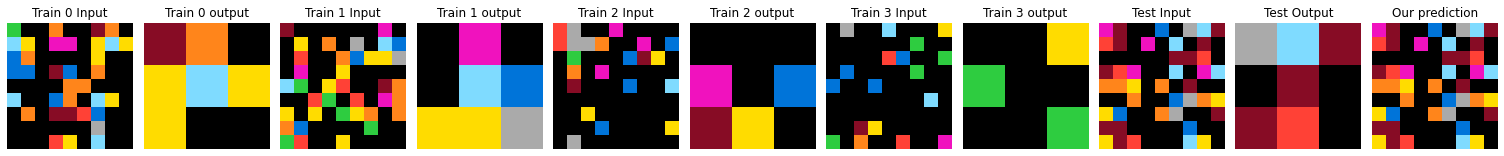

=====
137
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 3)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 3), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 3)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 3), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (1, 5))]


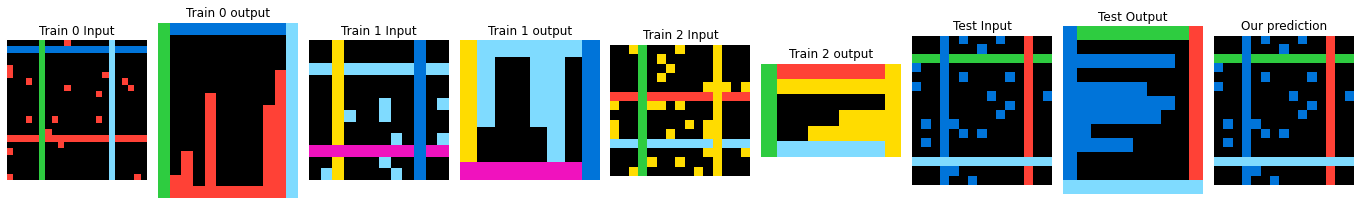

=====
141
expansion [[0, 7, 6, 4], [0, 7, 6, 4], [0, 7, 6, 4]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


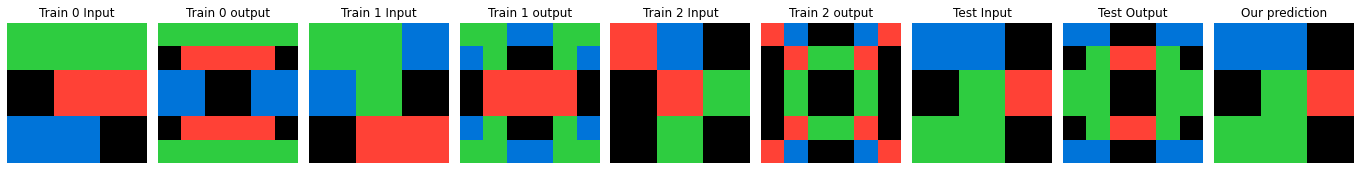

=====
143
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


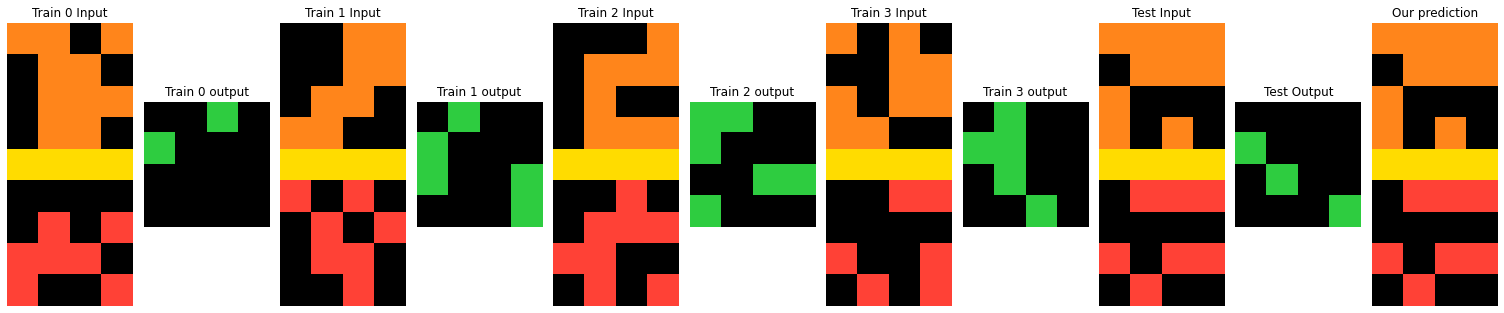

=====
145
contraction [[0], [0], [0], [0]] [[(6, 0)], [(3, 0)], [(6, 0)], [(0, 0)]]
is_out_obj_in_in_objs: [(True, 3), (True, 5)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 0), (False, -1), (True, 1)]
is_out_obj_shape_in_in_objs: [(True, 3), (True, 5)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 0), (False, -1), (True, 1)]
overall_movement: [(True, (6, 0)), (True, (6, 0))]


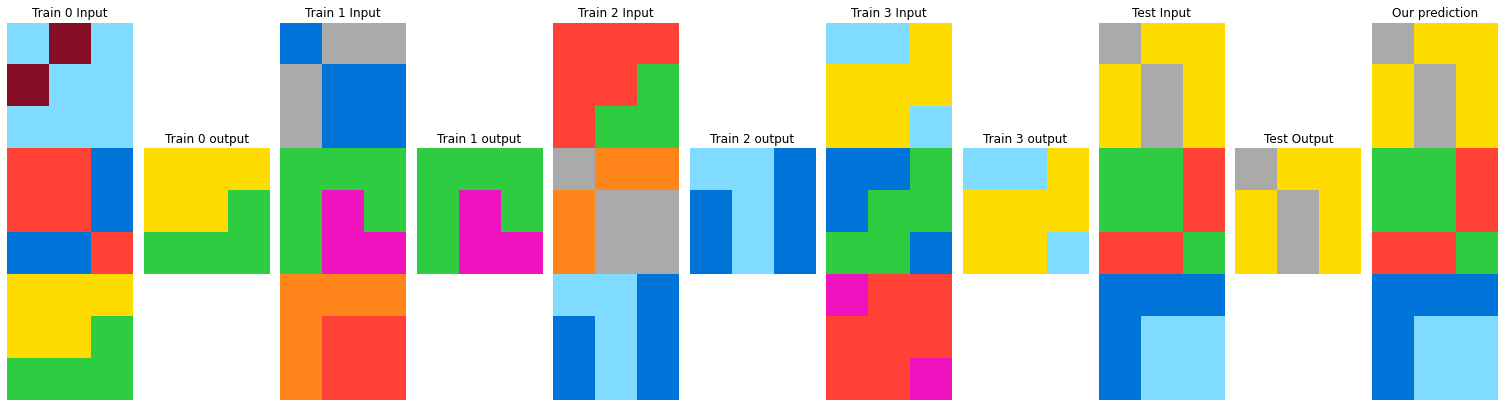

=====
148
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 2)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
overall_movement: [(False, ()), (False, ())]


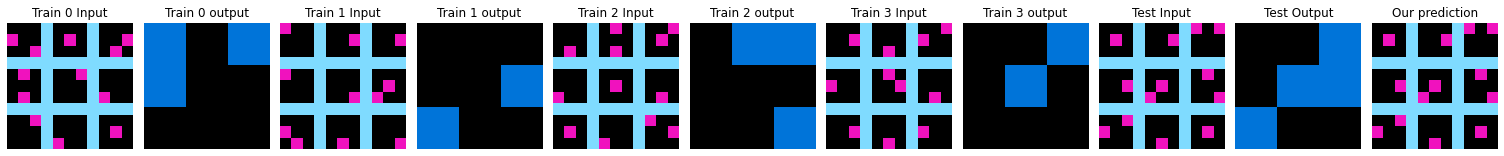

=====
151
expansion [[0, 7, 6, 4], [0, 7, 6, 4], [0, 7, 6, 4], [0, 7, 6, 4]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_in_out_objs: [(True, 5), (True, 5), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 5), (True, 5), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (True, (-5, -5)), (False, ()), (True, (0, -5)), (True, (-5, 0))]


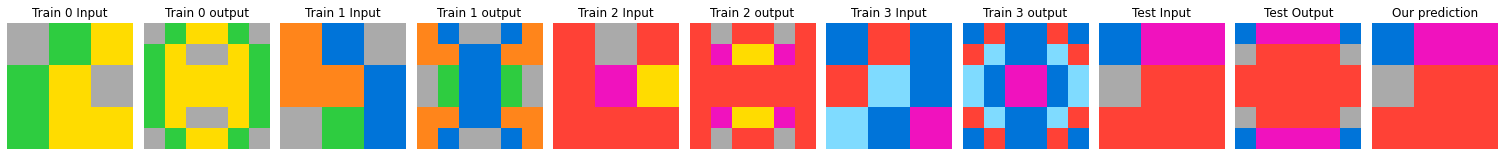

=====
152
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


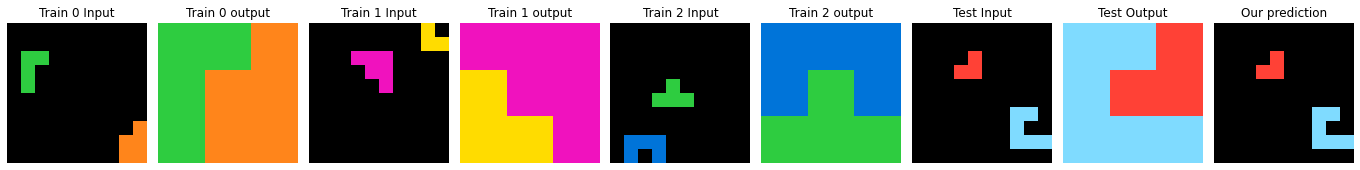

=====
158
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


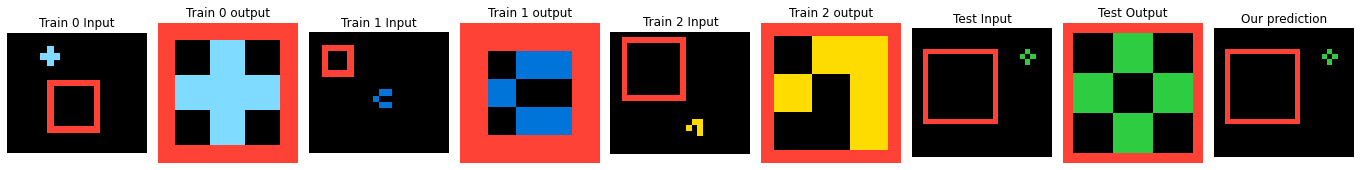

=====
163
expansion [[0, 7], [0, 7], [0, 7], [0, 7]] [[(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 3)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 0), (True, 0), (True, 2), (True, 2)]
is_in_obj_in_out_objs: [(True, 2), (False, -1), (True, 4), (True, 4)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 0), (True, 0), (True, 0), (True, 2), (True, 2)]
is_in_obj_shape_in_out_objs: [(True, 1), (False, -1), (True, 4), (True, 4)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (0, -4)), (True, (0, -3)), (True, (0, 2))]


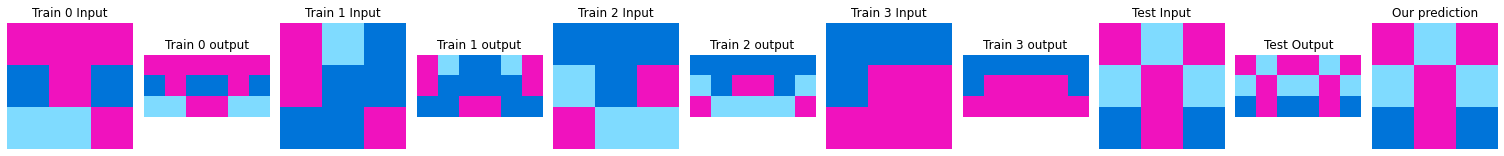

=====
169
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(True, 3), (True, 4), (True, 8), (True, 4), (True, 6)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 0), (True, 1), (True, 1), (True, 4), (False, -1), (True, 2), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (19, 7)), (True, (19, 7)), (True, (19, 7)), (True, (21, 7)), (True, (19, 7))]


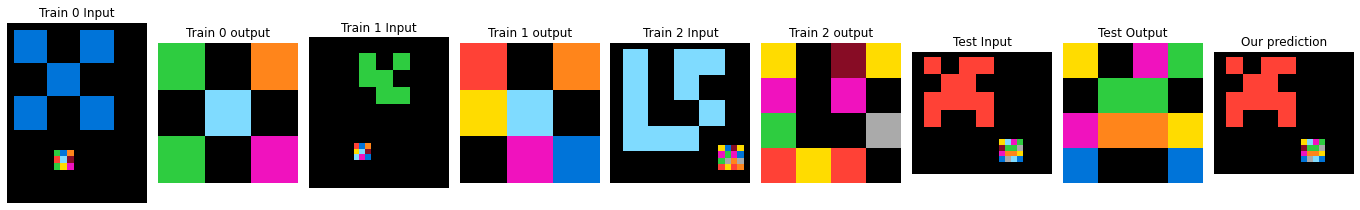

=====
171
expansion [[0, 6], [0, 4], [0, 6], [0, 6]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]
is_out_obj_in_in_objs: [(False, -1), (True, 0), (False, -1), (True, 0), (True, 1), (True, 1)]
is_in_obj_in_out_objs: [(True, 1), (True, 4), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 1), (True, 1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (-4, 0)), (False, ()), (True, (-4, 0))]


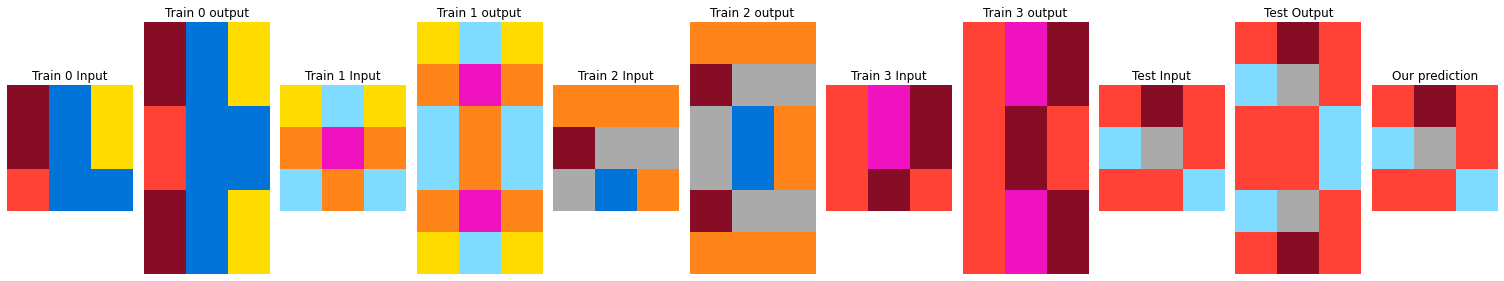

=====
173
contraction [[0], [0], [0]] [[(6, 3)], [(1, 2)], [(2, 5)]]
is_out_obj_in_in_objs: [(True, 0)]
is_in_obj_in_out_objs: [(True, 0), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (False, -1), (False, -1)]
overall_movement: [(True, (6, 3))]


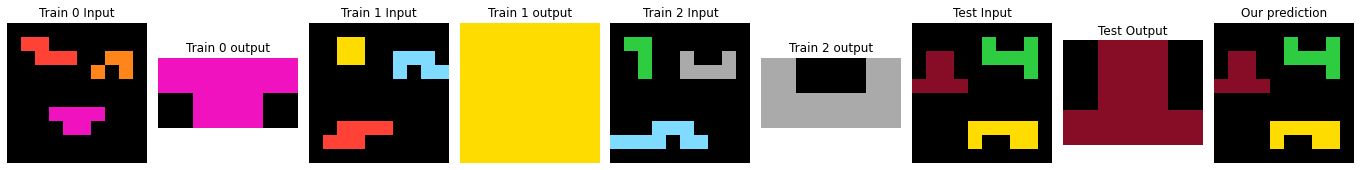

=====
176
contraction [[7], [7], [7]] [[(5, 2)], [(1, 3)], [(7, 2)]]
is_out_obj_in_in_objs: [(True, 0), (True, 1), (True, 2)]
is_in_obj_in_out_objs: [(True, 0), (True, 1), (True, 2)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 1), (True, 2)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 1), (True, 2)]
overall_movement: [(True, (5, 2)), (True, (5, -1)), (True, (5, 7))]


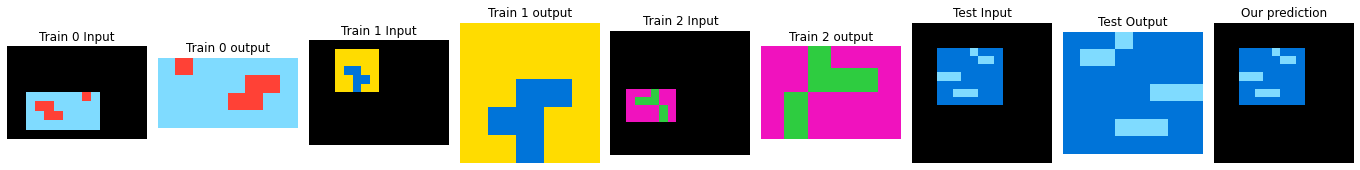

=====
177
contraction [[0, 0, 0], [0, 0, 0], [], [0, 0], []] [[(0, 0), (0, 1), (0, 2)], [(0, 0), (1, 0), (2, 0)], [], [(0, 0), (0, 1)], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


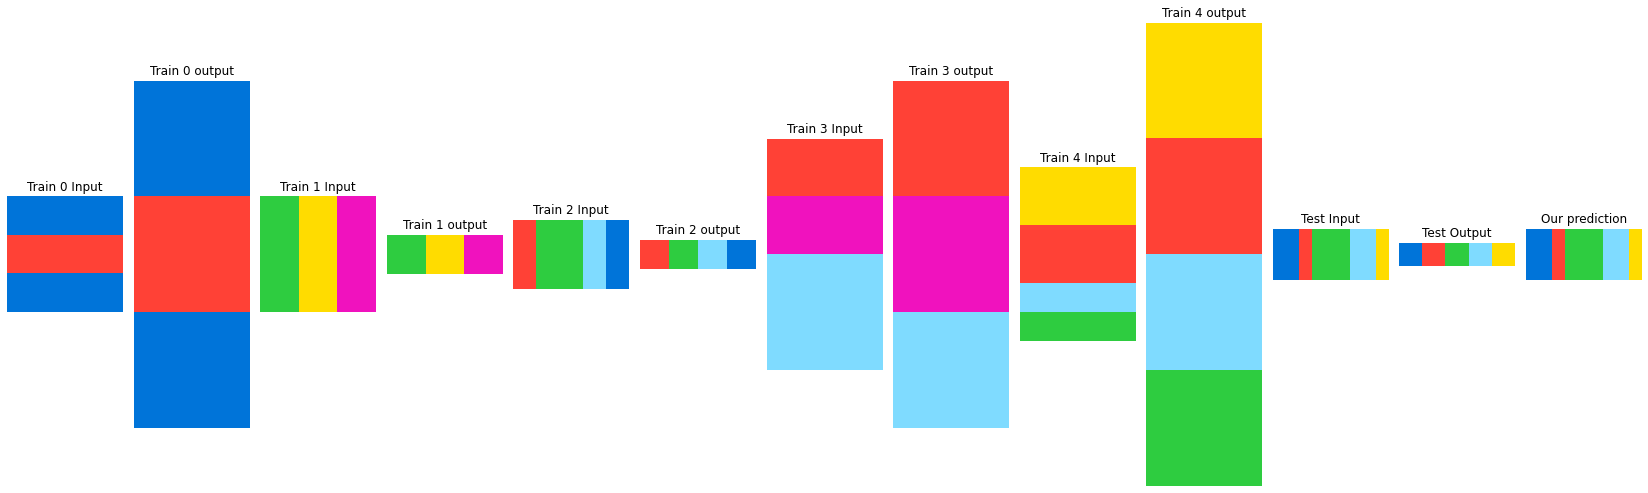

=====
179
non_dimension_related [[], [], [], [], []] [[], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 5), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 3)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (True, 5), (True, 5), (True, 5), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 2)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (0, 4)), (False, ()), (False, ())]


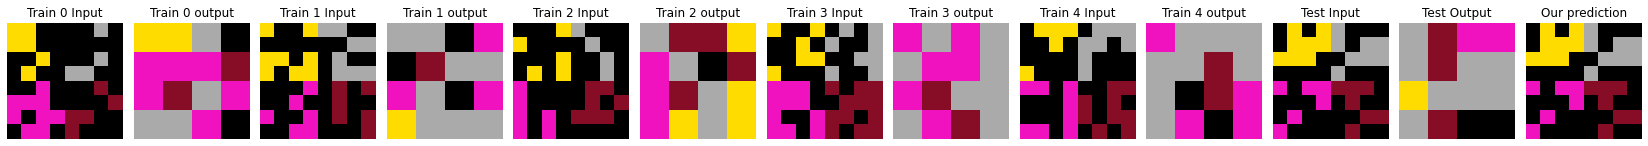

=====
182
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(True, 11), (True, 9), (True, 6), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 2), (False, -1), (False, -1), (True, 1), (False, -1), (True, 0)]
is_out_obj_shape_in_in_objs: [(True, 6), (True, 6), (True, 6), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (2, 2)), (True, (4, 0)), (True, (-1, 4)), (False, ()), (False, ()), (False, ())]


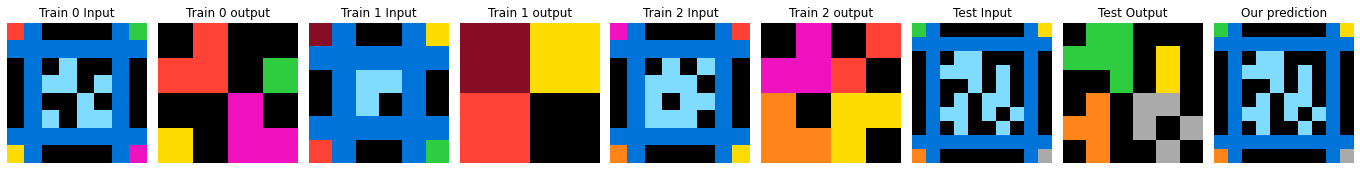

=====
183
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(True, 4), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 0)]
is_out_obj_shape_in_in_objs: [(True, 4), (True, 4), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 0)]
overall_movement: [(True, (7, 18)), (False, ()), (False, ())]


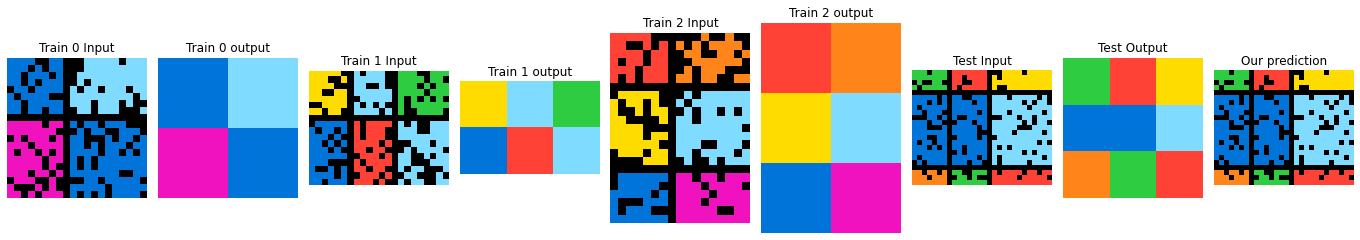

=====
184
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (True, 4)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 1)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
overall_movement: [(False, ()), (True, (5, 9))]


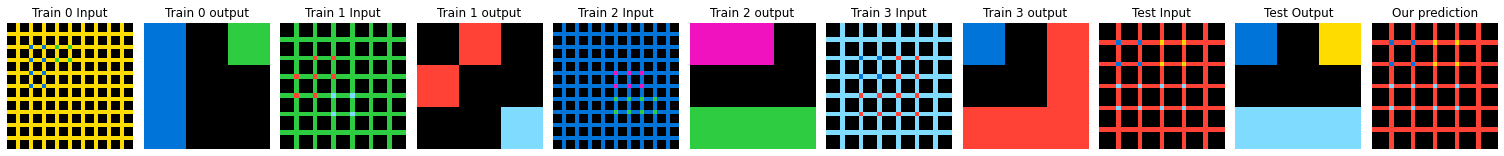

=====
187
contraction [[0, 0], [0, 0], [0, 4, 0]] [[(0, 0), (0, 4)], [(0, 0), (0, 3)], [(0, 0), (2, 0), (3, 0)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 2), (True, 2)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (True, 2), (True, 2), (True, 2), (True, 2)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (True, 2), (True, 2)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (True, 2), (True, 2), (True, 2), (True, 2)]
overall_movement: [(False, ()), (False, ()), (True, (0, 4)), (True, (-3, 7))]


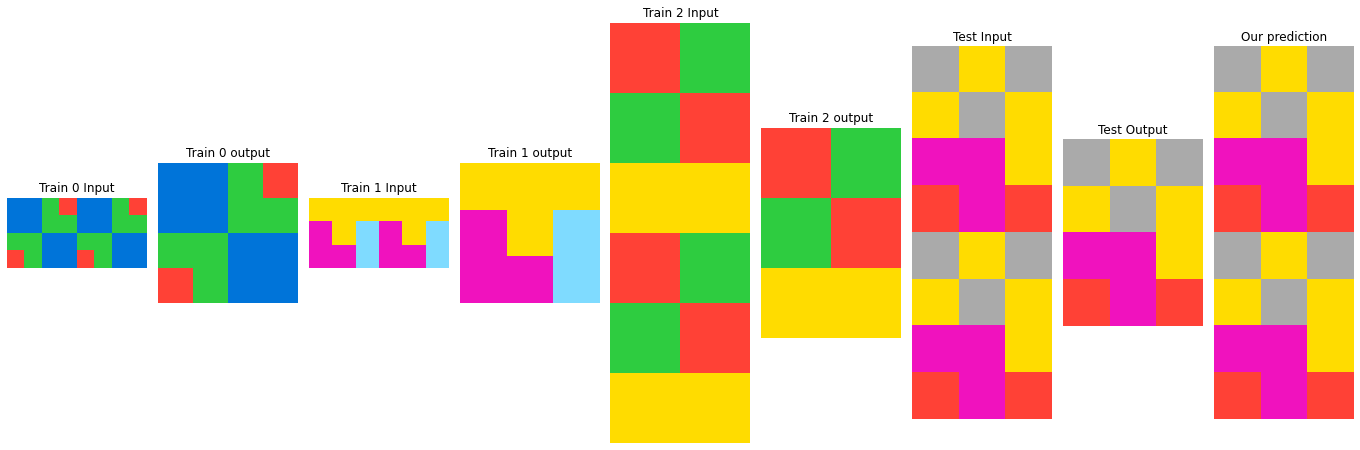

=====
188
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ())]


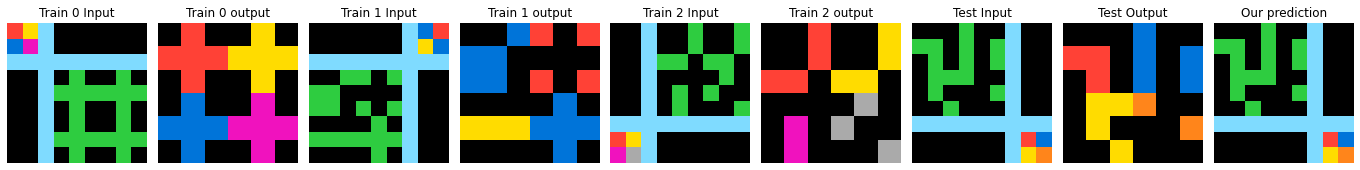

=====
193
expansion [[0, 5, 3, 4], [0, 5, 3, 4], [0, 1, 1, 0]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 1), (False, -1), (False, -1), (True, 0), (True, 1), (True, 0), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(True, 5), (True, 2), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (True, 0), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(True, 2), (True, 2), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (True, (-4, -3)), (False, ()), (False, ()), (False, ()), (False, ()), (True, (-4, -5)), (False, ()), (False, ())]


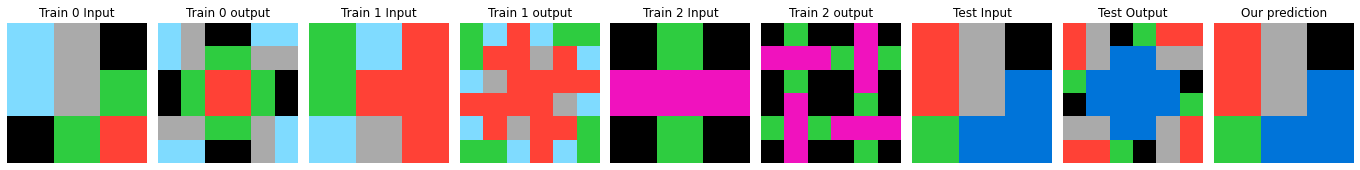

=====
194
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


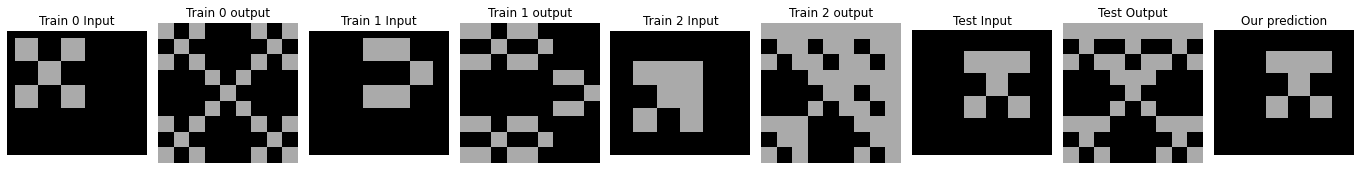

=====
200
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 4), (True, 4), (True, 4), (True, 4)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 2), (True, 2), (True, 2), (True, 2)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (True, 4), (True, 4), (True, 4), (True, 4)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 2), (True, 2), (True, 2), (True, 2)]
overall_movement: [(False, ()), (False, ()), (True, (12, 5)), (True, (12, -2)), (True, (7, 5)), (True, (7, -2))]


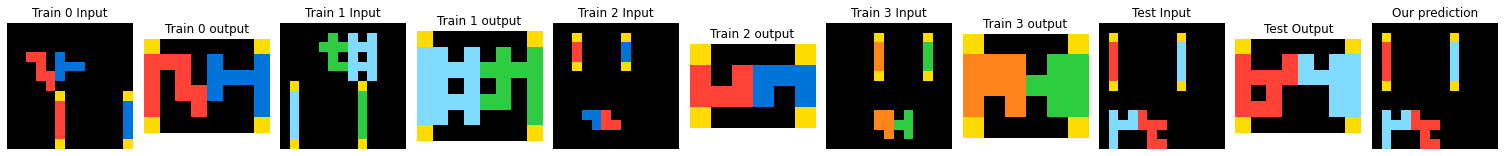

=====
204
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 16), (True, 16), (True, 16), (True, 16), (True, 19), (True, 35), (True, 35)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 3), (False, -1), (False, -1), (True, 7), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 7), (False, -1), (True, 7), (False, -1), (False, -1), (False, -1), (True, 8), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 8), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 8), (False, -1), (False, -1), (True, 8), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 

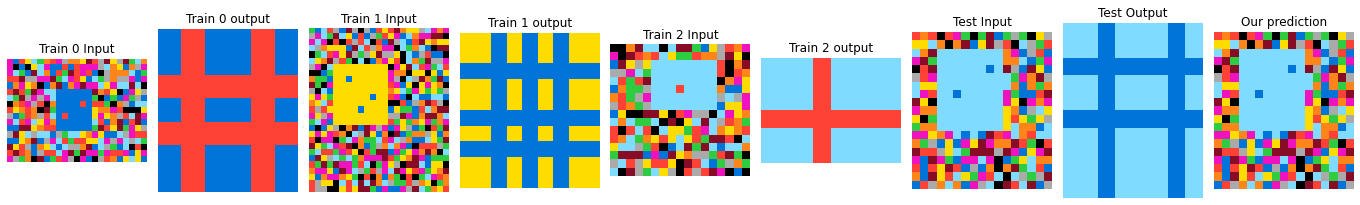

=====
206
contraction [[2, 2, 2, 0], [0], [0]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(3, 0)], [(0, 3)]]
is_out_obj_in_in_objs: [(True, 0)]
is_in_obj_in_out_objs: [(True, 0), (True, 0), (True, 0), (True, 0)]
is_out_obj_shape_in_in_objs: [(True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (0, 3))]


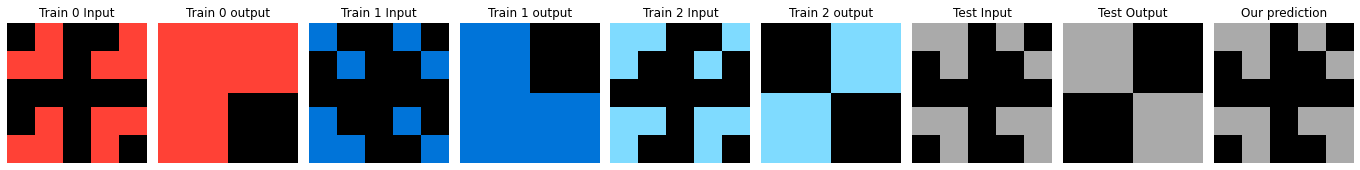

=====
208
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (True, 2), (True, 1), (True, 5), (True, 5), (True, 5), (True, 5)]
is_in_obj_in_out_objs: [(False, -1), (True, 2), (True, 1), (False, -1), (False, -1), (True, 3), (True, 3), (True, 3), (False, -1), (True, 3)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 1), (True, 1), (True, 4), (True, 4), (True, 4), (True, 4)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 1), (True, 1), (True, 1), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3)]
overall_movement: [(False, ()), (True, (0, 2)), (True, (0, 2)), (True, (0, 2)), (True, (0, -11)), (True, (-8, 2)), (True, (-8, -11))]


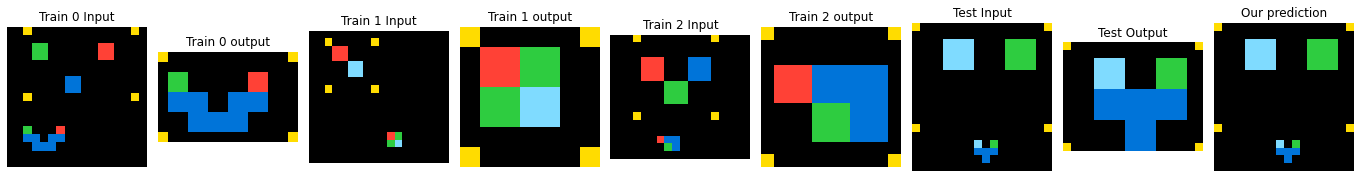

=====
209
expansion [[0, 6], [0, 6], [0, 6]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]
is_out_obj_in_in_objs: [(True, 0), (True, 0)]
is_in_obj_in_out_objs: [(True, 0)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0)]
overall_movement: [(False, ()), (True, (-4, 0))]


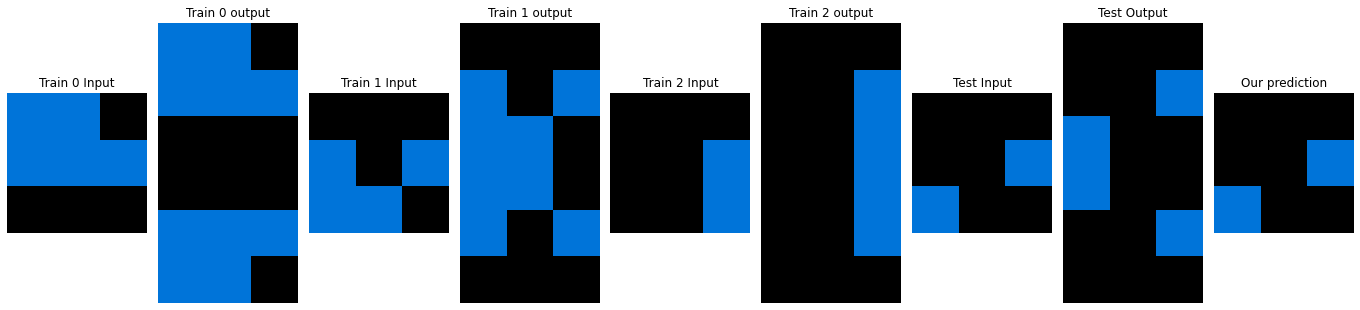

=====
210
expansion [[4, 0, 4, 0, 4, 0], [4, 0, 4, 0, 4, 0], [4, 6, 7, 0, 4, 6]] [[(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)], [(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)], [(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_in_out_objs: [(True, 4), (True, 4)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 4), (True, 4)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (True, (-6, -2)), (True, (-6, 1)), (True, (2, -2)), (True, (2, 1))]


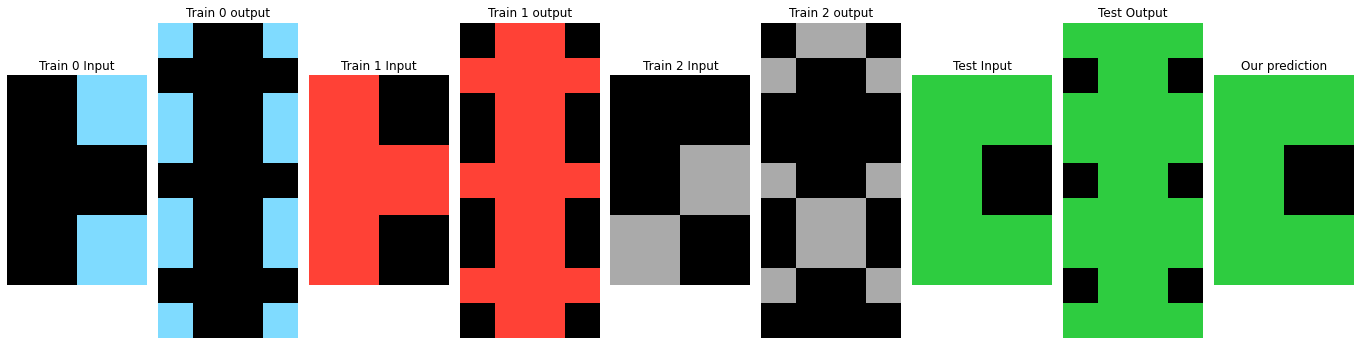

=====
212
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


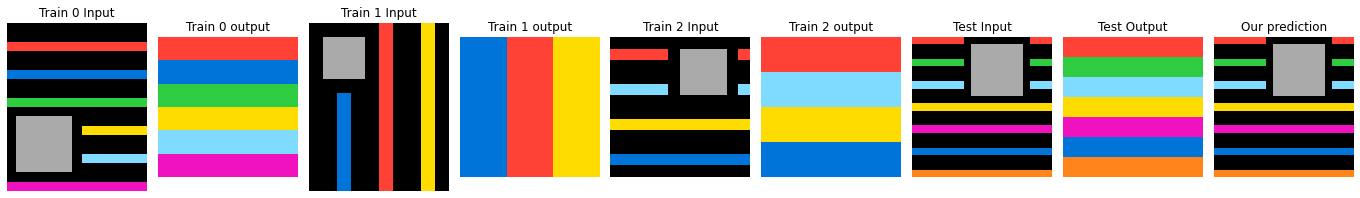

=====
215
contraction [[0], [0], [0]] [[(13, 6)], [(2, 2)], [(15, 2)]]
is_out_obj_in_in_objs: [(True, 1), (True, 2), (True, 6)]
is_in_obj_in_out_objs: [(False, -1), (True, 0), (True, 1), (False, -1), (False, -1), (False, -1), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2)]
is_out_obj_shape_in_in_objs: [(True, 1), (True, 2), (True, 6)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (True, 1), (False, -1), (False, -1), (False, -1), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2)]
overall_movement: [(True, (13, 6)), (True, (13, 6)), (True, (13, 6))]


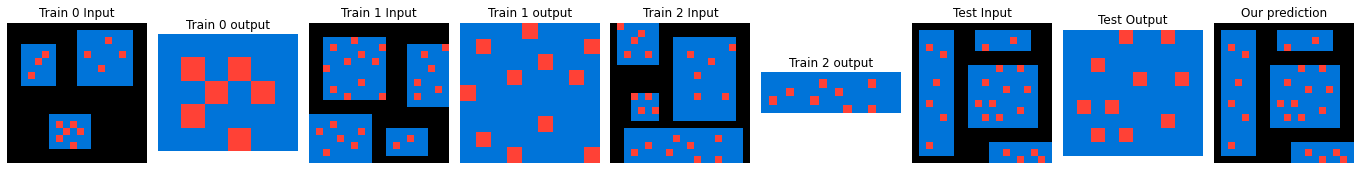

=====
217
non_dimension_related [[], [0], []] [[], [(8, 7)], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


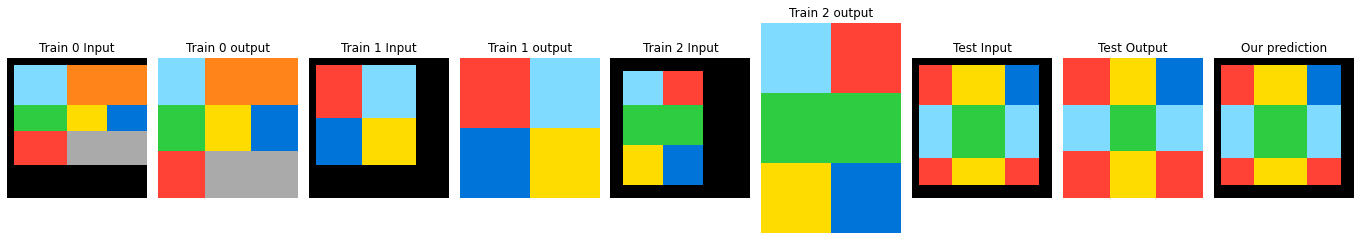

=====
220
expansion [[0, 0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 6, 6, 6, 0, 0, 0], [0, 0, 0]] [[(0, 0), (0, 3), (0, 6), (0, 9), (3, 0)], [(0, 0), (0, 3), (0, 6), (0, 9)], [(0, 0), (0, 3), (0, 6), (2, 0), (2, 3), (2, 6), (3, 0), (3, 3), (3, 6)], [(0, 0), (0, 3), (0, 6)]]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


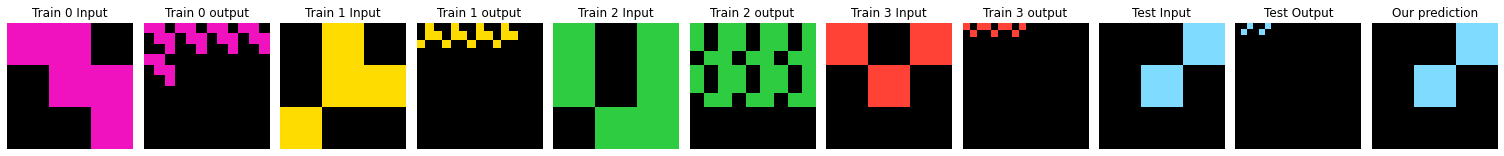

=====
222
non_dimension_related [[], []] [[], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


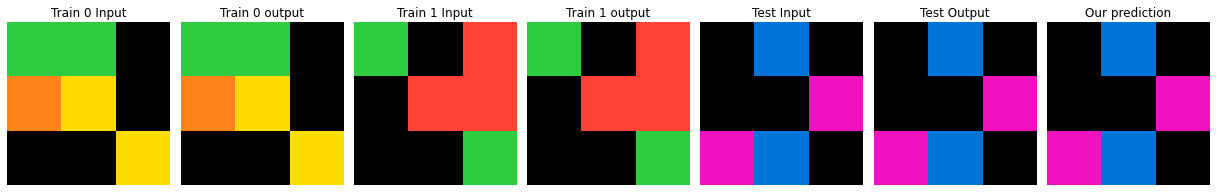

=====
226
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 2)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (True, 1), (True, 1)]
overall_movement: [(False, ()), (False, ())]


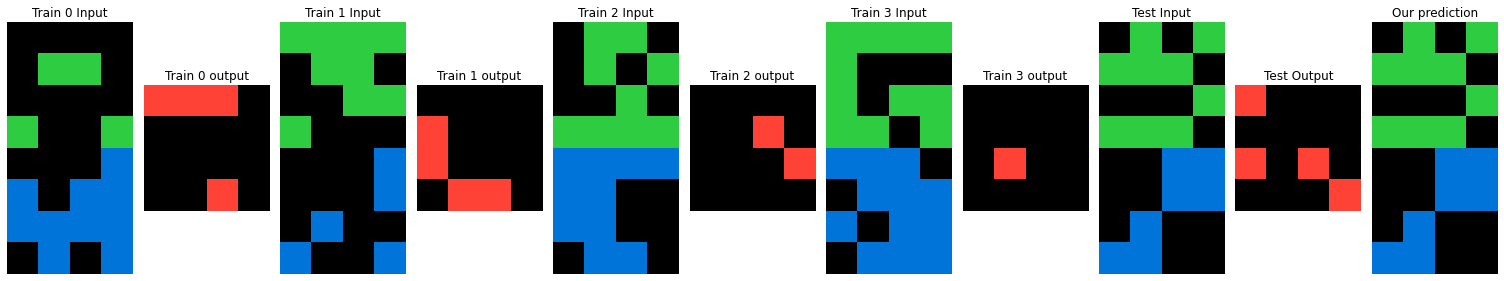

=====
230
expansion [[0, 7, 0, 7, 0, 7, 0], [0, 0, 0], [0, 0, 0]] [[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6)], [(0, 0), (0, 3), (0, 6)], [(0, 0), (0, 3), (0, 6)]]
is_out_obj_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 0), (True, 0), (True, 2)]
is_in_obj_in_out_objs: [(True, 0), (True, 0), (True, 4), (True, 4), (True, 0), (True, 4)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (0, -4)), (False, ()), (True, (0, 4)), (True, (0, -6)), (False, ()), (True, (0, -2)), (True, (0, 4)), (True, (0, -4)), (True, (0, -6)), (True, (0, 2)), (True, (0, -2)), (True, (0, 2))]


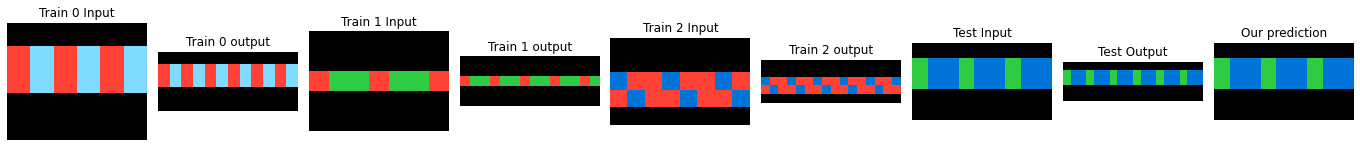

=====
232
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 6), (False, -1), (False, -1), (False, -1), (True, 10), (True, 10), (True, 10), (True, 10)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 3), (False, -1), (False, -1), (False, -1), (True, 7), (True, 7), (True, 7), (True, 7), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 6), (False, -1), (False, -1), (False, -1), (True, 10), (True, 10), (True, 10), (True, 10)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 3), (False, -1), (False, -1), (False, -1), (True, 7), (True, 7), (True, 7), (True, 7), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (19, 2)), (False, ()), (False, ()), (False, ()), (True, (-6, 8)), (True, (-4, 8)), (True, (-4, 10))

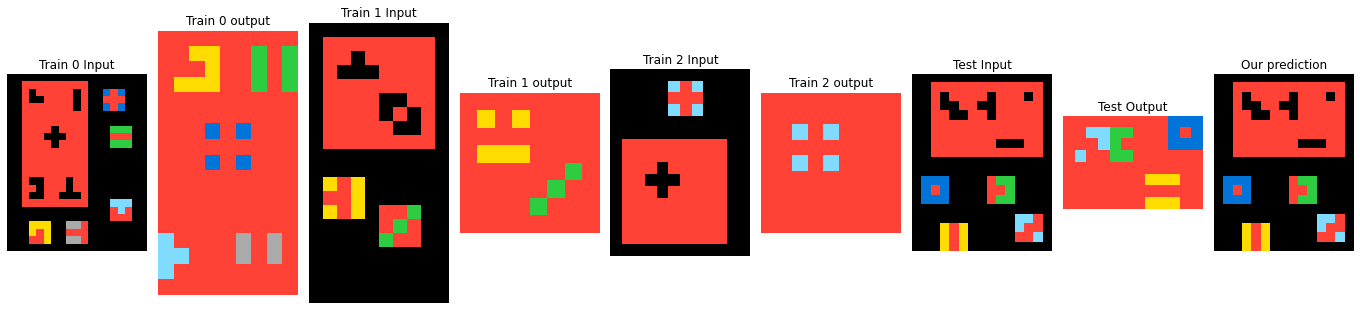

=====
234
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


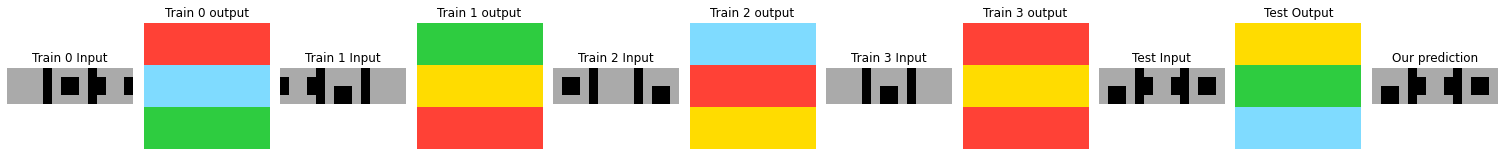

=====
235
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


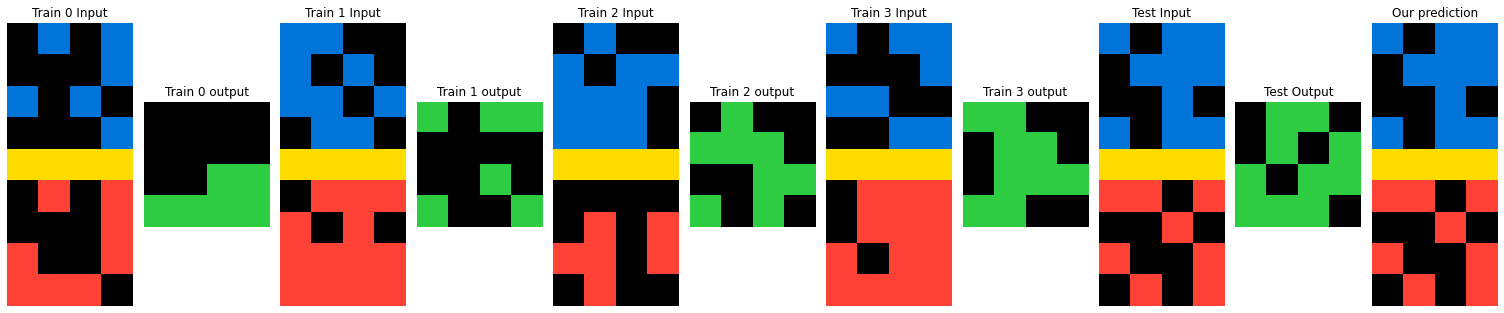

=====
237
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(True, 1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (True, 0), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (False, -1), (False, -1), (True, 0)]
overall_movement: [(True, (7, 6)), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]


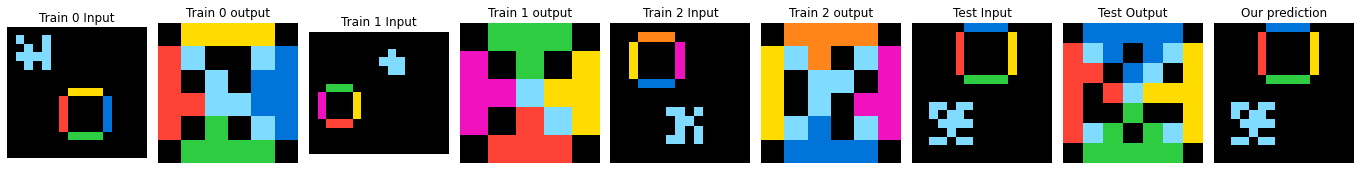

=====
238
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 0)]
is_in_obj_in_out_objs: [(True, 3), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 3), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (1, -1))]


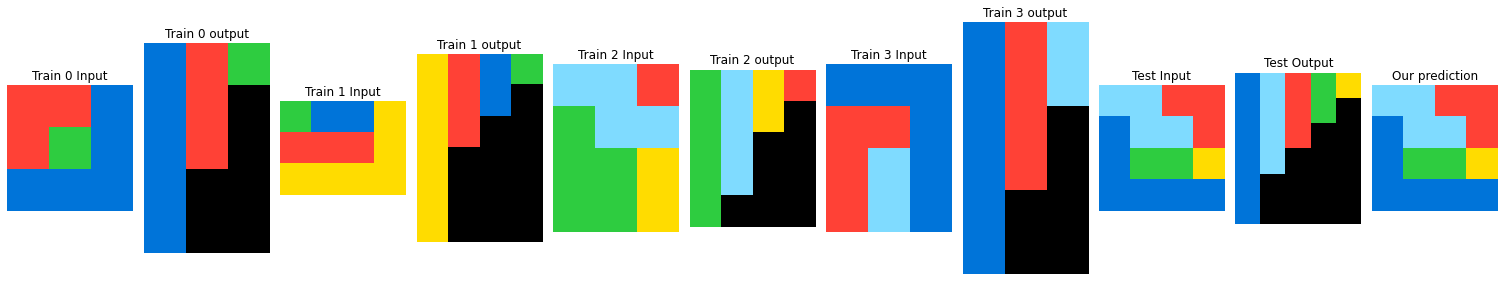

=====
241
contraction [[5, 7, 6, 4, 3, 2], [5, 1, 6, 4, 7, 3], [2, 3, 4, 7, 5, 1]] [[(4, 8), (5, 9), (8, 4), (8, 9), (9, 5), (9, 8)], [(4, 5), (4, 8), (5, 4), (5, 9), (8, 9), (9, 8)], [(3, 6), (3, 7), (6, 3), (7, 3), (10, 6), (10, 7)]]
is_out_obj_in_in_objs: [(True, 32), (True, 28), (False, -1), (True, 31), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 3), (True, 0), (True, 1), (True, 3), (True, 1), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3), (True, 1), (True, 3), (True, 3), (True, 1), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3), (True, 1), (Tru

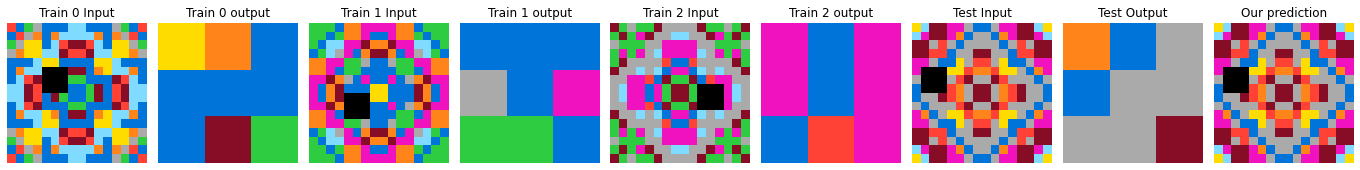

=====
243
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


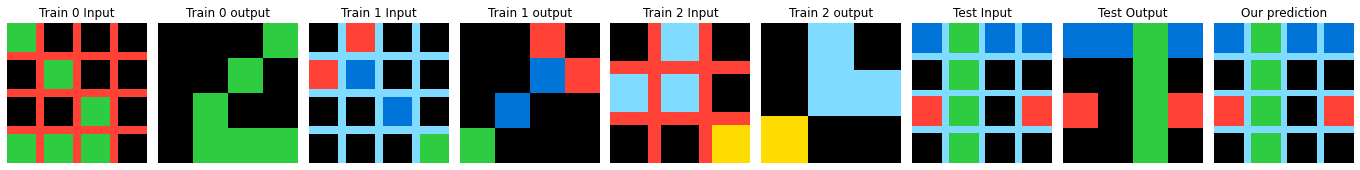

=====
246
non_dimension_related [[], [], [], [0], [], []] [[], [], [], [(3, 2)], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


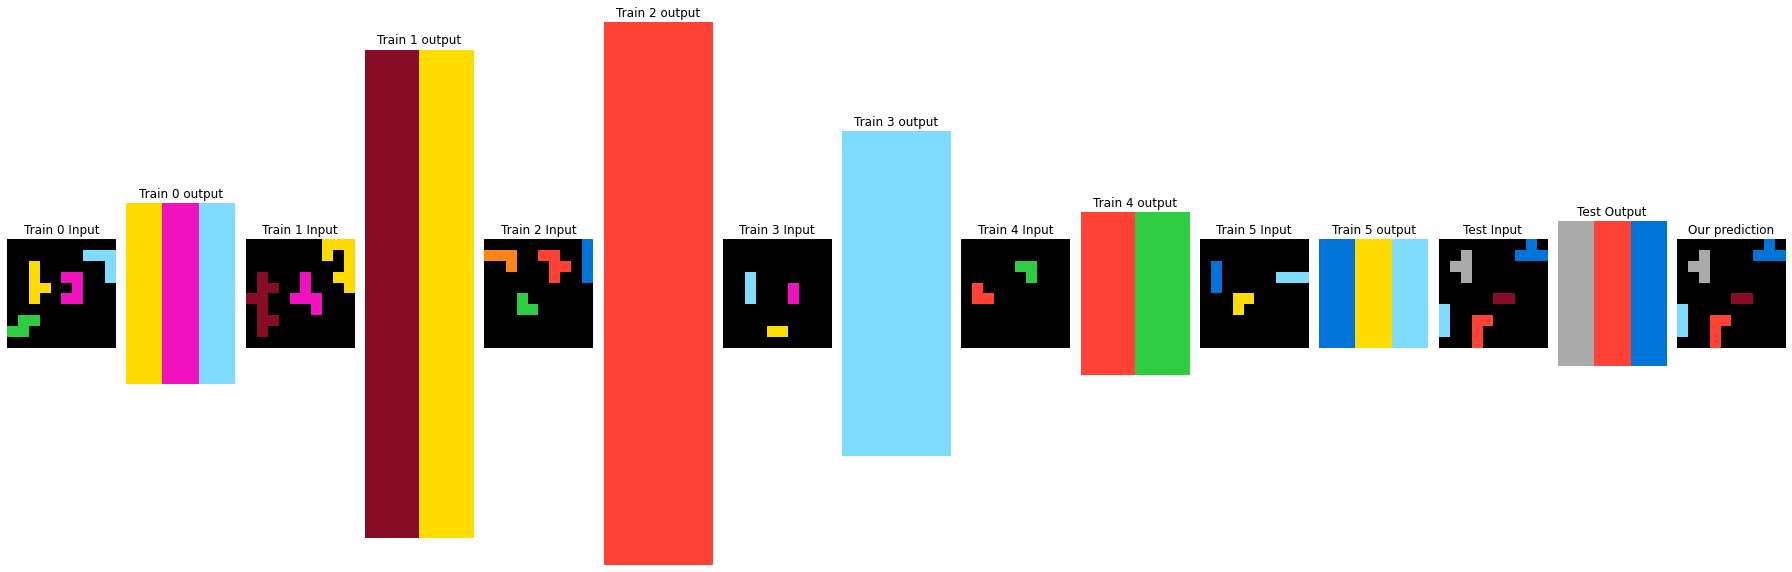

=====
248
expansion [[0, 0], [0, 0], [0, 0]] [[(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 4)]]
is_out_obj_in_in_objs: [(True, 0), (True, 0), (True, 1), (True, 1)]
is_in_obj_in_out_objs: [(True, 0), (True, 2)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 1), (True, 1)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 2)]
overall_movement: [(False, ()), (True, (0, -3)), (True, (0, -3)), (False, ())]


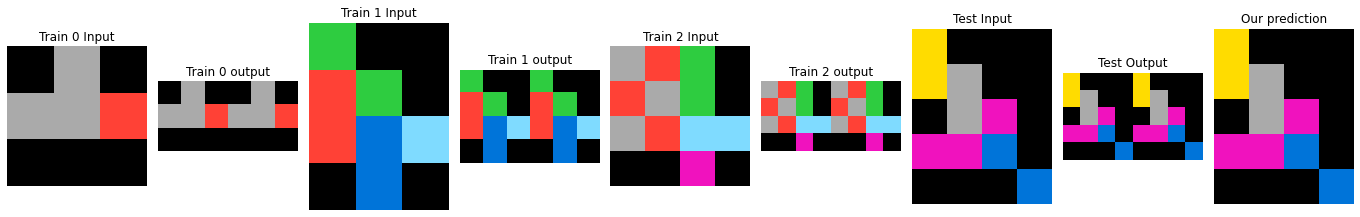

=====
252
non_dimension_related [[], []] [[], []]
is_out_obj_in_in_objs: [(True, 3), (True, 0), (True, 1), (True, 2)]
is_in_obj_in_out_objs: [(True, 1), (True, 2), (True, 3), (True, 0)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (3, -1)), (True, (5, 5)), (True, (1, 6)), (True, (7, 3))]


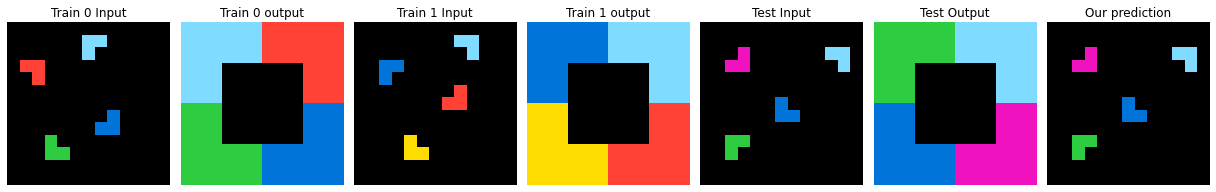

=====
256
non_dimension_related [[], [], [], [], [], []] [[], [], [], [], [], []]
is_out_obj_in_in_objs: [(True, 9), (True, 6), (True, 5), (True, 7), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 2), (True, 1), (True, 3), (True, 2), (True, 0), (True, 3)]
is_out_obj_shape_in_in_objs: [(True, 5), (True, 5), (True, 5), (True, 5), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (5, 0)), (False, ()), (True, (7, 8)), (True, (-2, 5)), (False, ()), (False, ())]


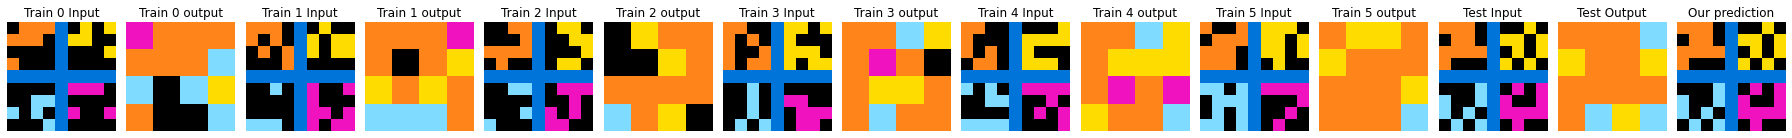

=====
258
non_dimension_related [[], [], [0]] [[], [], [(2, 1)]]
is_out_obj_in_in_objs: [(False, -1), (True, 0), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(True, 1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 0), (True, 0), (False, -1)]
is_in_obj_shape_in_out_objs: [(True, 1), (False, -1)]
overall_movement: [(False, ()), (True, (1, 1)), (False, ()), (False, ())]


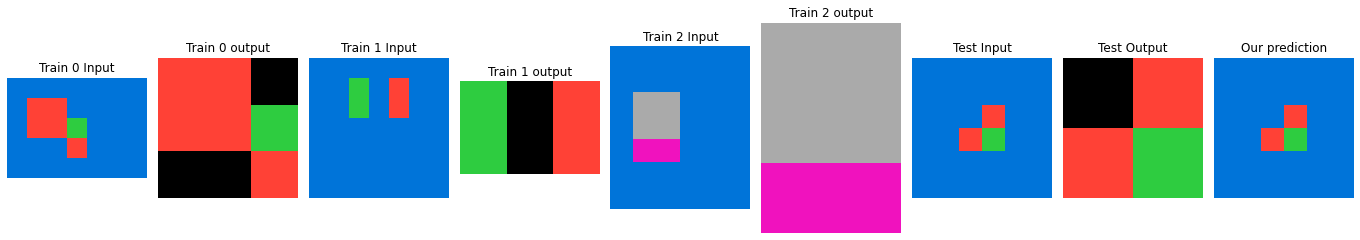

=====
262
contraction [[0], [0], [0], [0]] [[(6, 0)], [(0, 6)], [(0, 3)], [(0, 0)]]
is_out_obj_in_in_objs: [(True, 3), (True, 4)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 0), (True, 1)]
is_out_obj_shape_in_in_objs: [(True, 3), (True, 4)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 0), (True, 1)]
overall_movement: [(True, (6, 0)), (True, (6, 0))]


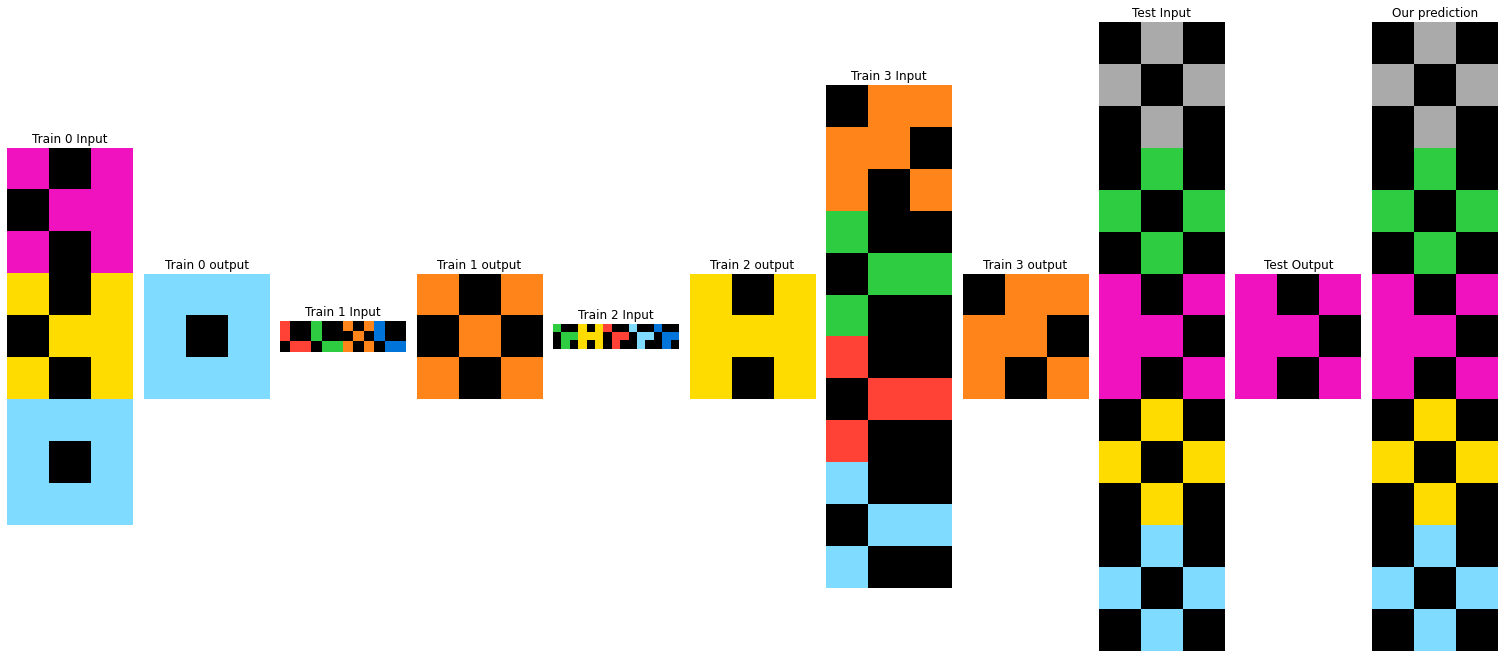

=====
263
non_dimension_related [[], []] [[], []]
is_out_obj_in_in_objs: [(False, -1), (True, 5), (True, 7), (True, 6), (True, 8), (True, 11), (True, 9), (True, 10), (True, 12)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 3), (True, 2), (True, 4), (True, 6), (True, 7), (True, 5), (True, 8), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 5), (True, 6), (True, 6), (True, 5), (True, 9), (True, 9), (True, 9), (True, 9)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 2), (True, 2), (True, 1), (True, 5), (True, 5), (True, 5), (True, 5), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (True, (0, 2)), (True, (1, 5)), (True, (0, 7)), (True, (6, 0)), (True, (7, -5)), (True, (-6, 0)), (True, (11, 10)), (True, (5, -6))]


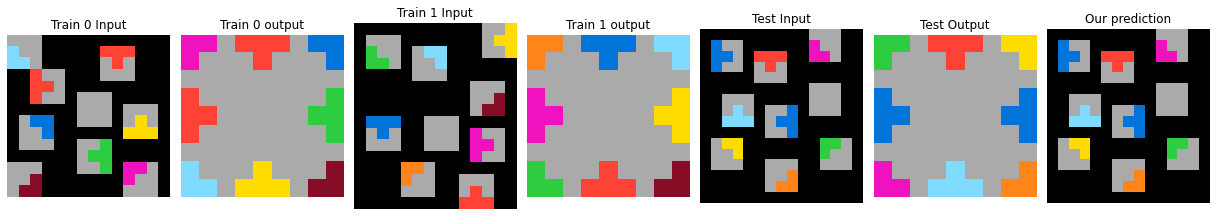

=====
268
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


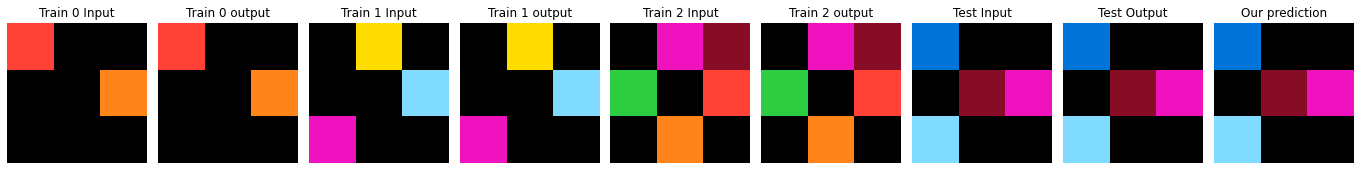

=====
270
contraction [[0], [0], [0], [0]] [[(5, 6)], [(4, 2)], [(4, 6)], [(1, 6)]]
is_out_obj_in_in_objs: [(True, 0), (True, 1)]
is_in_obj_in_out_objs: [(True, 0), (True, 1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 1)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(True, (5, 6)), (True, (5, 6))]


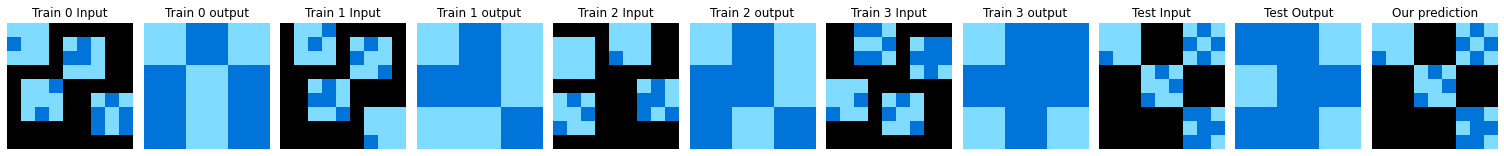

=====
273
non_dimension_related [[], [], [4, 4, 4], [], [], []] [[], [], [(3, 2), (3, 3), (3, 4)], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ())]


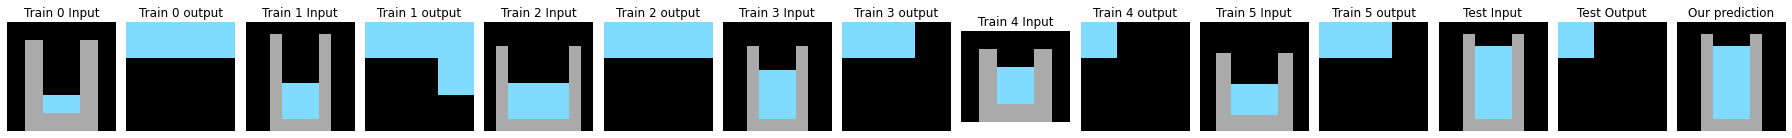

=====
274
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


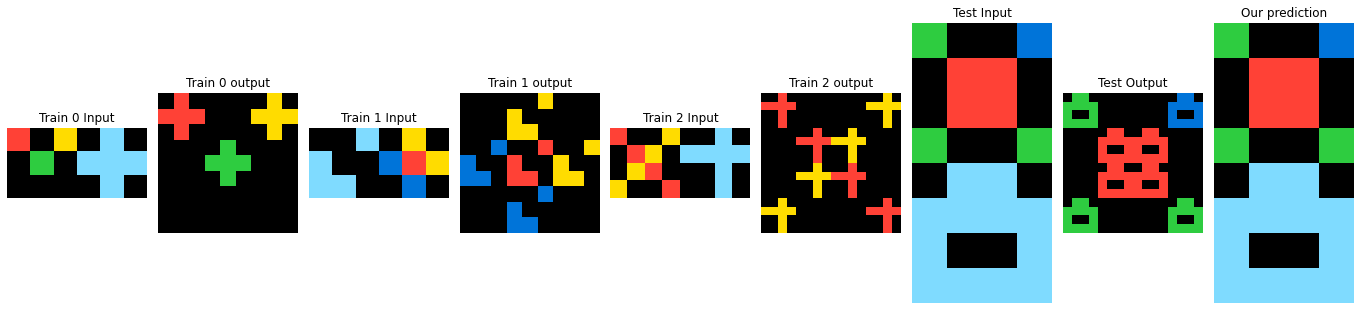

=====
288
non_dimension_related [[], [], [], [], []] [[], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


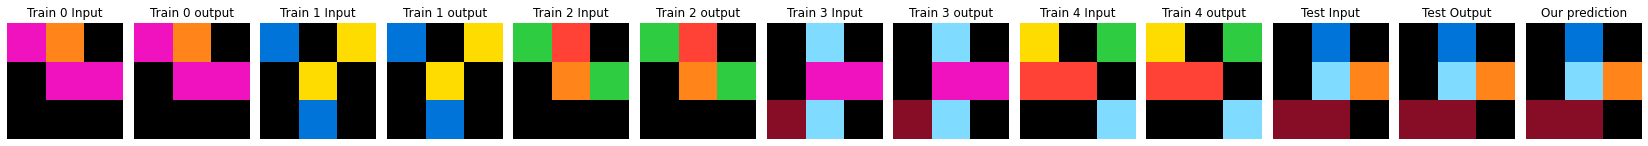

=====
289
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 1)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 1)]
overall_movement: [(False, ()), (False, ())]


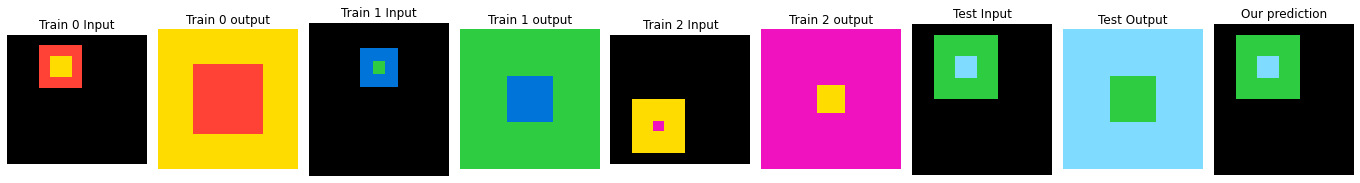

=====
290
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


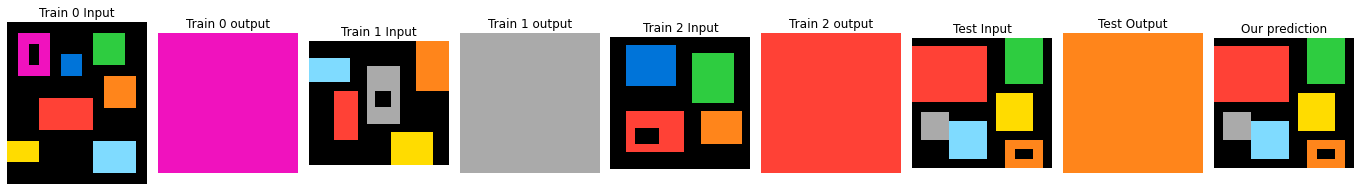

=====
294
expansion [[0], [0], [0], [0], [0]] [[(0, 0)], [(0, 0)], [(0, 0)], [(0, 0)], [(0, 0)]]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


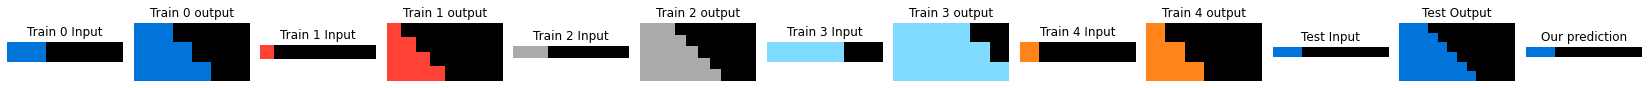

=====
295
non_dimension_related [[], [], [], [], []] [[], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


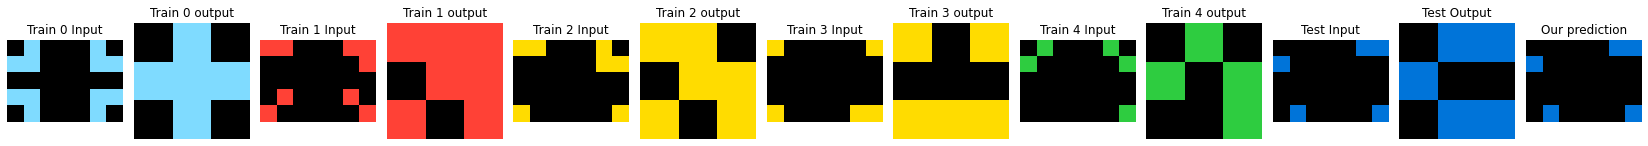

=====
299
contraction [[0], [0], [0], [0]] [[(1, 1)], [(1, 4)], [(1, 1)], [(1, 6)]]
is_out_obj_in_in_objs: [(True, 0)]
is_in_obj_in_out_objs: [(True, 0), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (False, -1), (False, -1)]
overall_movement: [(True, (1, 1))]


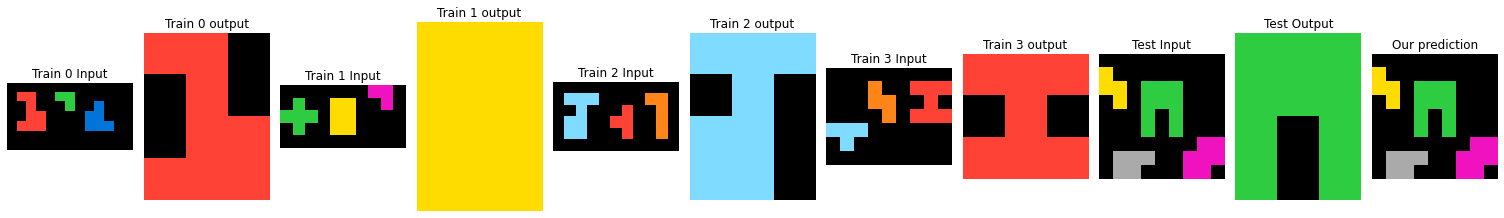

=====
303
expansion [[0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0]] [[(0, 0), (3, 3), (6, 6)], [(0, 0), (0, 6), (3, 6), (6, 0), (6, 3), (6, 6)], [(0, 3), (0, 6), (6, 0), (6, 3)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 3), (True, 4), (True, 3), (True, 3), (True, 4), (True, 4)]
is_in_obj_in_out_objs: [(False, -1), (True, 2), (True, 2), (True, 8), (True, 9)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3), (True, 3)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 2), (True, 2), (True, 8), (True, 8)]
overall_movement: [(False, ()), (False, ()), (True, (2, -2)), (True, (-4, -8)), (True, (-1, -5)), (False, ()), (True, (-3, -3)), (True, (-6, -6)), (False, ()), (True, (-6, -6)), (True, (-6, -6)), (True, (-3, -3)), (True, (-3, -3)), (False, ())]


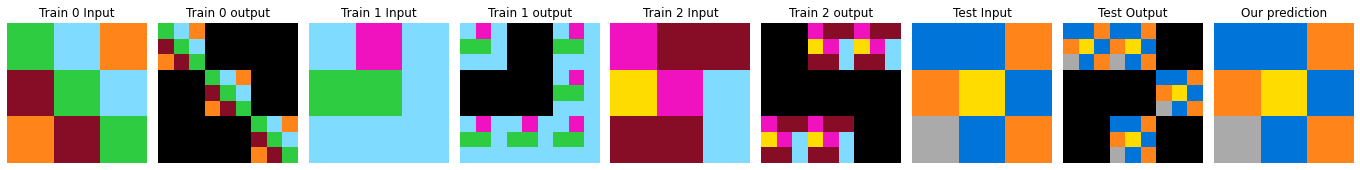

=====
306
non_dimension_related [[], [0], []] [[], [(1, 1)], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


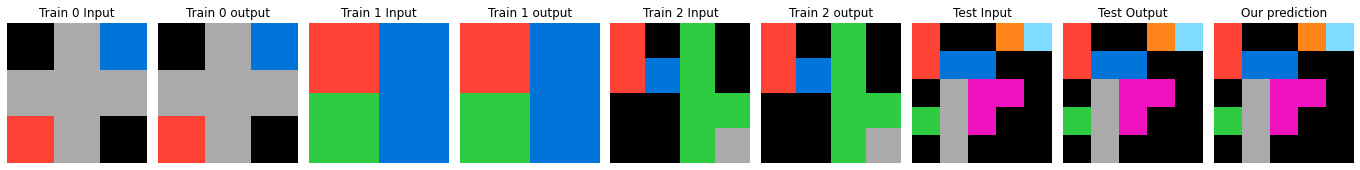

=====
307
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (True, 3), (True, 4), (True, 1), (True, 4), (True, 1), (True, 8), (True, 3), (True, 4), (True, 8), (True, 3), (True, 3), (True, 1), (True, 8), (True, 1), (True, 4), (True, 8)]
is_in_obj_in_out_objs: [(False, -1), (True, 3), (True, 3), (True, 1), (True, 2), (True, 2), (True, 2), (True, 1), (True, 6), (True, 3), (True, 1), (True, 6), (True, 2), (True, 1), (True, 6), (True, 3), (True, 6)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
overall_movement: [(False, ()), (True, (7, 0)), (True, (10, 10)), (True, (4, 6

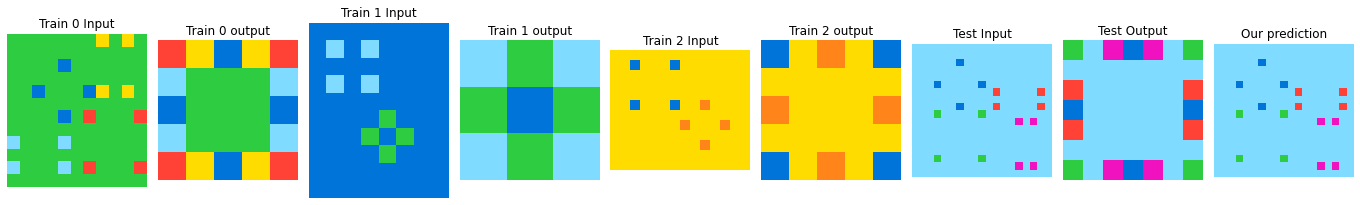

=====
309
contraction [[0], [0], [0]] [[(5, 5)], [(2, 2)], [(17, 5)]]
is_out_obj_in_in_objs: [(True, 23), (True, 27), (True, 86), (True, 80), (True, 81), (True, 86), (True, 80), (True, 80), (True, 80), (True, 81), (True, 141), (True, 142)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (Fals

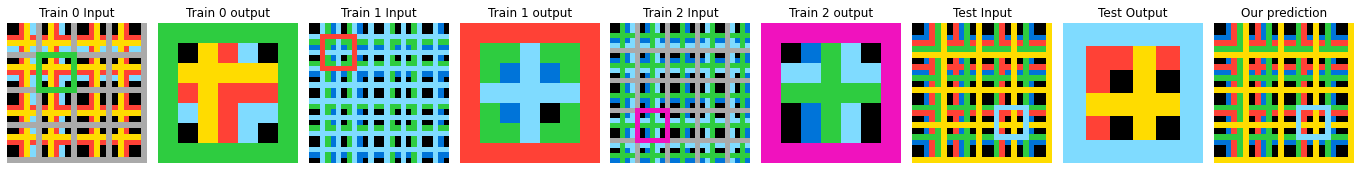

=====
310
expansion [[0, 7], [0, 4], [0, 4]] [[(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 3)]]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


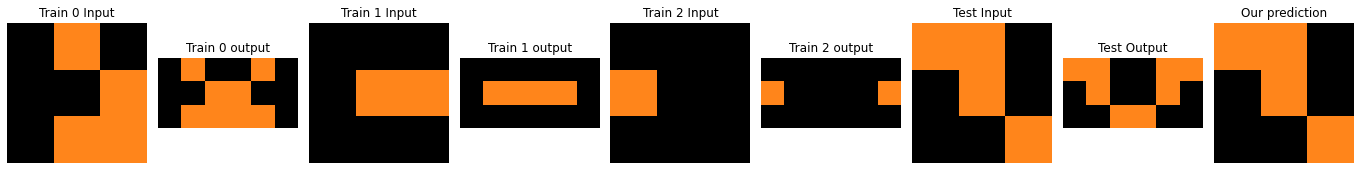

=====
314
expansion [[0], [0, 0], [0, 0, 0, 0]] [[(3, 0)], [(0, 6), (6, 0)], [(0, 0), (0, 6), (3, 3), (6, 0)]]
is_out_obj_in_in_objs: [(True, 0), (True, 1)]
is_in_obj_in_out_objs: [(True, 0), (True, 1)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 1)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 1)]
overall_movement: [(True, (-3, 0)), (True, (-3, 0))]


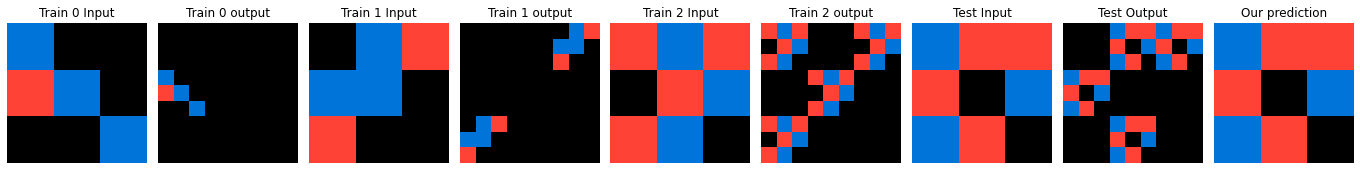

=====
315
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(True, 3), (True, 0), (True, 1), (True, 5), (True, 4), (True, 2)]
is_in_obj_in_out_objs: [(True, 1), (True, 2), (True, 5), (True, 0), (True, 4), (True, 3)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (2, 0)), (True, (8, 0)), (True, (6, 9)), (True, (4, 5)), (True, (1, 2)), (True, (4, 0))]


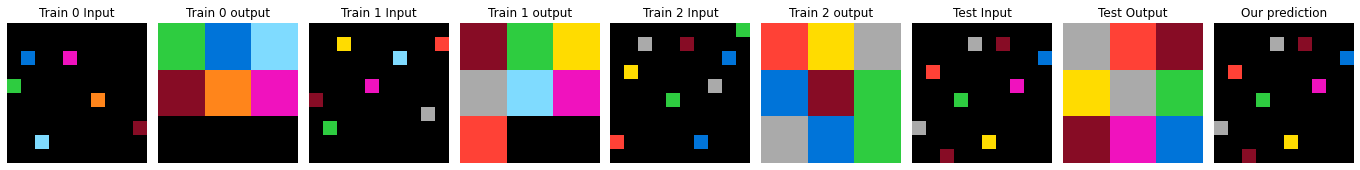

=====
317
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


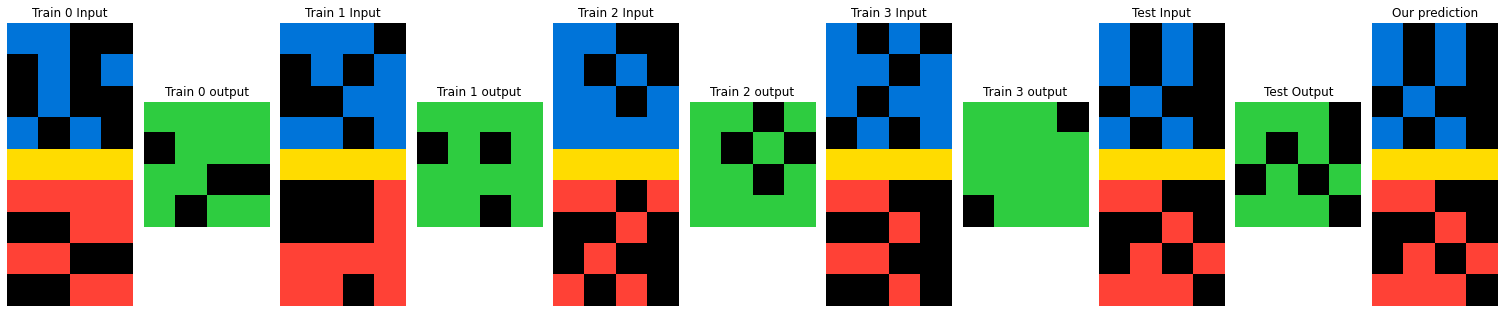

=====
318
contraction [[0], [0], [0], [0]] [[(3, 3)], [(8, 11)], [(2, 4)], [(9, 8)]]
is_out_obj_in_in_objs: [(True, 2), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (True, 0), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 2), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (True, 0), (True, 0), (False, -1), (False, -1)]
overall_movement: [(True, (3, 3)), (False, ())]


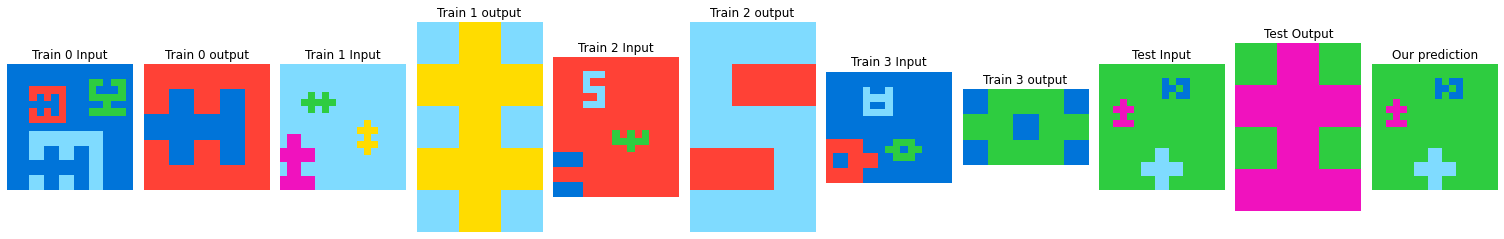

=====
320
non_dimension_related [[], [], [], [], []] [[], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 5), (True, 6)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 3), (True, 4), (True, 4)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 5), (True, 5)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 3), (True, 3), (True, 3)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (True, (3, 7))]


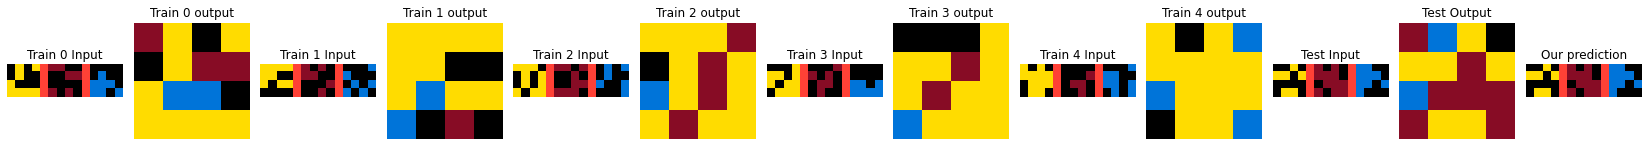

=====
324
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


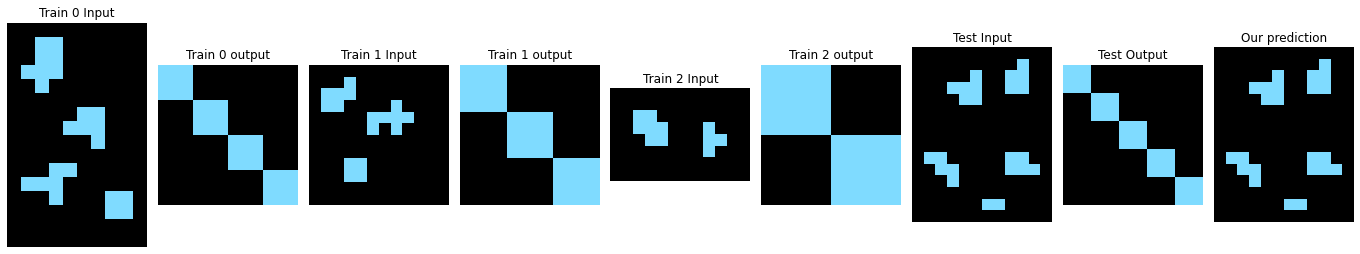

=====
325
contraction [[0, 5, 4, 5, 0, 3, 4, 3, 0], [0, 5, 4, 3, 3, 4, 5, 0, 0, 5, 4, 3, 3, 4, 5, 0], [0, 5, 4, 5, 0, 3, 4, 3, 0, 3, 4, 5, 0, 5, 4, 5, 0, 3]] [[(0, 0), (0, 2), (0, 4), (2, 0), (2, 2), (2, 4), (4, 0), (4, 2), (4, 4)], [(0, 0), (0, 2), (0, 4), (0, 6), (2, 0), (2, 2), (2, 4), (2, 6), (4, 0), (4, 2), (4, 4), (4, 6), (6, 0), (6, 2), (6, 4), (6, 6)], [(0, 0), (0, 2), (0, 4), (2, 0), (2, 2), (2, 4), (4, 0), (4, 2), (4, 4), (6, 0), (6, 2), (6, 4), (8, 0), (8, 2), (8, 4), (10, 0), (10, 2), (10, 4)]]
is_out_obj_in_in_objs: [(True, 16), (True, 11), (True, 15), (True, 14)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 3), (True, 2), (True, 0), (True, 2), (True, 2), (True, 3), (True, 3), (True, 0), (True, 0)]
is_out_obj_shape_in_in_objs: [(True, 11), (True, 11), (True, 11), (True, 11)]
is_in_obj_shape_in_out_objs: [(False, -

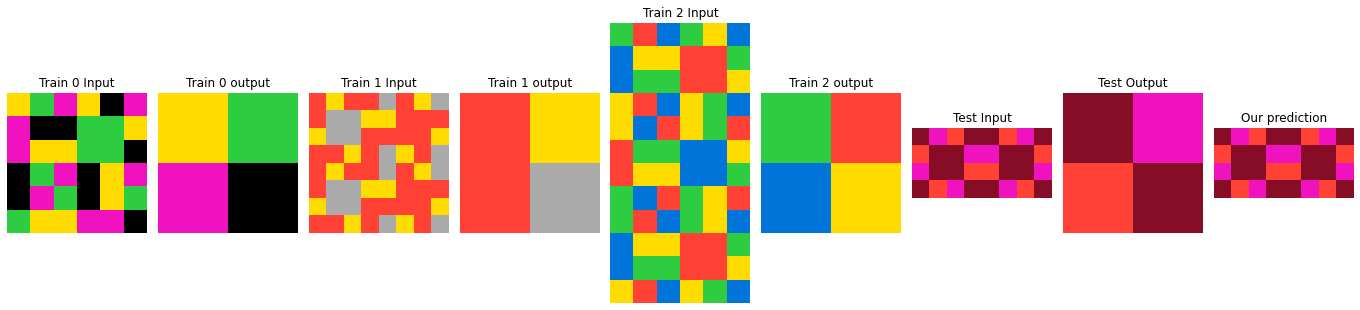

=====
326
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


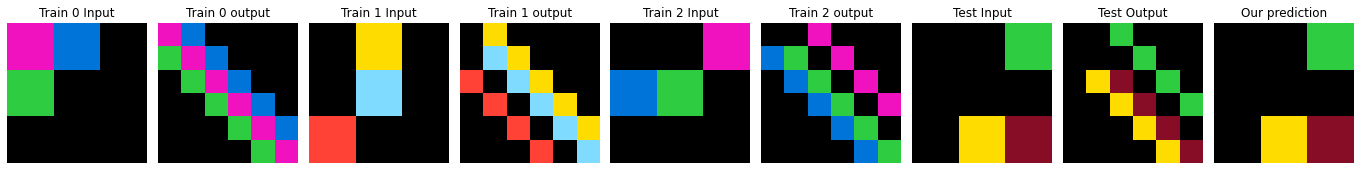

=====
333
non_dimension_related [[], [], [], [], [], [], []] [[], [], [], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


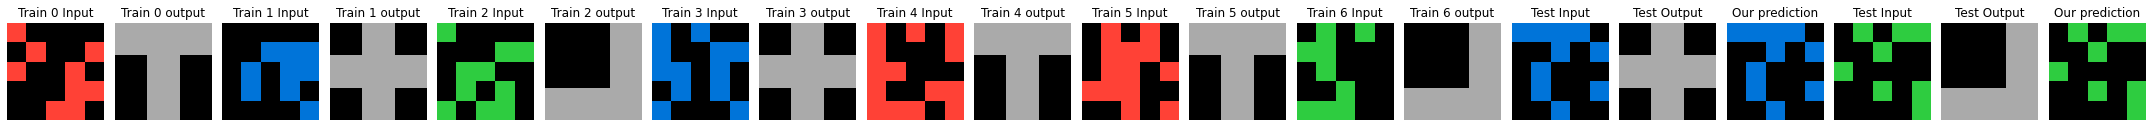

=====
338
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


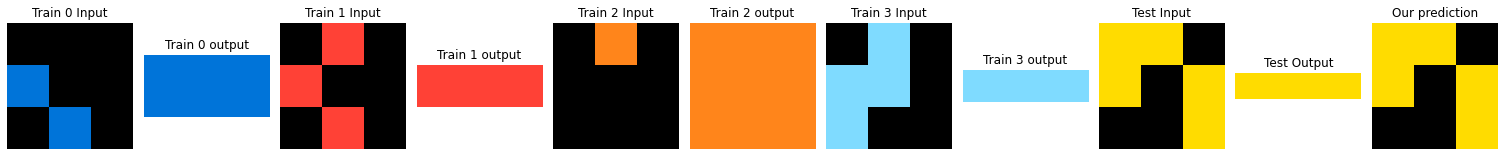

=====
345
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(True, 1)]
is_in_obj_in_out_objs: [(False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 1)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (False, -1)]
overall_movement: [(False, ())]


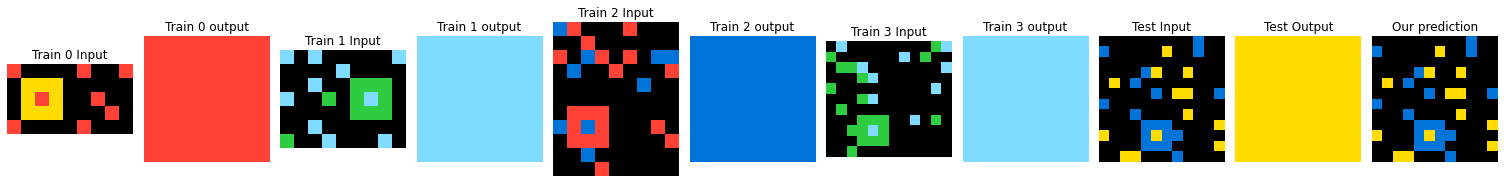

=====
346
non_dimension_related [[], [], [], [], []] [[], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 0), (True, 2)]
is_in_obj_shape_in_out_objs: [(True, 0), (True, 0), (True, 1)]
overall_movement: [(False, ()), (False, ())]


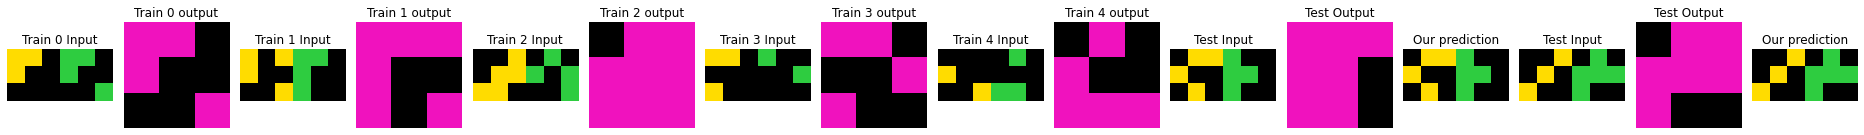

=====
350
contraction [[7, 4], [7, 5, 3, 2, 6, 4], [3, 1, 5, 4, 6]] [[(5, 2), (6, 2)], [(0, 8), (3, 11), (8, 0), (8, 11), (11, 3), (11, 8)], [(4, 0), (7, 0), (7, 11), (11, 4), (11, 7)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 12), (False, -1), (True, 17), (False, -1), (True, 47)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 3), (False, -1), (False, -1), (False, -1), (False, -1), (True, 5), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 7), (False, -1), (False, -1), (False, -1), (False, 

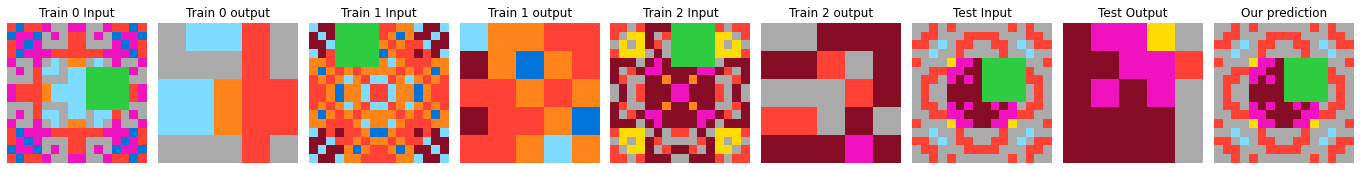

=====
354
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(True, 2)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (False, -1), (False, -1)]
overall_movement: [(False, ())]


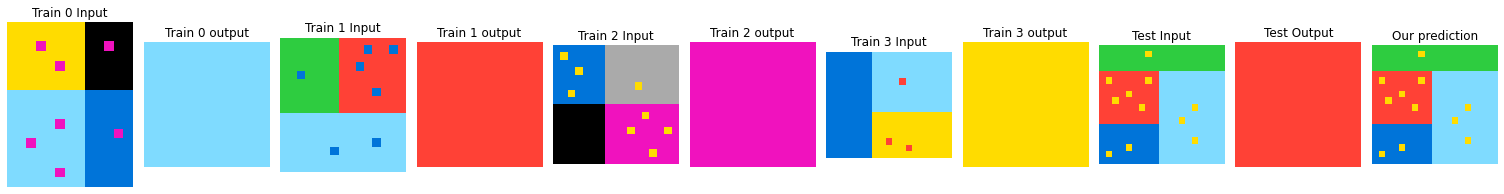

=====
359
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


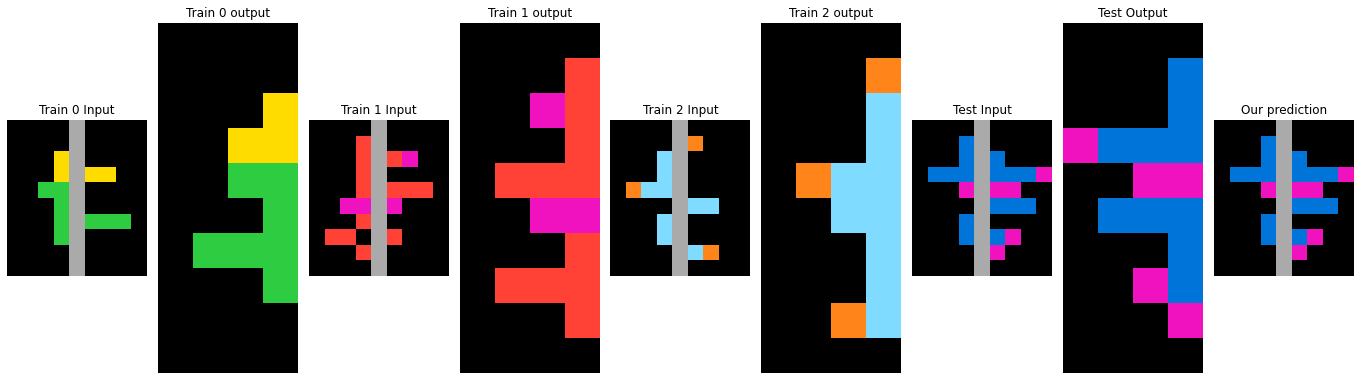

=====
364
contraction [[0], [0], [0]] [[(0, 6)], [(7, 1)], [(0, 0)]]
is_out_obj_in_in_objs: [(True, 1), (True, 3), (True, 4), (True, 12)]
is_in_obj_in_out_objs: [(False, -1), (True, 0), (False, -1), (True, 1), (True, 2), (True, 2), (True, 1), (True, 2), (True, 1), (True, 2), (True, 1), (False, -1), (True, 3)]
is_out_obj_shape_in_in_objs: [(True, 1), (True, 3), (True, 3), (True, 12)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (False, -1), (True, 3)]
overall_movement: [(True, (0, 6)), (True, (5, 4)), (True, (0, 2)), (True, (0, 6))]


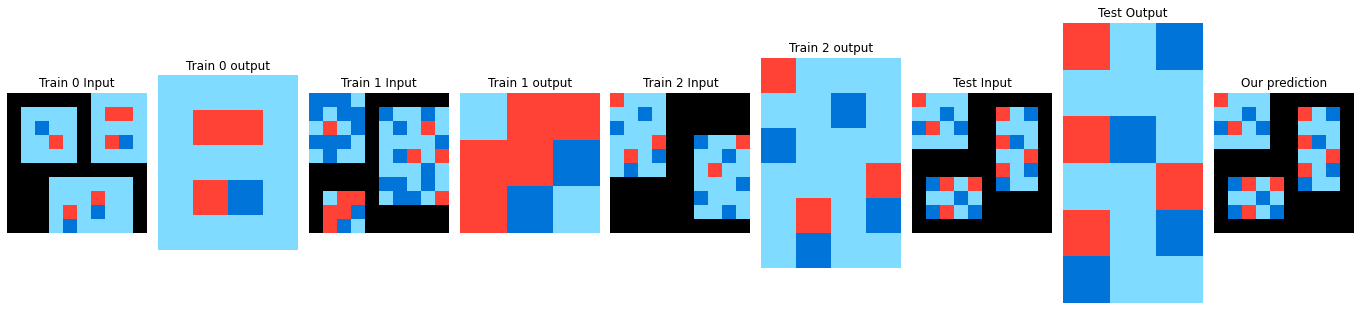

=====
365
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(True, 1), (True, 3), (True, 8), (True, 8), (True, 10), (True, 10), (True, 10)]
is_in_obj_in_out_objs: [(False, -1), (True, 0), (False, -1), (True, 1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 2), (True, 2), (True, 4), (True, 4), (True, 4), (True, 4), (True, 4), (True, 4)]
is_out_obj_shape_in_in_objs: [(True, 1), (True, 3), (True, 8), (True, 8), (True, 10), (True, 10), (True, 10)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (False, -1), (True, 1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 2), (True, 2), (True, 4), (True, 4), (True, 4), (True, 4), (True, 4), (True, 4)]
overall_movement: [(True, (-2, 0)), (True, (3, -6)), (True, (-2, 0)), (True, (1, 0)), (True, (15, 0)), (True, (16, -2)), (True, (15, -4))]


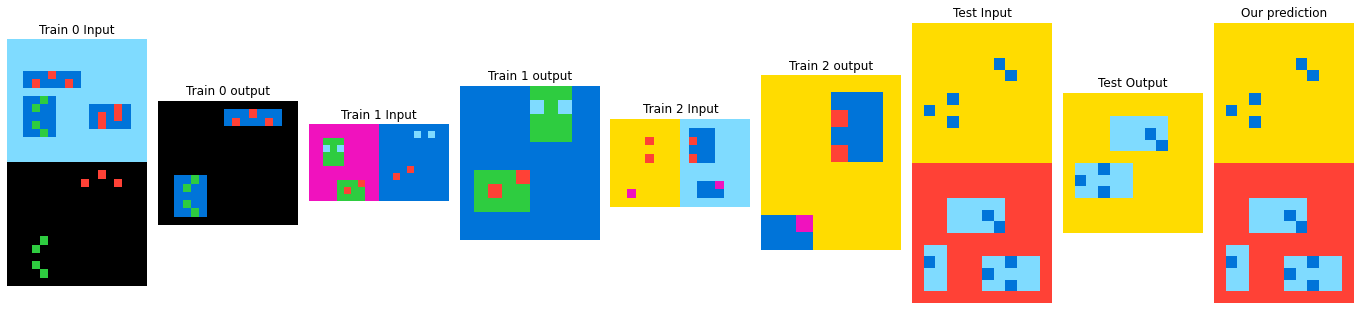

=====
371
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(True, 2), (True, 2), (True, 1), (True, 1), (True, 2), (True, 1), (True, 2), (True, 2), (True, 1), (True, 2), (True, 1)]
is_in_obj_in_out_objs: [(False, -1), (True, 2), (True, 0), (True, 2), (True, 0), (True, 0), (True, 2), (True, 0), (True, 0), (True, 2), (True, 0), (True, 2)]
is_out_obj_shape_in_in_objs: [(True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
is_in_obj_shape_in_out_objs: [(False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (8, 2)), (True, (5, 8)), (False, ()), (True, (2, -2)), (True, (5, -2)), (True, (2, -6)), (True, (6, 6)), (True, (6, 0)), (True, (0, -8)), (True, (8, 4)), (True, (4, -4))]


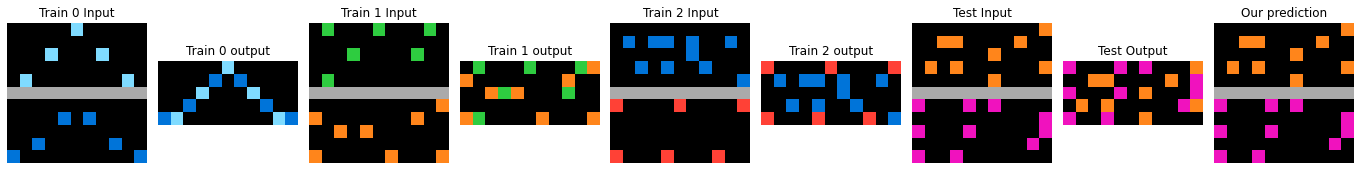

=====
375
expansion [[0, 4, 0, 4], [0, 4, 0, 4]] [[(0, 0), (2, 0), (4, 0), (6, 0)], [(0, 0), (3, 0), (6, 0), (9, 0)]]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


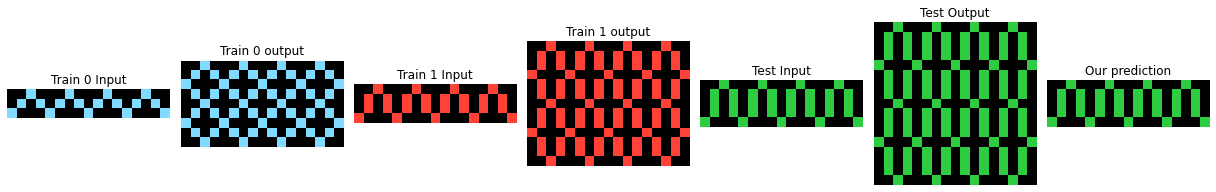

=====
376
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


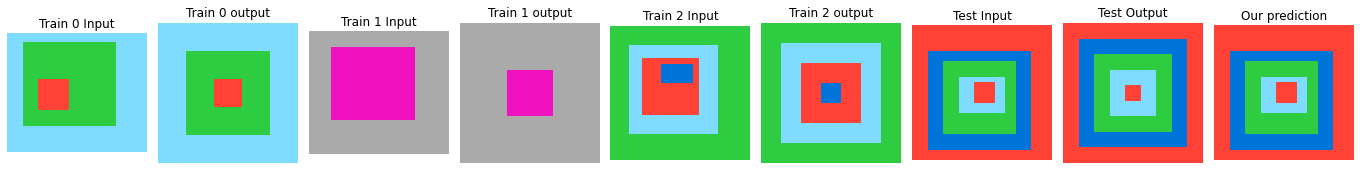

=====
383
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


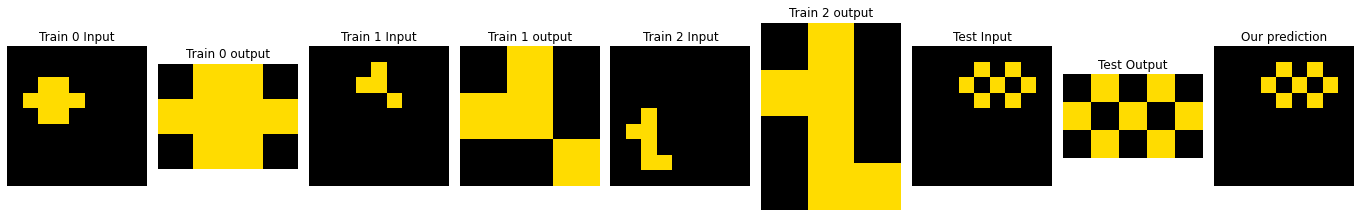

=====
385
non_dimension_related [[], [], [], [], []] [[], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


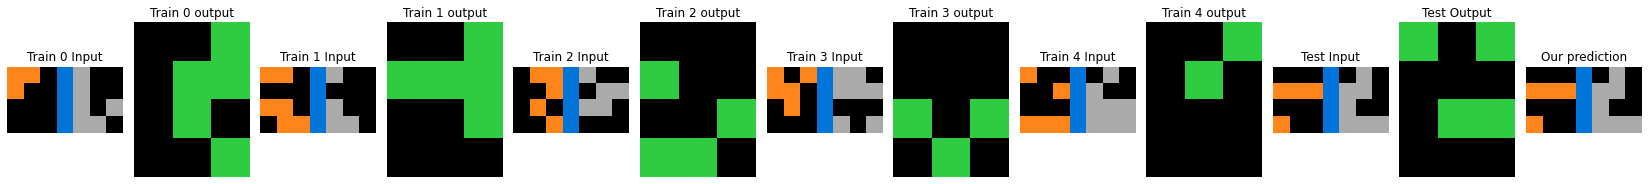

=====
387
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_in_out_objs: [(True, 6), (True, 6)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
is_in_obj_shape_in_out_objs: [(True, 6), (True, 6)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (True, (-3, -3)), (True, (2, 2)), (True, (-1, 2)), (True, (2, -1)), (True, (0, -3)), (True, (-3, 0))]


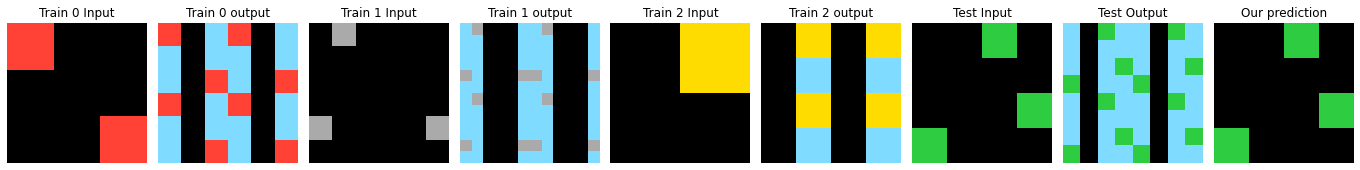

=====
390
non_dimension_related [[], [], [], []] [[], [], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


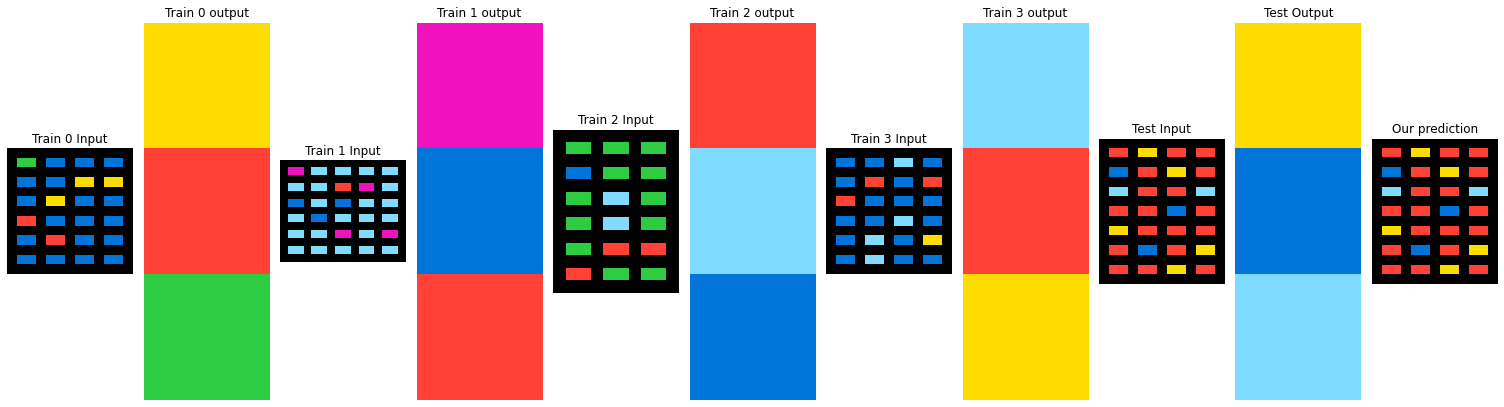

=====
392
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]


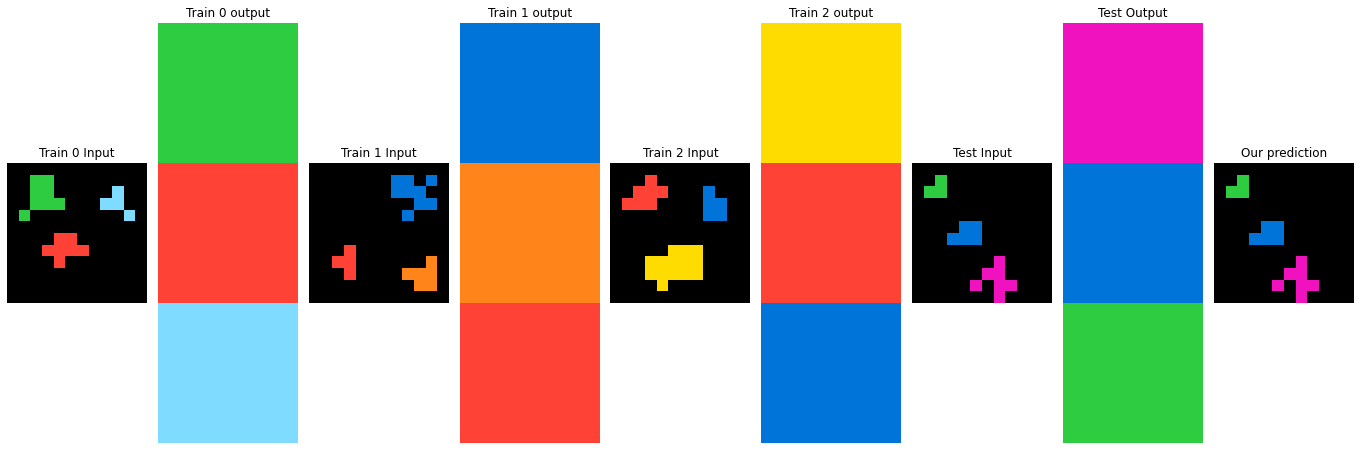

=====
393
contraction [[5, 1, 5, 1, 0, 3, 0, 3, 5, 1, 0, 3], [], [2, 3, 2, 3, 5, 0, 5, 0, 2, 3, 5, 0]] [[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 2), (3, 3)], [], [(1, 1), (1, 2), (1, 4), (1, 5), (2, 1), (2, 2), (2, 4), (2, 5), (4, 1), (4, 2), (5, 1), (5, 2)]]
is_out_obj_in_in_objs: [(True, 2), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
is_out_obj_shape_in_in_objs: [(True, 2), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(True, (3, 2)), (False, ())]


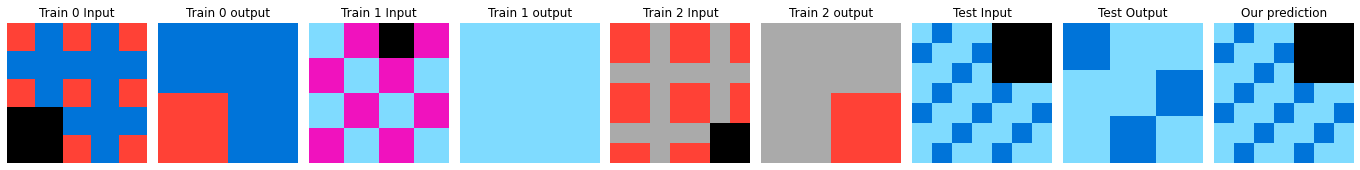

=====
394
non_dimension_related [[], [], [], [], []] [[], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ())]


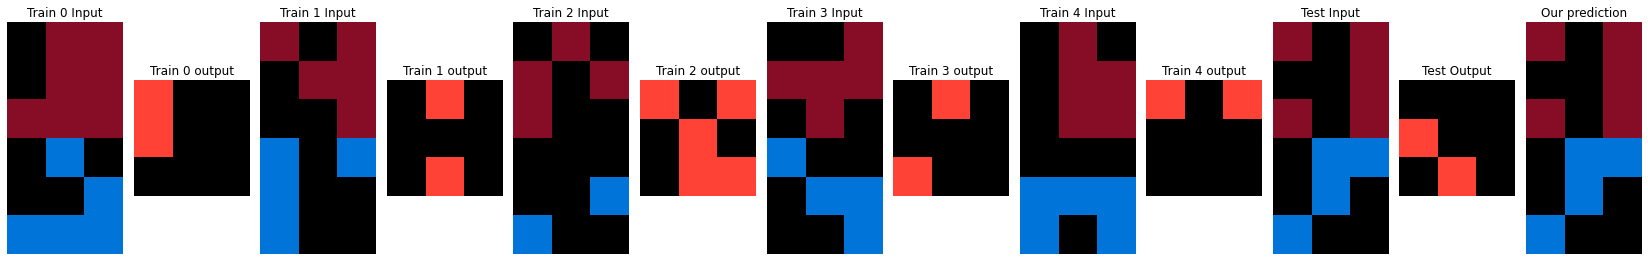

=====
395
non_dimension_related [[], [], []] [[], [], []]
is_out_obj_in_in_objs: [(False, -1), (True, 3)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
is_out_obj_shape_in_in_objs: [(False, -1), (True, 3)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1)]
overall_movement: [(False, ()), (True, (8, 0))]


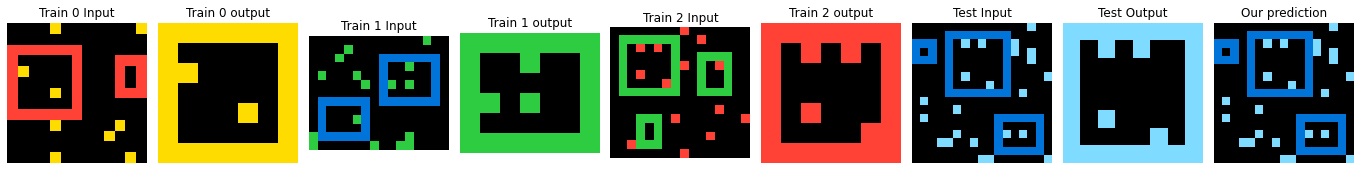

=====
397
expansion [[0, 0, 0, 0, 0, 0], [0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [4, 0]] [[(4, 5), (5, 4), (6, 3), (7, 2), (8, 1), (9, 0)], [(4, 0)], [(4, 10), (5, 9), (6, 8), (7, 7), (8, 6), (9, 5), (10, 4), (11, 3), (12, 2), (13, 1), (14, 0)], [(4, 10), (5, 9), (6, 8), (7, 7), (8, 6), (9, 5), (10, 4), (11, 3), (12, 2), (13, 1), (14, 0)], [(2, 0), (4, 0)]]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1), (False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]


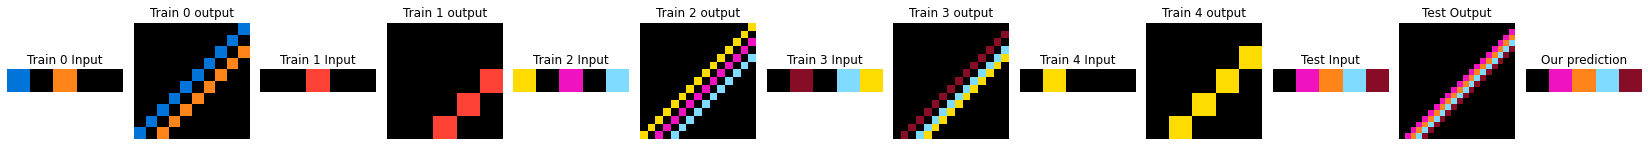

=====
398
non_dimension_related [[], [], [], [], [], [], [], []] [[], [], [], [], [], [], [], []]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1)]
overall_movement: [(False, ())]


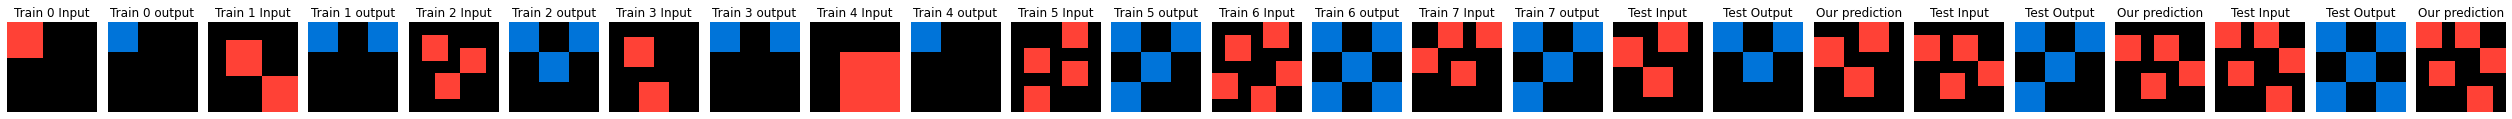

=====
399
contraction [[7, 3, 1, 5, 4, 6], [5, 1, 4, 7, 3], [4, 6, 2, 3, 5, 1]] [[(0, 1), (1, 0), (18, 0), (18, 19), (19, 1), (19, 18)], [(6, 8), (6, 11), (8, 13), (11, 13), (13, 11)], [(4, 9), (4, 10), (9, 4), (9, 15), (10, 4), (10, 15)]]
is_out_obj_in_in_objs: [(False, -1)]
is_in_obj_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
is_out_obj_shape_in_in_objs: [(False, -1)]
is_in_obj_shape_in_out_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ())]


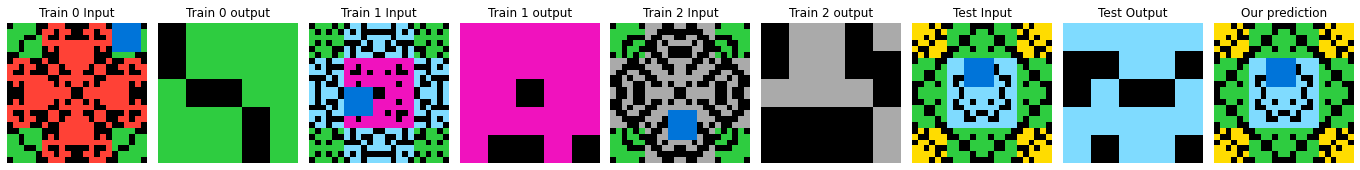

=====


In [37]:
for n in range(400):
    this_task = this_analysis[n]
    if this_task.is_same_dim_couple == False:
        print(n)
        scenario = this_task.out_in_rel[0][2]
        arrangements = [[j[0] for j in i[1]] for i in this_task.out_in_rel]
        steps = [[j[1] for j in i[1]] for i in this_task.out_in_rel]
        print(scenario, arrangements, steps)
        print('is_out_obj_in_in_objs:', [is_out_obj_in_in_objs(x, this_task.traininput_objects[0]) for x in this_task.trainoutput_objects[0]])
        print('is_in_obj_in_out_objs:', [is_out_obj_in_in_objs(x, this_task.trainoutput_objects[0]) for x in this_task.traininput_objects[0]])
        print('is_out_obj_shape_in_in_objs:', [is_out_obj_shape_in_in_objs(x, this_task.traininput_objects[0]) for x in this_task.trainoutput_objects[0]])
        print('is_in_obj_shape_in_out_objs:', [is_out_obj_shape_in_in_objs(x, this_task.trainoutput_objects[0]) for x in this_task.traininput_objects[0]])
        print('overall_movement:', overall_movement(this_task.trainoutput_objects[0], this_task.traininput_objects[0]))
        plot_task_eval(tt[n], this_task.testinputs)
        print('=====')

In [7]:

to_inspect = [173, 212, 215, 232, 299, 324, 364, 395]

In [12]:
tests

49

0
expansion:
[[0, 4, 0, 0, 4, 0, 4, 0, 0, 4, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0, 0, 0], [0, 7, 0, 7, 0, 0, 7, 0]] [[(0, 3), (0, 4), (0, 6), (3, 0), (3, 1), (3, 3), (3, 4), (3, 6), (6, 3), (6, 4), (6, 6)], [(0, 0), (0, 6), (6, 3)], [(3, 6), (6, 0), (6, 6)], [(0, 0), (0, 3), (3, 0), (6, 3), (6, 6)], [(0, 0), (0, 1), (0, 3), (0, 4), (0, 6), (6, 3), (6, 4), (6, 6)]]


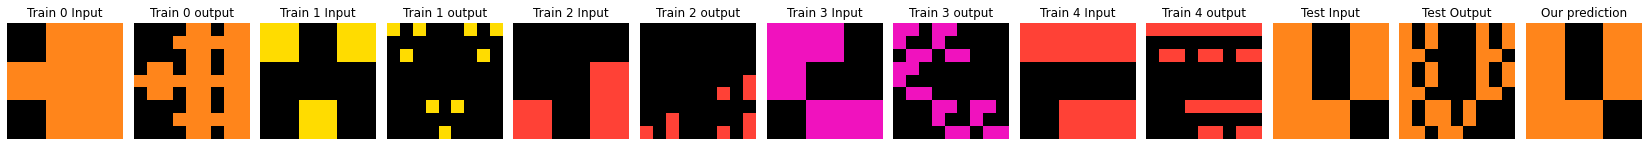

traininput_objects: [[0, 3, 0, 3, 3, 3, 7, 7, 7, 7, 7, 7, 1, 7]]
trainoutput_objects: [[0, 9, 0, 9, 9, 9, 7, 49, 7, 49, 7, 49, 1, 49]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
13
contraction:
[[0], [0], [0]] [[(11, 0)], [(11, 10)], [(10, 0)]]


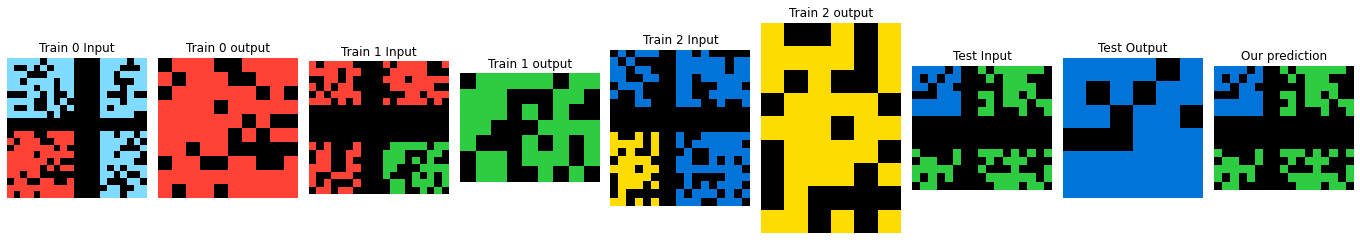

traininput_objects: [[11, 21, 0, 10, 10, 10, 2, 72, 2, 72, 2, 72, 1, 72], [0, 9, 0, 10, 9, 10, 8, 60, 8, 60, 8, 60, 1, 60], [11, 21, 14, 21, 10, 7, 8, 46, 8, 46, 8, 46, 1, 46], [0, 9, 14, 21, 9, 7, 8, 45, 8, 45, 8, 45, 1, 45]]
trainoutput_objects: [[0, 10, 0, 10, 10, 10, 2, 72, 2, 72, 2, 72, 1, 72]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (11, 0))]
20
contraction:
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]] [[(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (7, 2), (7, 3), (7,

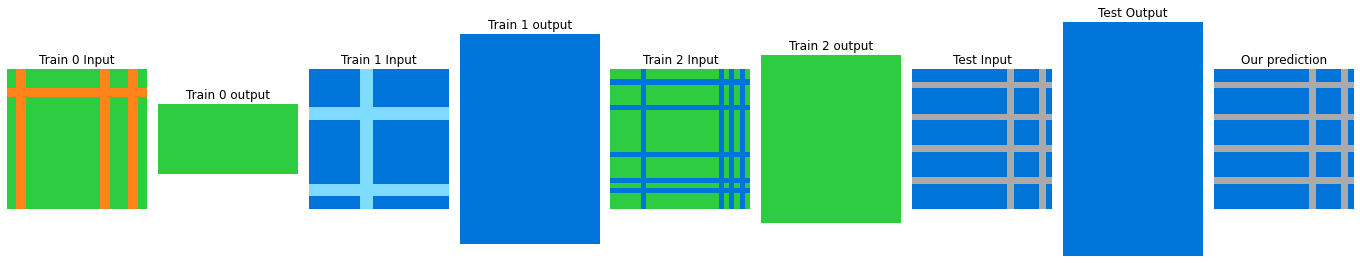

traininput_objects: [[3, 15, 2, 10, 12, 8, 3, 96, 3, 96, 3, 96, 1, 96], [0, 15, 0, 15, 15, 15, 7, 57, 3, 168, 7, 57, 2, 225], [3, 15, 11, 13, 12, 2, 3, 24, 3, 24, 3, 24, 1, 24], [0, 2, 2, 10, 2, 8, 3, 16, 3, 16, 3, 16, 1, 16], [3, 15, 0, 1, 12, 1, 3, 12, 3, 12, 3, 12, 1, 12], [3, 15, 14, 15, 12, 1, 3, 12, 3, 12, 3, 12, 1, 12], [0, 2, 11, 13, 2, 2, 3, 4, 3, 4, 3, 4, 1, 4], [0, 2, 0, 1, 2, 1, 3, 2, 3, 2, 3, 2, 1, 2], [0, 2, 14, 15, 2, 1, 3, 2, 3, 2, 3, 2, 1, 2]]
trainoutput_objects: [[0, 2, 0, 4, 2, 4, 3, 8, 3, 8, 3, 8, 1, 8]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
28
contraction:
[[0], [0], [0]] [[(4, 5)], [(7, 3)], [(3, 4)]]


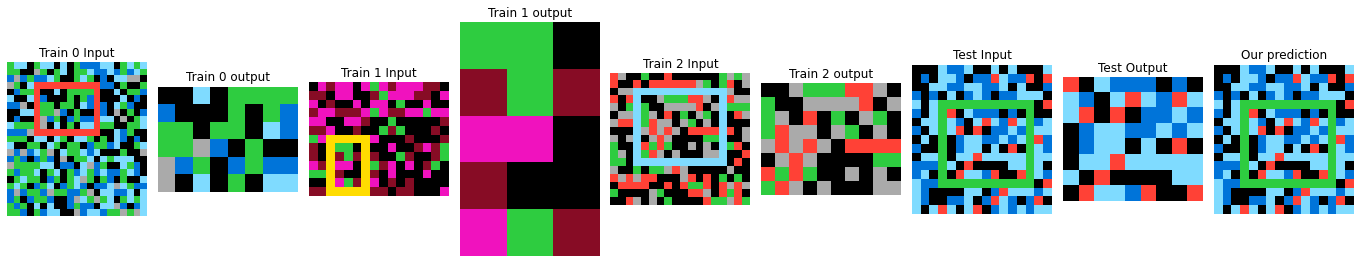

traininput_objects: [[19, 23, 20, 21, 4, 1, 8, 4, 8, 4, 8, 4, 1, 4], [11, 21, 0, 6, 10, 6, 3, 26, 3, 26, 5, 4, 4, 50], [10, 11, 0, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3], [9, 10, 1, 4, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3], [10, 13, 16, 17, 3, 1, 8, 3, 8, 3, 8, 3, 1, 3], [21, 23, 6, 8, 2, 2, 8, 3, 8, 3, 8, 3, 1, 3], [15, 19, 17, 19, 4, 2, 3, 4, 3, 4, 8, 3, 2, 7], [20, 23, 0, 3, 3, 3, 3, 5, 3, 5, 1, 3, 2, 8], [4, 10, 8, 13, 6, 5, 3, 11, 3, 11, 8, 3, 3, 20], [3, 11, 4, 14, 8, 10, 2, 32, 2, 32, 5, 3, 5, 64], [10, 12, 17, 18, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2], [0, 1, 1, 3, 1, 2, 8, 2, 8, 2, 8, 2, 1, 2], [2, 3, 18, 20, 1, 2, 5, 2, 5, 2, 5, 2, 1, 2], [6, 8, 14, 15, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2], [19, 20, 16, 18, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [0, 1, 5, 7, 1, 2, 8, 2, 8, 2, 8, 2, 1, 2], [6, 7, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [9, 10, 11, 13, 1, 2, 8, 2, 8, 2, 8, 2, 1, 2], [8, 10, 5, 6, 2, 1, 5, 2, 5, 2, 5, 2, 1, 2], [0, 2, 17, 18, 2, 1, 3, 2, 3, 2, 3, 2, 1, 2], [15, 17, 19, 20, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2

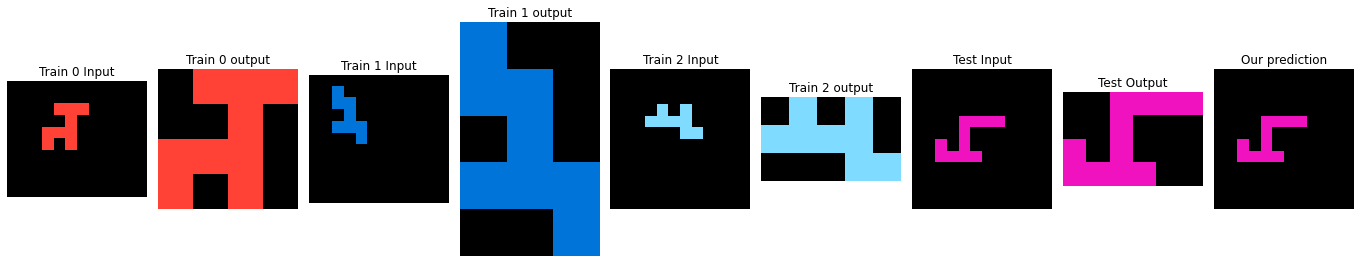

traininput_objects: [[2, 6, 3, 7, 4, 4, 2, 9, 2, 9, 2, 9, 1, 9]]
trainoutput_objects: [[0, 4, 0, 4, 4, 4, 2, 9, 2, 9, 2, 9, 1, 9]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (2, 3))]
35
contraction:
[[0], [0]] [[(10, 17)], [(9, 11)]]


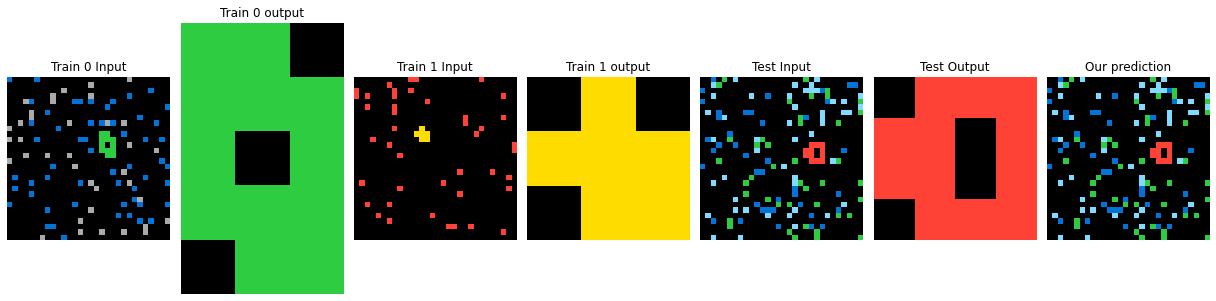

traininput_objects: [[10, 15, 17, 20, 5, 3, 3, 12, 3, 12, 3, 12, 1, 12], [27, 28, 7, 9, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [27, 29, 25, 26, 2, 1, 5, 2, 5, 2, 5, 2, 1, 2], [6, 8, 4, 5, 2, 1, 5, 2, 5, 2, 5, 2, 1, 2], [4, 5, 12, 14, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [11, 12, 13, 15, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [3, 5, 8, 9, 2, 1, 5, 2, 5, 2, 5, 2, 1, 2], [19, 21, 15, 17, 2, 2, 5, 2, 5, 2, 5, 2, 1, 2], [15, 17, 28, 30, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2], [4, 6, 18, 20, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2], [13, 14, 15, 16, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [2, 3, 26, 27, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [19, 20, 13, 14, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [8, 9, 4, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 1, 5, 6, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [9, 10, 9, 10, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [8, 9, 15, 16, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [25, 26, 22, 23, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [8, 9, 11, 12, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1], [21, 22, 4, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [11, 12, 2, 3, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1], [

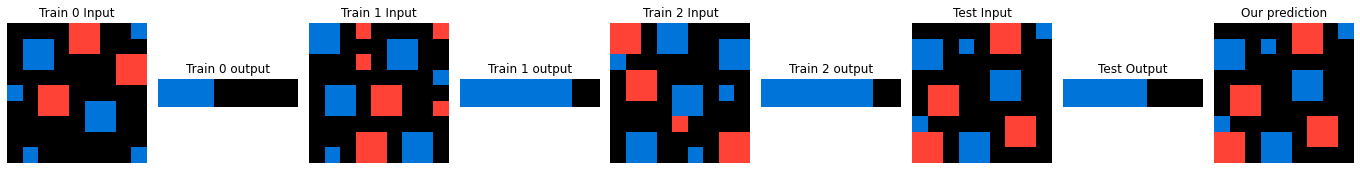

traininput_objects: [[4, 6, 2, 4, 2, 2, 2, 4, 2, 4, 2, 4, 1, 4], [0, 2, 4, 6, 2, 2, 2, 4, 2, 4, 2, 4, 1, 4], [1, 3, 1, 3, 2, 2, 1, 4, 1, 4, 1, 4, 1, 4], [2, 4, 7, 9, 2, 2, 2, 4, 2, 4, 2, 4, 1, 4], [5, 7, 5, 7, 2, 2, 1, 4, 1, 4, 1, 4, 1, 4], [8, 9, 8, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [4, 5, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 1, 8, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [8, 9, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
trainoutput_objects: [[0, 1, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
38
contraction:
[[0, 5, 3, 2], [0, 5, 3, 4]] [[(2, 2), (2, 5), (5, 2), (5, 5)], [(1, 1), (1, 4), (4, 1), (4, 4)]]


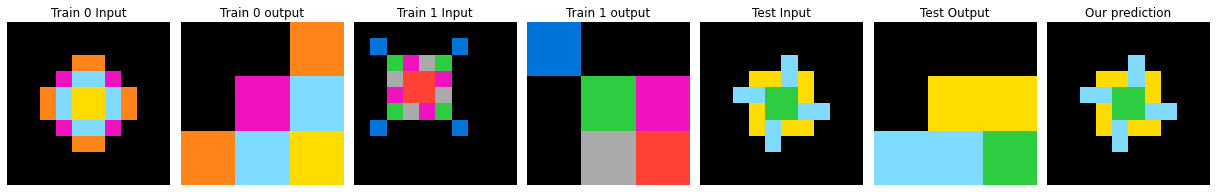

traininput_objects: [[4, 6, 4, 6, 2, 2, 4, 4, 4, 4, 4, 4, 1, 4], [3, 7, 3, 7, 4, 4, 8, 8, 8, 8, 4, 4, 3, 16], [4, 6, 7, 8, 2, 1, 7, 2, 7, 2, 7, 2, 1, 2], [7, 8, 4, 6, 1, 2, 7, 2, 7, 2, 7, 2, 1, 2], [4, 6, 2, 3, 2, 1, 7, 2, 7, 2, 7, 2, 1, 2], [2, 3, 4, 6, 1, 2, 7, 2, 7, 2, 7, 2, 1, 2], [6, 7, 3, 4, 1, 1, 6, 1, 6, 1, 6, 1, 1, 1], [3, 4, 6, 7, 1, 1, 6, 1, 6, 1, 6, 1, 1, 1], [6, 7, 6, 7, 1, 1, 6, 1, 6, 1, 6, 1, 1, 1], [3, 4, 3, 4, 1, 1, 6, 1, 6, 1, 6, 1, 1, 1]]
trainoutput_objects: [[2, 3, 0, 1, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [1, 2, 1, 2, 1, 1, 6, 1, 6, 1, 6, 1, 1, 1], [2, 3, 2, 3, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [0, 1, 2, 3, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [1, 3, 1, 3, 2, 2, 8, 2, 8, 2, 4, 1, 3, 4]]
is_out_obj_in_in_objs: [(False, -1), (True, 6), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (True, (5, 2)), (False, ()), (False, ()), (False, ())]
48
contraction:
[[0], [0], [0], [0], [0]] [[(5, 3)], [(15, 14)], [(5, 5)], [(4, 3)], [(3, 11)]]


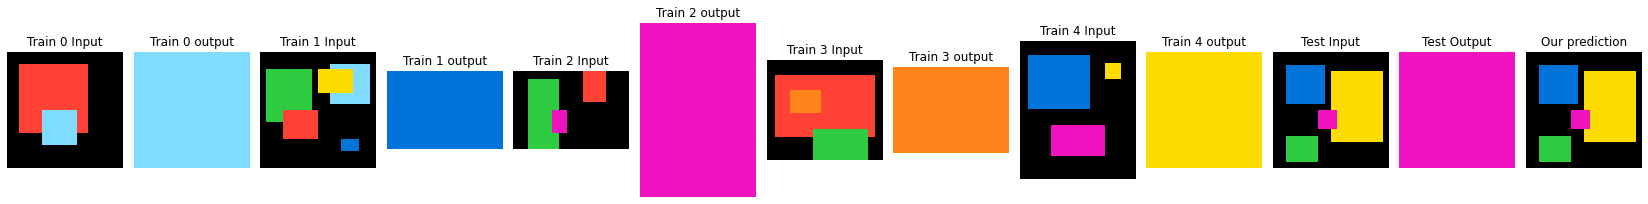

traininput_objects: [[5, 8, 3, 6, 3, 3, 8, 9, 8, 9, 8, 9, 1, 9], [0, 10, 0, 10, 10, 10, 0, 61, 0, 61, 8, 9, 3, 100], [1, 7, 1, 7, 6, 6, 2, 30, 2, 30, 8, 6, 2, 36]]
trainoutput_objects: [[0, 3, 0, 3, 3, 3, 8, 9, 8, 9, 8, 9, 1, 9]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (5, 3))]
64
contraction:
[[0], [0], [0]] [[(3, 0)], [(0, 4)], [(0, 0)]]


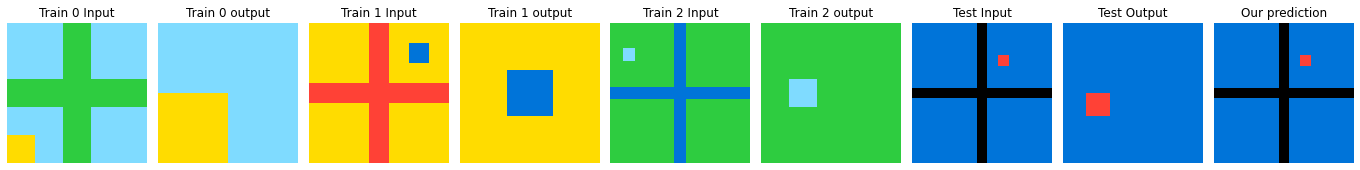

traininput_objects: [[0, 2, 3, 5, 2, 2, 8, 4, 8, 4, 8, 4, 1, 4], [3, 5, 3, 5, 2, 2, 8, 4, 8, 4, 8, 4, 1, 4], [0, 2, 0, 2, 2, 2, 8, 4, 8, 4, 8, 4, 1, 4], [4, 5, 0, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [3, 5, 0, 2, 2, 2, 8, 3, 8, 3, 4, 1, 2, 4], [0, 5, 0, 5, 5, 5, 3, 9, 8, 15, 4, 1, 3, 25]]
trainoutput_objects: [[1, 2, 0, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [0, 2, 0, 2, 2, 2, 8, 3, 8, 3, 4, 1, 2, 4]]
is_out_obj_in_in_objs: [(True, 3), (True, 4)]
overall_movement: [(True, (3, 0)), (True, (3, 0))]
66
contraction:
[[0, 3, 0], [0, 0, 0], [0, 7, 0, 7, 0]] [[(0, 0), (0, 3), (0, 6)], [(0, 0), (0, 4), (0, 8)], [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]]


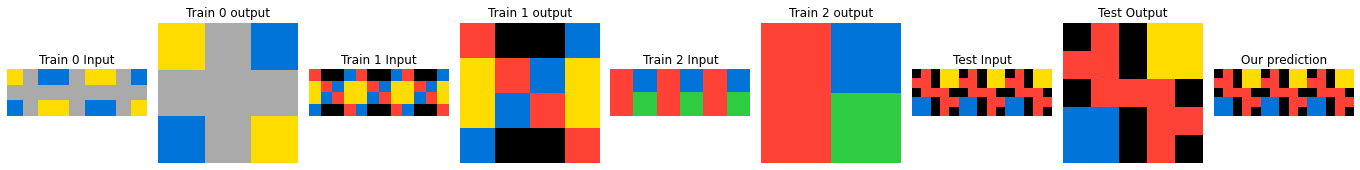

traininput_objects: [[0, 3, 0, 9, 3, 9, 5, 15, 5, 15, 1, 6, 3, 27], [2, 3, 5, 7, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [0, 1, 2, 4, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [0, 1, 5, 7, 1, 2, 4, 2, 4, 2, 4, 2, 1, 2], [2, 3, 2, 4, 1, 2, 4, 2, 4, 2, 4, 2, 1, 2], [0, 1, 0, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [2, 3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 1, 8, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [2, 3, 8, 9, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1]]
trainoutput_objects: [[0, 3, 0, 3, 3, 3, 5, 5, 5, 5, 1, 2, 3, 9], [0, 1, 0, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [2, 3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [2, 3, 2, 3, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [0, 1, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
is_out_obj_in_in_objs: [(False, -1), (True, 5), (True, 6), (True, 5), (True, 6)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (-2, -2)), (True, (2, -2))]
78
contraction:
[[0, 0, 0], [0, 0, 0, 0], [0, 0]] [[(1, 2), (2, 10), (7, 3)], [(1, 2), (3, 11), (8, 9), (10, 2)], [(2, 2), (8, 8)]]


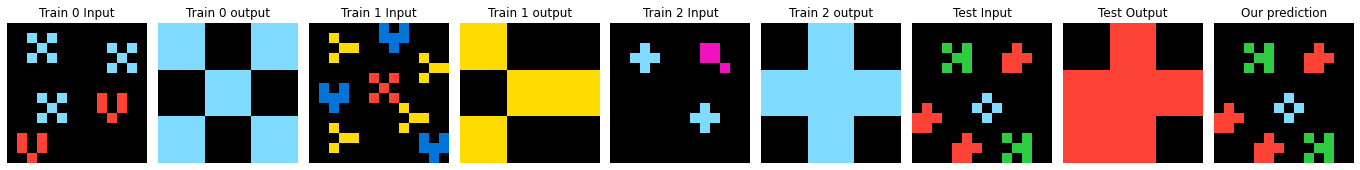

traininput_objects: [[1, 4, 2, 5, 3, 3, 8, 5, 8, 5, 8, 5, 1, 5], [7, 10, 3, 6, 3, 3, 8, 5, 8, 5, 8, 5, 1, 5], [11, 14, 1, 4, 3, 3, 2, 5, 2, 5, 2, 5, 1, 5], [2, 5, 10, 13, 3, 3, 8, 5, 8, 5, 8, 5, 1, 5], [7, 10, 9, 12, 3, 3, 2, 5, 2, 5, 2, 5, 1, 5]]
trainoutput_objects: [[0, 3, 0, 3, 3, 3, 8, 5, 8, 5, 8, 5, 1, 5]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (1, 2))]
82
expansion:
[[0, 4, 0, 4], [0, 7, 6, 4], [0, 7, 6, 4]] [[(0, 0), (0, 4), (3, 0), (3, 4)], [(0, 0), (0, 4), (3, 0), (3, 4)], [(0, 0), (0, 4), (3, 0), (3, 4)]]


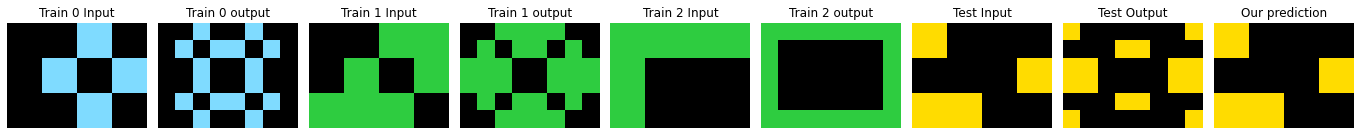

traininput_objects: [[0, 3, 1, 4, 3, 3, 8, 4, 8, 4, 8, 4, 1, 4]]
trainoutput_objects: [[0, 6, 1, 7, 6, 6, 8, 16, 8, 16, 8, 16, 1, 16]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
90
contraction:
[[0], [0], [0]] [[(1, 1)], [(3, 2)], [(2, 3)]]


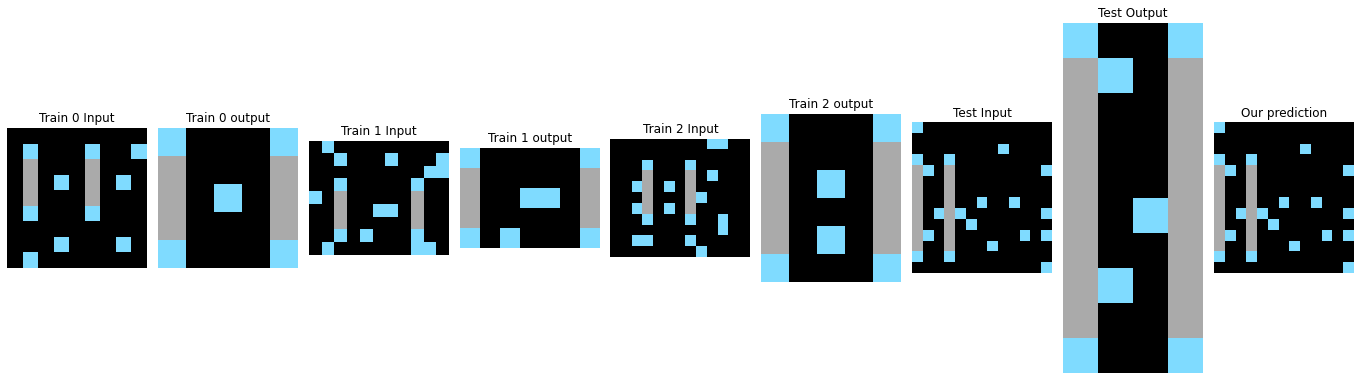

traininput_objects: [[2, 5, 5, 6, 3, 1, 5, 3, 5, 3, 5, 3, 1, 3], [2, 5, 1, 2, 3, 1, 5, 3, 5, 3, 5, 3, 1, 3], [5, 6, 1, 2, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [3, 4, 7, 8, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [1, 2, 1, 2, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [5, 6, 5, 6, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [3, 4, 3, 4, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [8, 9, 1, 2, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [7, 8, 3, 4, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [1, 2, 5, 6, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [7, 8, 7, 8, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [1, 2, 8, 9, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1]]
trainoutput_objects: [[1, 4, 4, 5, 3, 1, 5, 3, 5, 3, 5, 3, 1, 3], [1, 4, 0, 1, 3, 1, 5, 3, 5, 3, 5, 3, 1, 3], [4, 5, 0, 1, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [0, 1, 4, 5, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [2, 3, 2, 3, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [4, 5, 4, 5, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [0, 1, 0, 1, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1]]
is_out_obj_in_in_objs: [(True, 0), (True, 0), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2)]
overall_movement: [(

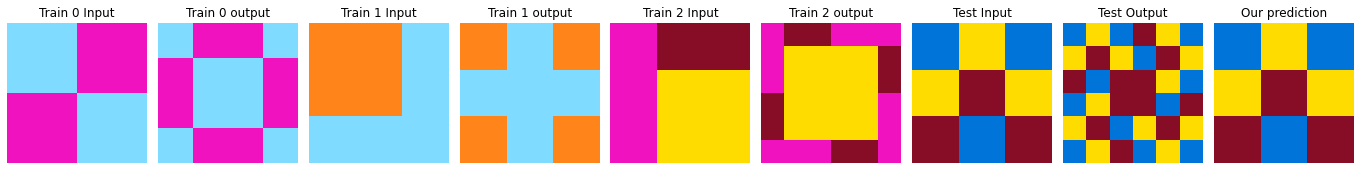

traininput_objects: [[0, 2, 0, 2, 2, 2, 8, 2, 6, 2, 6, 2, 2, 4], [0, 2, 0, 2, 2, 2, 6, 2, 6, 2, 6, 2, 2, 4]]
trainoutput_objects: [[0, 4, 0, 4, 4, 4, 6, 8, 6, 8, 6, 8, 2, 16], [0, 4, 0, 4, 4, 4, 8, 8, 6, 8, 6, 8, 2, 16]]
is_out_obj_in_in_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]
110
contraction:
[[0], [0], [0]] [[(3, 2)], [(2, 6)], [(5, 6)]]


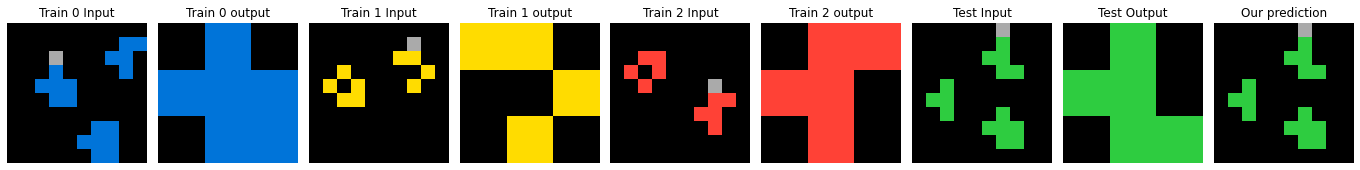

traininput_objects: [[7, 10, 5, 8, 3, 3, 1, 7, 1, 7, 1, 7, 1, 7], [3, 6, 2, 5, 3, 3, 1, 6, 1, 6, 1, 6, 1, 6], [1, 4, 7, 10, 3, 3, 1, 5, 1, 5, 1, 5, 1, 5], [2, 3, 3, 4, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1]]
trainoutput_objects: [[0, 3, 0, 3, 3, 3, 1, 6, 1, 6, 1, 6, 1, 6]]
is_out_obj_in_in_objs: [(True, 1)]
overall_movement: [(True, (3, 2))]
115
expansion:
[[6, 0], [6, 0], [6, 0], [6, 0]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]


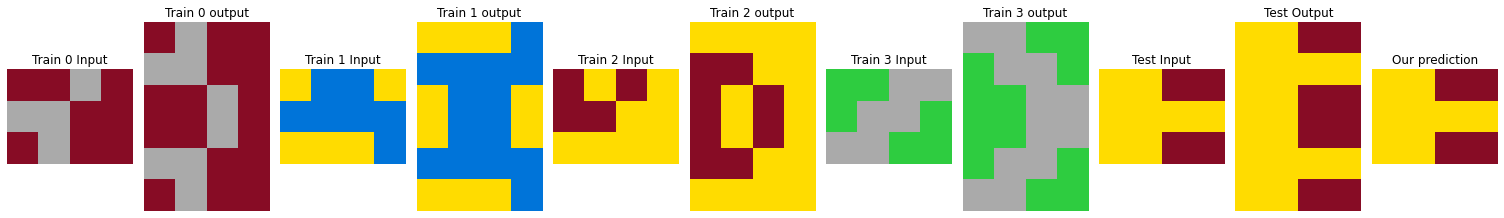

traininput_objects: [[0, 3, 0, 3, 3, 3, 5, 4, 9, 5, 5, 4, 2, 9], [0, 3, 0, 4, 3, 4, 9, 8, 9, 8, 5, 4, 2, 12], [2, 3, 0, 1, 1, 1, 9, 1, 9, 1, 9, 1, 1, 1]]
trainoutput_objects: [[0, 6, 0, 3, 6, 3, 5, 8, 9, 10, 5, 8, 2, 18], [0, 6, 0, 4, 6, 4, 9, 16, 9, 16, 5, 8, 2, 24], [5, 6, 0, 1, 1, 1, 9, 1, 9, 1, 9, 1, 1, 1], [0, 1, 0, 1, 1, 1, 9, 1, 9, 1, 9, 1, 1, 1]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 2), (True, 2)]
overall_movement: [(False, ()), (False, ()), (True, (-3, 0)), (True, (2, 0))]
134
contraction:
[[0], [0], [0], [0]] [[(0, 6)], [(0, 6)], [(0, 6)], [(0, 6)]]


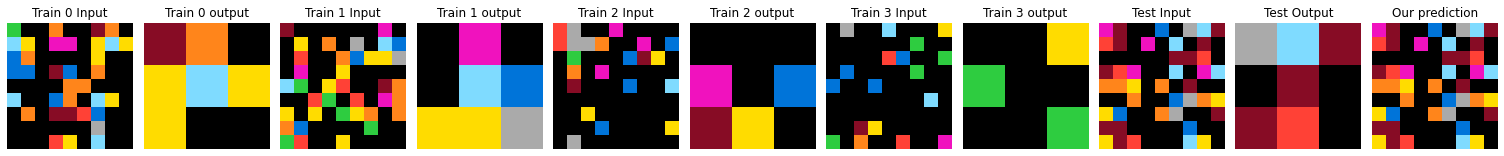

traininput_objects: [[1, 2, 3, 5, 1, 2, 6, 2, 6, 2, 6, 2, 1, 2], [1, 3, 6, 7, 2, 1, 4, 2, 4, 2, 4, 2, 1, 2], [6, 7, 3, 5, 1, 2, 9, 2, 9, 2, 9, 2, 1, 2], [5, 6, 6, 7, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [8, 9, 3, 4, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [7, 8, 6, 7, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1], [5, 6, 0, 1, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [3, 4, 4, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [6, 7, 6, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [5, 6, 7, 8, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [1, 2, 7, 8, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [8, 9, 6, 7, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [0, 1, 7, 8, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [6, 7, 1, 2, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [1, 2, 8, 9, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [3, 4, 3, 4, 1, 1, 9, 1, 9, 1, 9, 1, 1, 1], [1, 2, 1, 2, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [5, 6, 3, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [8, 9, 4, 5, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [1, 2, 0, 1, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [6, 7, 5, 6, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [0, 1, 6, 7, 1, 1, 9, 1, 9, 1, 9, 1, 1, 1], [0, 1, 3, 4

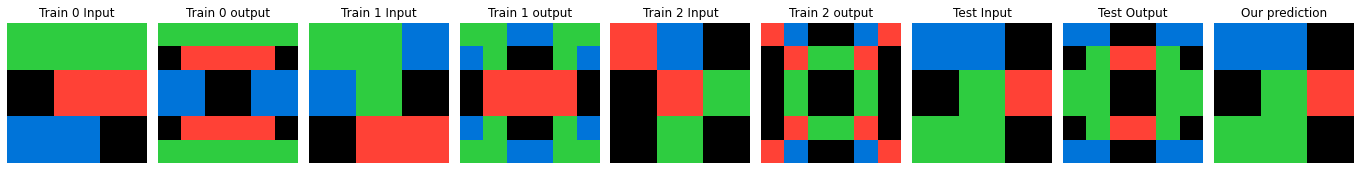

traininput_objects: [[0, 1, 0, 3, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3], [2, 3, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [1, 2, 1, 3, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2]]
trainoutput_objects: [[0, 1, 0, 6, 1, 6, 3, 6, 3, 6, 3, 6, 1, 6], [5, 6, 0, 6, 1, 6, 3, 6, 3, 6, 3, 6, 1, 6], [1, 2, 1, 5, 1, 4, 2, 4, 2, 4, 2, 4, 1, 4], [2, 4, 4, 6, 2, 2, 1, 4, 1, 4, 1, 4, 1, 4], [4, 5, 1, 5, 1, 4, 2, 4, 2, 4, 2, 4, 1, 4], [2, 4, 0, 2, 2, 2, 1, 4, 1, 4, 1, 4, 1, 4]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]
145
contraction:
[[0], [0], [0], [0]] [[(6, 0)], [(3, 0)], [(6, 0)], [(0, 0)]]


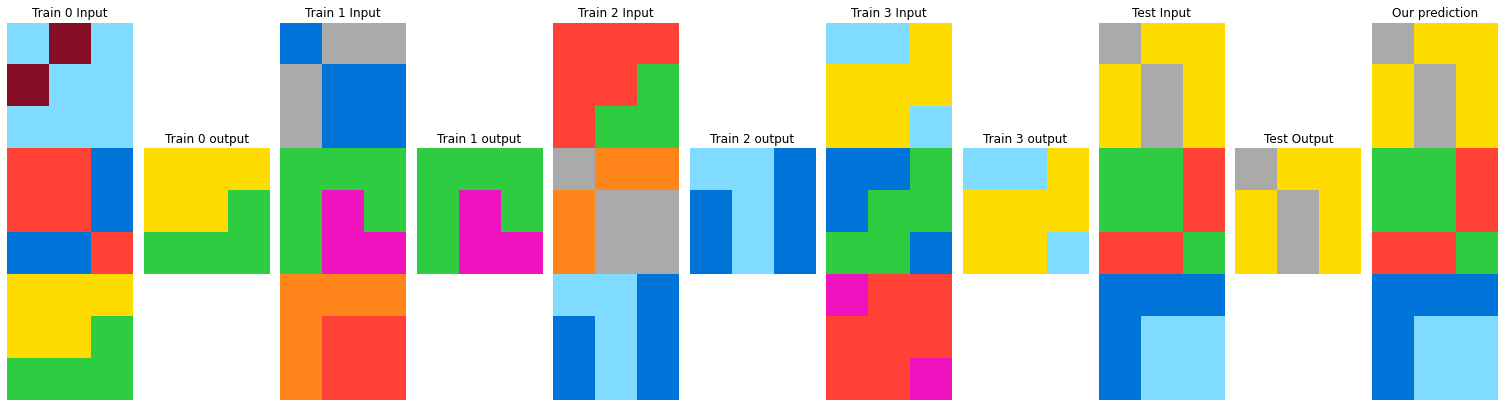

traininput_objects: [[3, 6, 0, 3, 3, 3, 2, 5, 2, 5, 1, 4, 2, 9], [3, 6, 0, 3, 3, 3, 1, 4, 2, 5, 1, 4, 2, 9], [0, 2, 0, 2, 2, 2, 9, 2, 8, 2, 8, 2, 2, 4], [7, 9, 0, 3, 2, 3, 3, 4, 3, 4, 4, 2, 2, 6], [0, 3, 0, 3, 3, 3, 8, 7, 8, 7, 9, 2, 2, 9], [6, 8, 0, 3, 2, 3, 4, 5, 4, 5, 3, 1, 2, 6]]
trainoutput_objects: [[1, 3, 0, 3, 2, 3, 3, 4, 3, 4, 4, 2, 2, 6], [0, 2, 0, 3, 2, 3, 4, 5, 4, 5, 3, 1, 2, 6]]
is_out_obj_in_in_objs: [(True, 3), (True, 5)]
overall_movement: [(True, (6, 0)), (True, (6, 0))]
151
expansion:
[[0, 7, 6, 4], [0, 7, 6, 4], [0, 7, 6, 4], [0, 7, 6, 4]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]


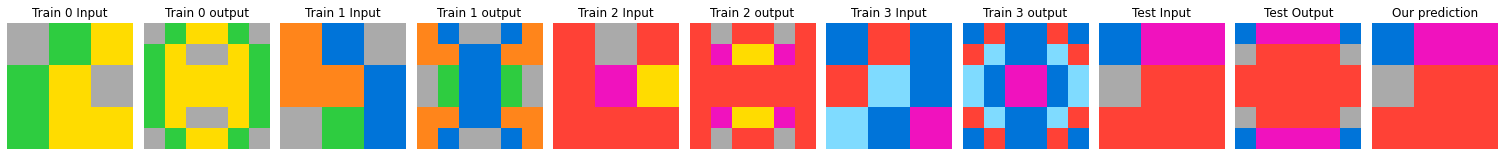

traininput_objects: [[0, 1, 0, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1], [1, 2, 2, 3, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1], [0, 3, 1, 3, 3, 2, 4, 4, 4, 4, 3, 1, 3, 6], [0, 3, 0, 2, 3, 2, 3, 3, 3, 3, 5, 1, 3, 6]]
trainoutput_objects: [[0, 6, 1, 5, 6, 4, 4, 16, 4, 16, 3, 4, 3, 24], [4, 5, 2, 4, 1, 2, 5, 2, 5, 2, 5, 2, 1, 2], [1, 2, 2, 4, 1, 2, 5, 2, 5, 2, 5, 2, 1, 2], [0, 6, 4, 6, 6, 2, 3, 6, 3, 6, 5, 2, 3, 12], [0, 6, 0, 2, 6, 2, 3, 6, 3, 6, 5, 2, 3, 12], [5, 6, 5, 6, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1], [0, 1, 0, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1], [0, 1, 5, 6, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1], [5, 6, 0, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (True, (-5, -5)), (False, ()), (True, (0, -5)), (True, (-5, 0))]
163
expansion:
[[0, 7], [0, 7], [0, 7], [0, 7]] [[(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 

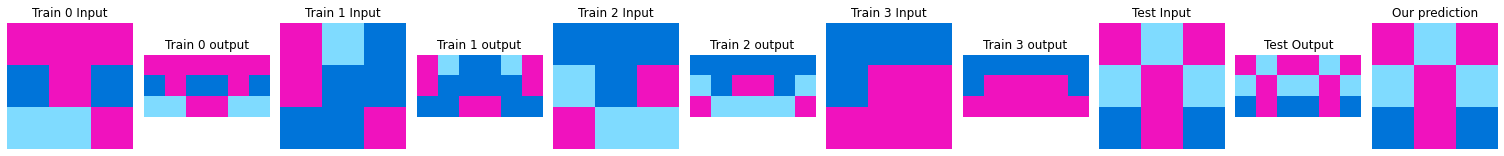

traininput_objects: [[2, 3, 0, 2, 1, 2, 8, 2, 8, 2, 8, 2, 1, 2], [0, 3, 0, 3, 3, 3, 6, 5, 6, 5, 1, 2, 3, 9], [1, 2, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
trainoutput_objects: [[0, 3, 0, 6, 3, 6, 6, 10, 6, 10, 1, 4, 3, 18], [1, 2, 2, 4, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [2, 3, 0, 2, 1, 2, 8, 2, 8, 2, 8, 2, 1, 2], [2, 3, 4, 6, 1, 2, 8, 2, 8, 2, 8, 2, 1, 2], [1, 2, 5, 6, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 0), (True, 0), (True, 2), (True, 2)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (0, -4)), (True, (0, -3)), (True, (0, 2))]
171
expansion:
[[0, 6], [0, 4], [0, 6], [0, 6]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]


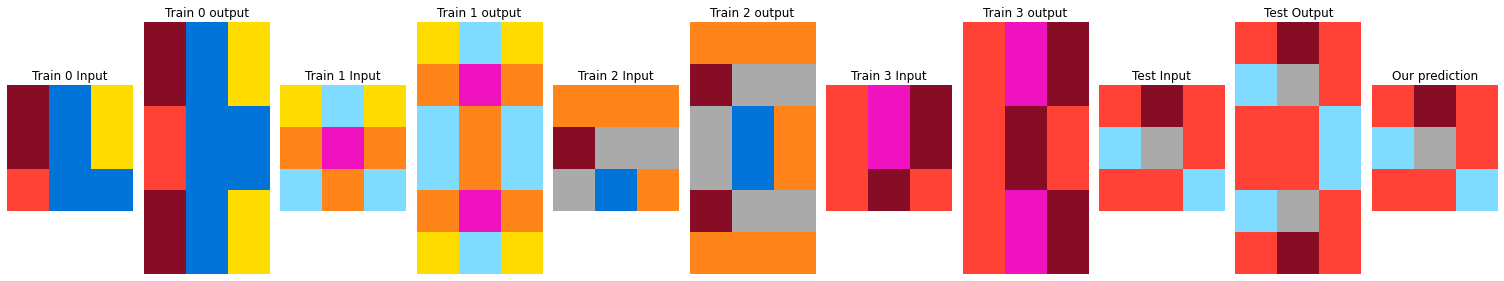

traininput_objects: [[0, 2, 0, 1, 2, 1, 9, 2, 9, 2, 9, 2, 1, 2], [0, 2, 2, 3, 2, 1, 4, 2, 4, 2, 4, 2, 1, 2], [0, 3, 1, 3, 3, 2, 1, 4, 1, 4, 4, 2, 2, 6], [2, 3, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
trainoutput_objects: [[0, 6, 1, 3, 6, 2, 1, 8, 1, 8, 4, 4, 2, 12], [0, 2, 0, 1, 2, 1, 9, 2, 9, 2, 9, 2, 1, 2], [2, 4, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [4, 6, 0, 1, 2, 1, 9, 2, 9, 2, 9, 2, 1, 2], [0, 2, 2, 3, 2, 1, 4, 2, 4, 2, 4, 2, 1, 2], [4, 6, 2, 3, 2, 1, 4, 2, 4, 2, 4, 2, 1, 2]]
is_out_obj_in_in_objs: [(False, -1), (True, 0), (False, -1), (True, 0), (True, 1), (True, 1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (-4, 0)), (False, ()), (True, (-4, 0))]
173
contraction:
[[0], [0], [0]] [[(6, 3)], [(1, 2)], [(2, 5)]]


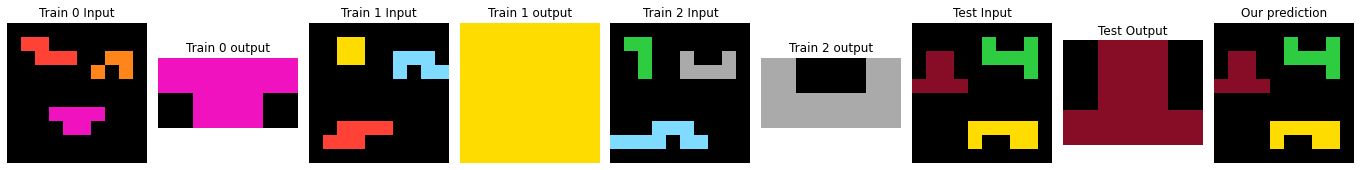

traininput_objects: [[6, 8, 3, 7, 2, 4, 6, 6, 6, 6, 6, 6, 1, 6], [1, 3, 1, 5, 2, 4, 2, 5, 2, 5, 2, 5, 1, 5], [2, 4, 6, 9, 2, 3, 7, 4, 7, 4, 7, 4, 1, 4]]
trainoutput_objects: [[0, 2, 0, 4, 2, 4, 6, 6, 6, 6, 6, 6, 1, 6]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (6, 3))]
176
contraction:
[[7], [7], [7]] [[(5, 2)], [(1, 3)], [(7, 2)]]


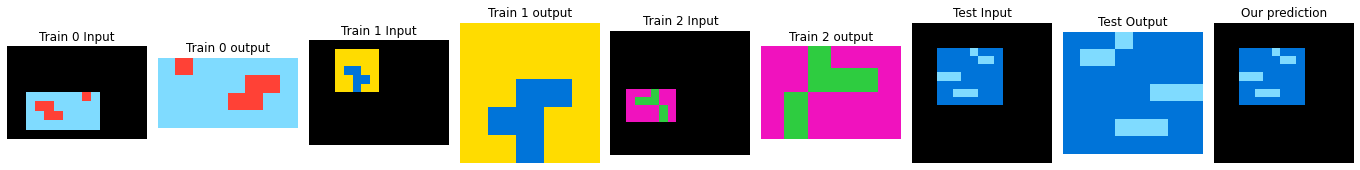

traininput_objects: [[5, 9, 2, 10, 4, 8, 8, 27, 8, 27, 2, 5, 2, 32], [6, 8, 3, 6, 2, 3, 2, 4, 2, 4, 8, 2, 2, 6], [5, 6, 8, 9, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
trainoutput_objects: [[0, 4, 0, 8, 4, 8, 8, 27, 8, 27, 2, 5, 2, 32], [1, 3, 4, 7, 2, 3, 2, 4, 2, 4, 8, 2, 2, 6], [0, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
is_out_obj_in_in_objs: [(True, 0), (True, 1), (True, 2)]
overall_movement: [(True, (5, 2)), (True, (5, -1)), (True, (5, 7))]
177
contraction:
[[0, 0, 0], [0, 0, 0], [], [0, 0], []] [[(0, 0), (0, 1), (0, 2)], [(0, 0), (1, 0), (2, 0)], [], [(0, 0), (0, 1)], []]


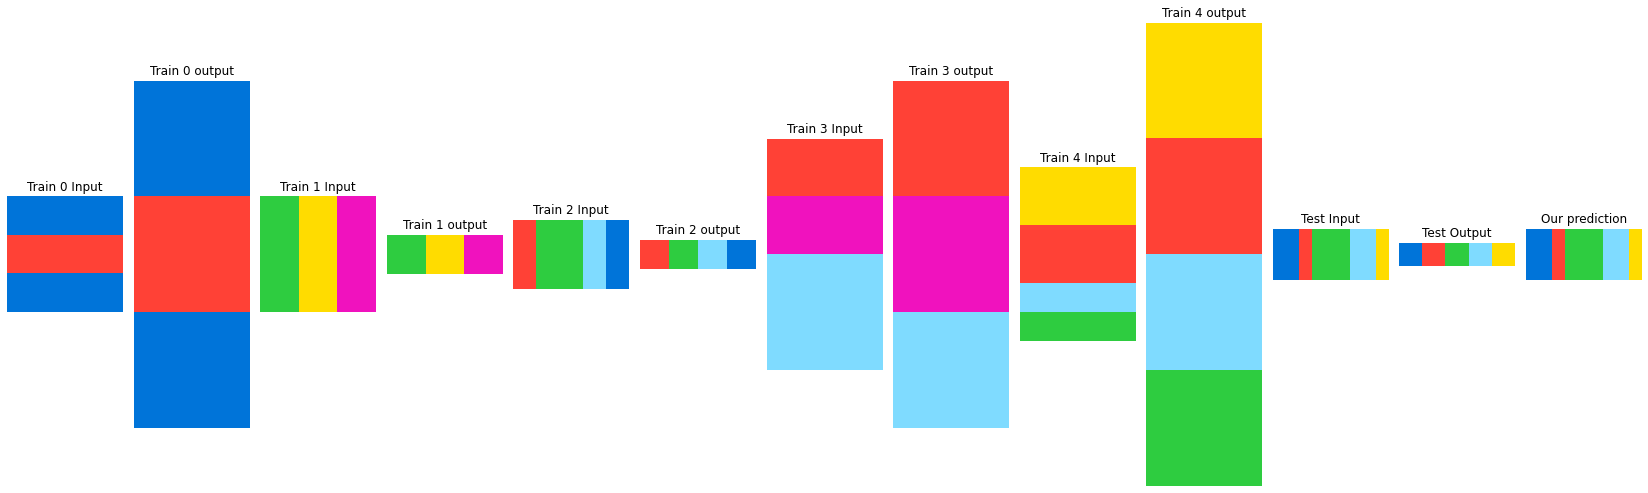

traininput_objects: [[0, 1, 0, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3], [1, 2, 0, 3, 1, 3, 2, 3, 2, 3, 2, 3, 1, 3], [2, 3, 0, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3]]
trainoutput_objects: [[1, 2, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [2, 3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ())]
187
contraction:
[[0, 0], [0, 0], [0, 4, 0]] [[(0, 0), (0, 4)], [(0, 0), (0, 3)], [(0, 0), (2, 0), (3, 0)]]


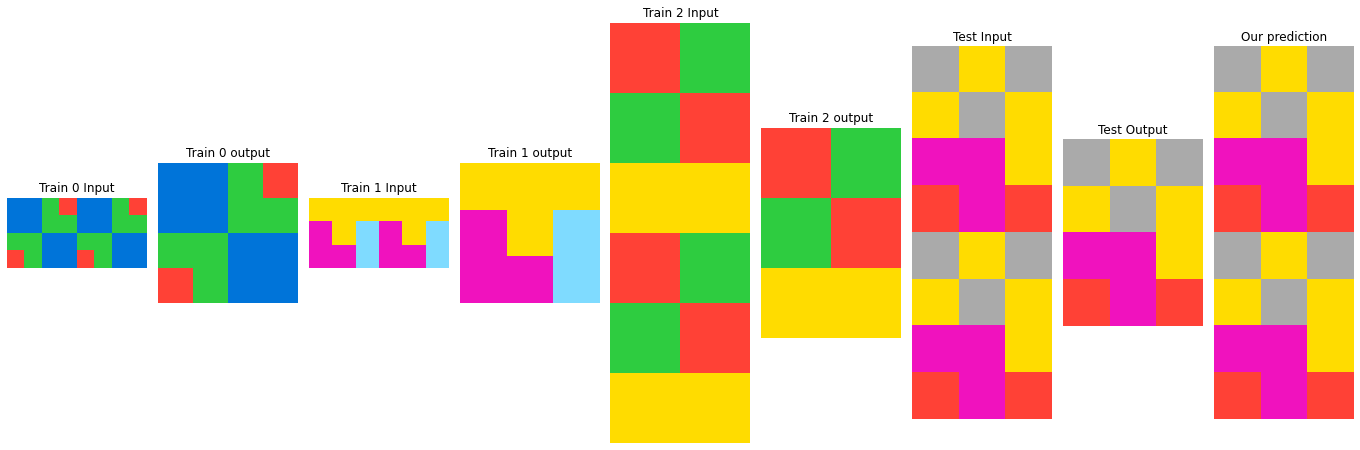

traininput_objects: [[0, 4, 0, 8, 4, 8, 3, 12, 1, 16, 2, 4, 3, 32], [0, 4, 0, 8, 4, 8, 1, 16, 1, 16, 2, 4, 3, 32], [0, 1, 7, 8, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [3, 4, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [0, 1, 3, 4, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [3, 4, 4, 5, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
trainoutput_objects: [[0, 4, 0, 4, 4, 4, 3, 6, 1, 8, 2, 2, 3, 16], [0, 4, 0, 4, 4, 4, 1, 8, 1, 8, 2, 2, 3, 16], [0, 1, 3, 4, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [3, 4, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 2), (True, 2)]
overall_movement: [(False, ()), (False, ()), (True, (0, 4)), (True, (-3, 7))]
193
expansion:
[[0, 5, 3, 4], [0, 5, 3, 4], [0, 1, 1, 0]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]


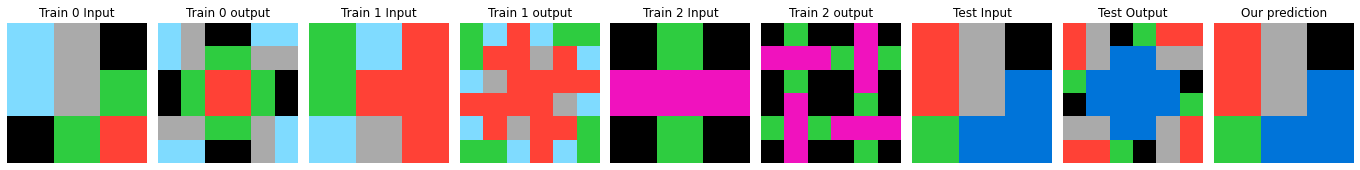

traininput_objects: [[0, 2, 0, 1, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [0, 2, 1, 2, 2, 1, 5, 2, 5, 2, 5, 2, 1, 2], [2, 3, 2, 3, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [1, 3, 1, 3, 2, 2, 3, 2, 3, 2, 2, 1, 3, 4]]
trainoutput_objects: [[2, 4, 2, 4, 2, 2, 2, 4, 2, 4, 2, 4, 1, 4], [1, 5, 1, 5, 4, 4, 3, 8, 3, 8, 2, 4, 3, 16], [4, 6, 4, 5, 2, 1, 5, 2, 5, 2, 5, 2, 1, 2], [5, 6, 0, 2, 1, 2, 8, 2, 8, 2, 8, 2, 1, 2], [1, 2, 4, 6, 1, 2, 5, 2, 5, 2, 5, 2, 1, 2], [0, 2, 0, 1, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [0, 2, 1, 2, 2, 1, 5, 2, 5, 2, 5, 2, 1, 2], [4, 6, 5, 6, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [0, 1, 4, 6, 1, 2, 8, 2, 8, 2, 8, 2, 1, 2], [4, 5, 0, 2, 1, 2, 5, 2, 5, 2, 5, 2, 1, 2]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 1), (False, -1), (False, -1), (True, 0), (True, 1), (True, 0), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (True, (-4, -3)), (False, ()), (False, ()), (False, ()), (False, ()), (True, (-4, -5)), (False, ()), (False, ())]
206
contraction:
[[2, 2, 2, 0], [0]

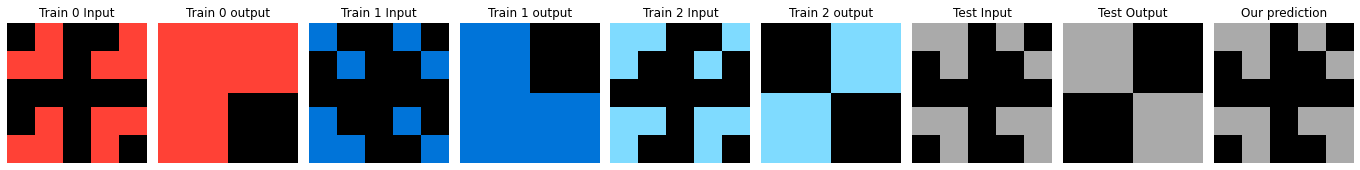

traininput_objects: [[0, 2, 3, 5, 2, 2, 2, 3, 2, 3, 2, 3, 1, 3], [0, 2, 0, 2, 2, 2, 2, 3, 2, 3, 2, 3, 1, 3], [3, 5, 0, 2, 2, 2, 2, 3, 2, 3, 2, 3, 1, 3], [3, 5, 3, 5, 2, 2, 2, 3, 2, 3, 2, 3, 1, 3]]
trainoutput_objects: [[0, 2, 0, 2, 2, 2, 2, 3, 2, 3, 2, 3, 1, 3]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (0, 3))]
209
expansion:
[[0, 6], [0, 6], [0, 6]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]


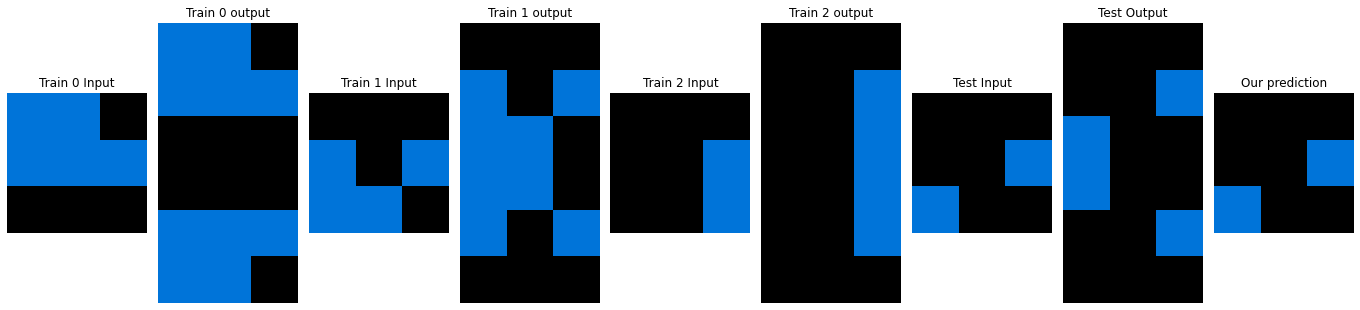

traininput_objects: [[0, 2, 0, 3, 2, 3, 1, 5, 1, 5, 1, 5, 1, 5]]
trainoutput_objects: [[0, 2, 0, 3, 2, 3, 1, 5, 1, 5, 1, 5, 1, 5], [4, 6, 0, 3, 2, 3, 1, 5, 1, 5, 1, 5, 1, 5]]
is_out_obj_in_in_objs: [(True, 0), (True, 0)]
overall_movement: [(False, ()), (True, (-4, 0))]
210
expansion:
[[4, 0, 4, 0, 4, 0], [4, 0, 4, 0, 4, 0], [4, 6, 7, 0, 4, 6]] [[(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)], [(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)], [(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)]]


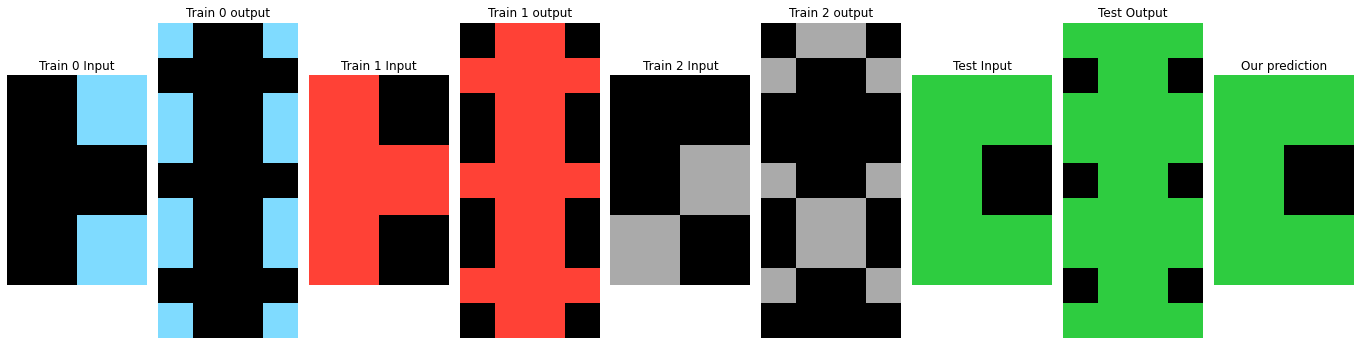

traininput_objects: [[2, 3, 1, 2, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [0, 1, 1, 2, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1]]
trainoutput_objects: [[2, 4, 3, 4, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [5, 7, 3, 4, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [2, 4, 0, 1, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [5, 7, 0, 1, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [8, 9, 3, 4, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [8, 9, 0, 1, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [0, 1, 3, 4, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [0, 1, 0, 1, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (True, 0), (True, 0), (True, 0), (True, 0)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (True, (-6, -2)), (True, (-6, 1)), (True, (2, -2)), (True, (2, 1))]
215
contraction:
[[0], [0], [0]] [[(13, 6)], [(2, 2)], [(15, 2)]]


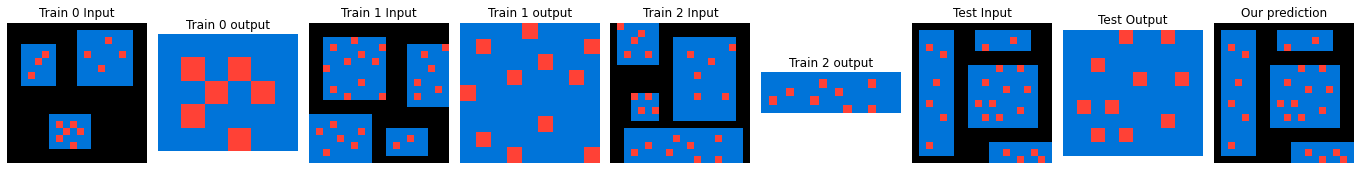

traininput_objects: [[0, 20, 0, 20, 20, 20, 0, 276, 0, 276, 2, 13, 3, 400], [13, 18, 6, 12, 5, 6, 1, 24, 1, 24, 2, 6, 2, 30], [14, 17, 7, 11, 3, 4, 2, 5, 1, 7, 2, 5, 2, 12], [1, 9, 10, 18, 8, 8, 1, 60, 1, 60, 2, 4, 2, 64], [3, 9, 2, 7, 6, 5, 1, 27, 1, 27, 2, 3, 2, 30], [4, 6, 4, 6, 2, 2, 2, 2, 1, 2, 1, 2, 2, 4], [17, 18, 9, 10, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [2, 3, 14, 15, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [4, 5, 11, 12, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [4, 5, 16, 17, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [6, 7, 13, 14, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [7, 8, 3, 4, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
trainoutput_objects: [[0, 5, 0, 6, 5, 6, 1, 24, 1, 24, 2, 6, 2, 30], [1, 4, 1, 5, 3, 4, 2, 5, 1, 7, 2, 5, 2, 12], [4, 5, 3, 4, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
is_out_obj_in_in_objs: [(True, 1), (True, 2), (True, 6)]
overall_movement: [(True, (13, 6)), (True, (13, 6)), (True, (13, 6))]
220
expansion:
[[0, 0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 6, 6, 6, 0, 0, 0], [0, 0, 0]] [[(0, 0), (0, 3), (0, 6), (0, 9), (3, 0

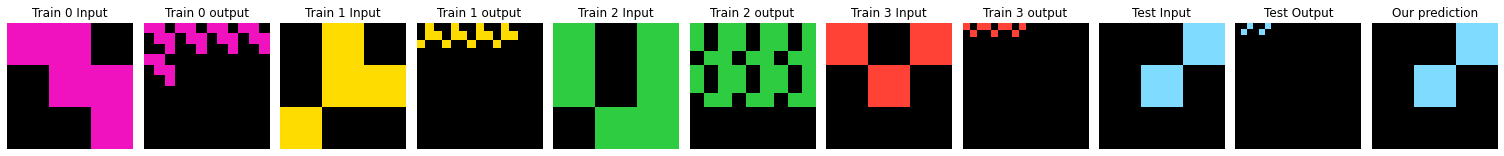

traininput_objects: [[0, 3, 0, 3, 3, 3, 6, 5, 6, 5, 6, 5, 1, 5]]
trainoutput_objects: [[0, 6, 0, 12, 6, 12, 6, 25, 6, 25, 6, 25, 1, 25]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
230
expansion:
[[0, 7, 0, 7, 0, 7, 0], [0, 0, 0], [0, 0, 0]] [[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6)], [(0, 0), (0, 3), (0, 6)], [(0, 0), (0, 3), (0, 6)]]


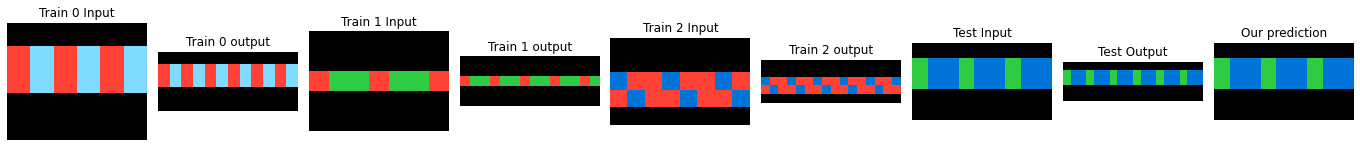

traininput_objects: [[1, 3, 4, 5, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 5, 6, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [1, 3, 1, 2, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [1, 3, 2, 3, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 3, 4, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2]]
trainoutput_objects: [[1, 3, 8, 9, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 4, 5, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 10, 11, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 5, 6, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [1, 3, 7, 8, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [1, 3, 1, 2, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [1, 3, 9, 10, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [1, 3, 11, 12, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2], [1, 3, 2, 3, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 6, 7, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [1, 3, 3, 4, 2, 1, 8, 2, 8, 2, 8, 2, 1, 2]]
is_out_obj_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 0), (True, 0), (True, 2)]
over

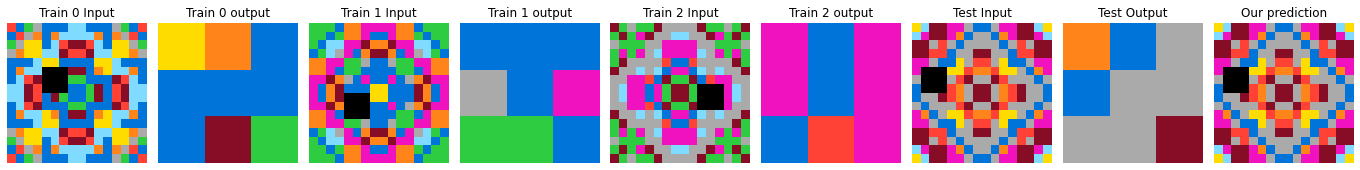

traininput_objects: [[5, 8, 4, 7, 3, 3, 0, 9, 0, 9, 0, 9, 1, 9], [0, 16, 0, 16, 16, 16, 8, 48, 1, 75, 0, 9, 9, 256], [6, 10, 2, 4, 4, 2, 2, 4, 2, 4, 2, 4, 2, 8], [6, 10, 12, 14, 4, 2, 2, 4, 2, 4, 2, 4, 2, 8], [2, 4, 6, 10, 2, 4, 9, 4, 2, 4, 2, 4, 2, 8], [6, 10, 2, 4, 4, 2, 9, 4, 2, 4, 2, 4, 2, 8], [12, 14, 6, 10, 2, 4, 9, 4, 2, 4, 2, 4, 2, 8], [6, 10, 12, 14, 4, 2, 9, 4, 2, 4, 2, 4, 2, 8], [2, 4, 6, 10, 2, 4, 2, 4, 2, 4, 2, 4, 2, 8], [12, 14, 6, 10, 2, 4, 2, 4, 2, 4, 2, 4, 2, 8], [4, 12, 4, 12, 8, 8, 1, 27, 1, 27, 7, 3, 6, 64], [10, 11, 7, 9, 1, 2, 9, 2, 9, 2, 9, 2, 1, 2], [7, 9, 10, 11, 2, 1, 9, 2, 9, 2, 9, 2, 1, 2], [5, 6, 7, 9, 1, 2, 9, 2, 9, 2, 9, 2, 1, 2], [0, 2, 14, 16, 2, 2, 2, 2, 1, 2, 1, 2, 2, 4], [14, 16, 14, 16, 2, 2, 1, 2, 1, 2, 1, 2, 2, 4], [14, 16, 14, 16, 2, 2, 2, 2, 1, 2, 1, 2, 2, 4], [14, 16, 0, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 4], [0, 2, 14, 16, 2, 2, 1, 2, 1, 2, 1, 2, 2, 4], [14, 16, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 4], [0, 2, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 4], [0, 2,

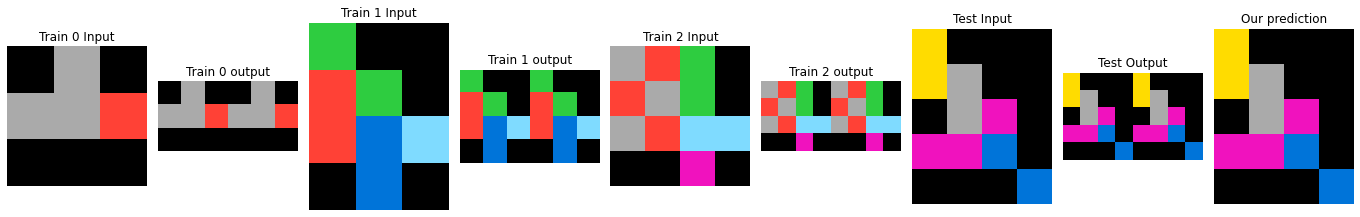

traininput_objects: [[0, 2, 0, 2, 2, 2, 5, 3, 5, 3, 5, 3, 1, 3], [1, 2, 2, 3, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
trainoutput_objects: [[0, 2, 0, 2, 2, 2, 5, 3, 5, 3, 5, 3, 1, 3], [0, 2, 3, 5, 2, 2, 5, 3, 5, 3, 5, 3, 1, 3], [1, 2, 5, 6, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [1, 2, 2, 3, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
is_out_obj_in_in_objs: [(True, 0), (True, 0), (True, 1), (True, 1)]
overall_movement: [(False, ()), (True, (0, -3)), (True, (0, -3)), (False, ())]
262
contraction:
[[0], [0], [0], [0]] [[(6, 0)], [(0, 6)], [(0, 3)], [(0, 0)]]


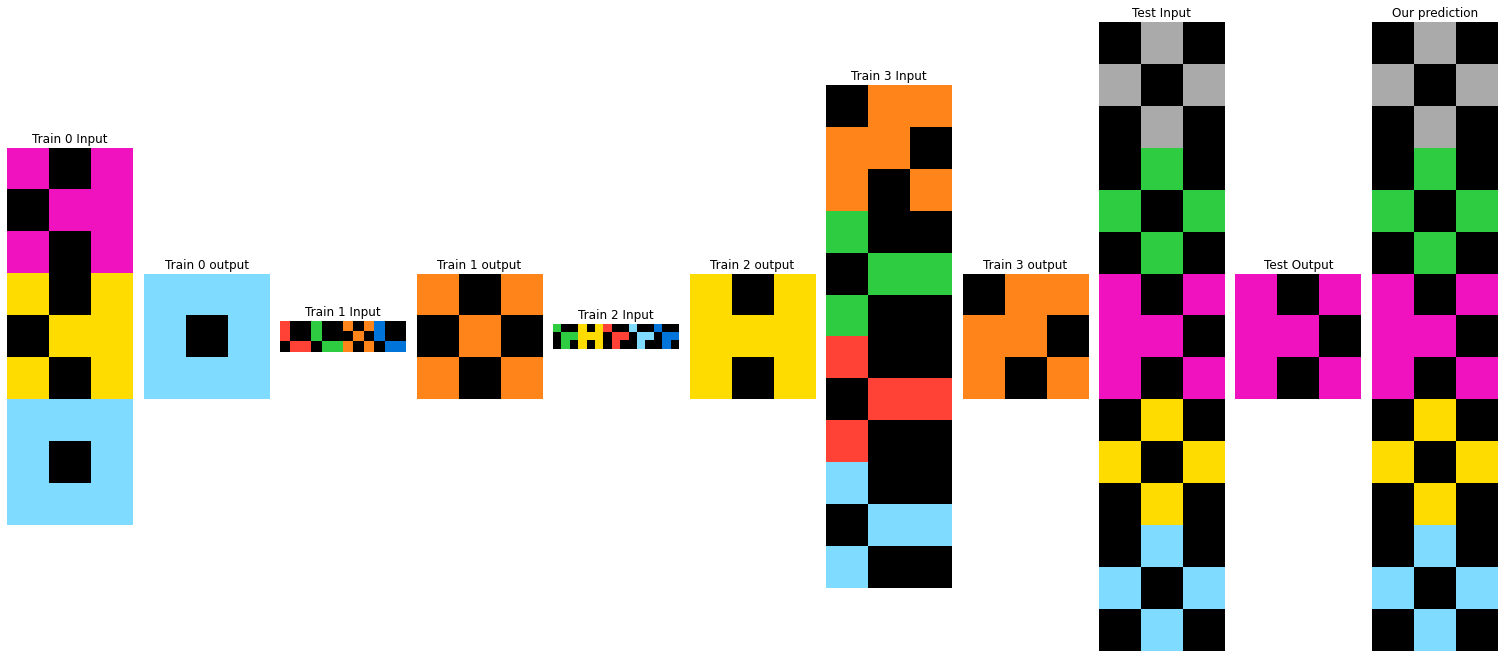

traininput_objects: [[3, 6, 0, 3, 3, 3, 4, 6, 4, 6, 0, 3, 2, 9], [0, 3, 0, 3, 3, 3, 6, 6, 6, 6, 0, 3, 2, 9], [0, 6, 0, 2, 6, 2, 0, 6, 0, 6, 4, 3, 3, 12], [7, 8, 1, 2, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1], [6, 9, 0, 3, 3, 3, 8, 8, 8, 8, 0, 1, 2, 9]]
trainoutput_objects: [[1, 2, 1, 2, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1], [0, 3, 0, 3, 3, 3, 8, 8, 8, 8, 0, 1, 2, 9]]
is_out_obj_in_in_objs: [(True, 3), (True, 4)]
overall_movement: [(True, (6, 0)), (True, (6, 0))]
270
contraction:
[[0], [0], [0], [0]] [[(5, 6)], [(4, 2)], [(4, 6)], [(1, 6)]]


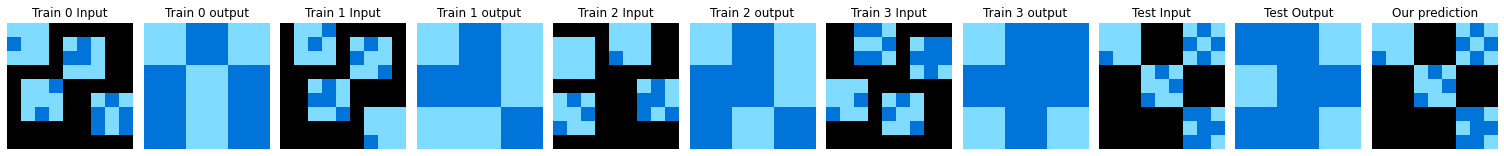

traininput_objects: [[5, 8, 6, 9, 3, 3, 1, 5, 1, 5, 8, 4, 2, 9], [5, 8, 6, 9, 3, 3, 8, 4, 1, 5, 8, 4, 2, 9], [1, 4, 4, 7, 3, 3, 8, 6, 8, 6, 1, 3, 2, 9], [4, 7, 1, 4, 3, 3, 8, 7, 8, 7, 1, 2, 2, 9], [1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [6, 7, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 2, 4, 5, 1, 1, 8, 1, 8, 1, 8, 1, 1, 1], [4, 5, 3, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 3, 4, 6, 2, 2, 1, 3, 1, 3, 8, 1, 2, 4], [0, 3, 0, 3, 3, 3, 8, 8, 8, 8, 1, 1, 2, 9]]
trainoutput_objects: [[0, 3, 0, 3, 3, 3, 1, 5, 1, 5, 8, 4, 2, 9], [0, 3, 0, 3, 3, 3, 8, 4, 1, 5, 8, 4, 2, 9]]
is_out_obj_in_in_objs: [(True, 0), (True, 1)]
overall_movement: [(True, (5, 6)), (True, (5, 6))]
299
contraction:
[[0], [0], [0], [0]] [[(1, 1)], [(1, 4)], [(1, 1)], [(1, 6)]]


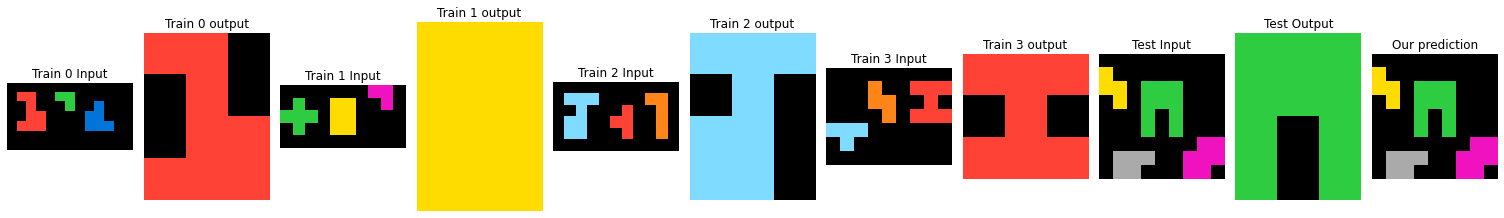

traininput_objects: [[1, 5, 1, 4, 4, 3, 2, 8, 2, 8, 2, 8, 1, 8], [2, 5, 8, 11, 3, 3, 1, 6, 1, 6, 1, 6, 1, 6], [1, 3, 5, 7, 2, 2, 3, 3, 3, 3, 3, 3, 1, 3]]
trainoutput_objects: [[0, 4, 0, 3, 4, 3, 2, 8, 2, 8, 2, 8, 1, 8]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (1, 1))]
303
expansion:
[[0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0]] [[(0, 0), (3, 3), (6, 6)], [(0, 0), (0, 6), (3, 6), (6, 0), (6, 3), (6, 6)], [(0, 3), (0, 6), (6, 0), (6, 3)]]


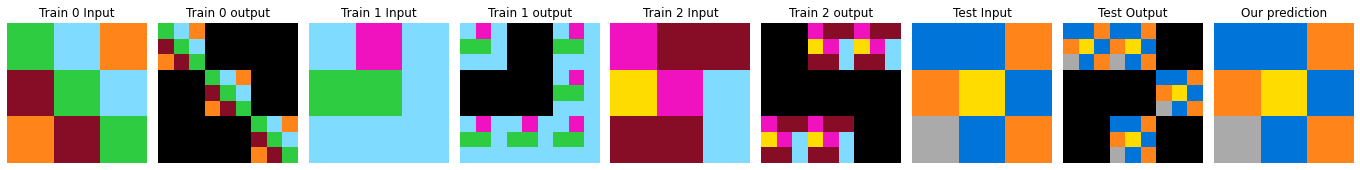

traininput_objects: [[0, 3, 0, 3, 3, 3, 3, 3, 3, 3, 7, 2, 4, 9], [2, 3, 0, 1, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [0, 1, 2, 3, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [1, 3, 0, 2, 2, 2, 9, 2, 9, 2, 3, 1, 3, 4], [0, 2, 1, 3, 2, 2, 8, 2, 8, 2, 3, 1, 3, 4]]
trainoutput_objects: [[0, 9, 0, 9, 9, 9, 0, 54, 0, 54, 7, 6, 5, 81], [0, 9, 0, 9, 9, 9, 3, 9, 0, 54, 7, 6, 5, 81], [0, 1, 2, 3, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [6, 7, 8, 9, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [3, 4, 5, 6, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [2, 3, 0, 1, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [5, 6, 3, 4, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [8, 9, 6, 7, 1, 1, 7, 1, 7, 1, 7, 1, 1, 1], [1, 3, 0, 2, 2, 2, 9, 2, 9, 2, 3, 1, 3, 4], [6, 8, 7, 9, 2, 2, 8, 2, 8, 2, 3, 1, 3, 4], [7, 9, 6, 8, 2, 2, 9, 2, 9, 2, 3, 1, 3, 4], [4, 6, 3, 5, 2, 2, 9, 2, 9, 2, 3, 1, 3, 4], [3, 5, 4, 6, 2, 2, 8, 2, 8, 2, 3, 1, 3, 4], [0, 2, 1, 3, 2, 2, 8, 2, 8, 2, 3, 1, 3, 4]]
is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), (True, 1), 

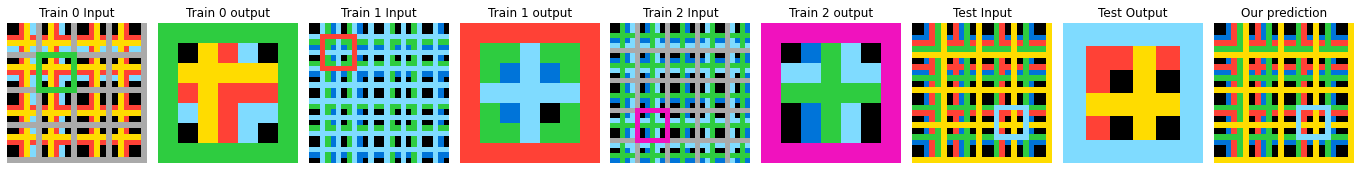

traininput_objects: [[0, 24, 0, 24, 24, 24, 5, 152, 5, 152, 3, 24, 6, 576], [18, 23, 12, 17, 5, 5, 4, 9, 0, 9, 2, 7, 3, 25], [12, 17, 12, 17, 5, 5, 4, 9, 0, 9, 2, 7, 3, 25], [18, 23, 18, 23, 5, 5, 4, 9, 0, 9, 2, 7, 3, 25], [12, 17, 18, 23, 5, 5, 4, 9, 0, 9, 2, 7, 3, 25], [0, 2, 0, 2, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [21, 23, 12, 14, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [12, 14, 21, 23, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [21, 23, 21, 23, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [21, 23, 0, 2, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [0, 2, 21, 23, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [12, 14, 0, 2, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [12, 14, 12, 14, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [0, 2, 12, 14, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [20, 23, 12, 15, 3, 3, 2, 5, 2, 5, 0, 4, 2, 9], [20, 23, 0, 3, 3, 3, 2, 5, 2, 5, 0, 4, 2, 9], [0, 3, 12, 15, 3, 3, 2, 5, 2, 5, 0, 4, 2, 9], [0, 3, 0, 3, 3, 3, 2, 5, 2, 5, 0, 4, 2, 9], [0, 3, 20, 23, 3, 3, 2, 5, 2, 5, 0, 4, 2, 9], [12, 15, 12, 15, 3, 3, 2, 5, 2, 5, 0, 4, 2, 9], [12, 15, 20, 23, 3, 3, 2, 5, 2

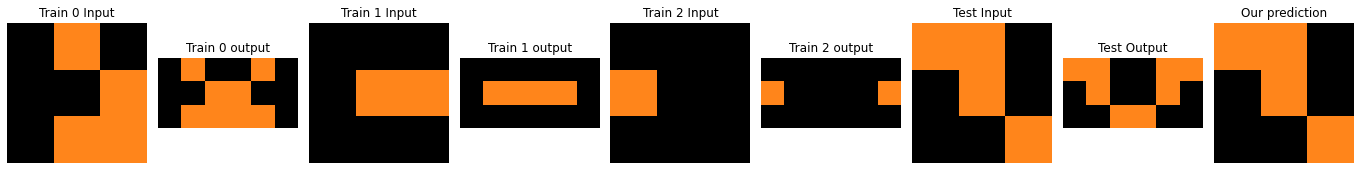

traininput_objects: [[0, 3, 1, 3, 3, 2, 7, 4, 7, 4, 7, 4, 1, 4]]
trainoutput_objects: [[0, 3, 1, 5, 3, 4, 7, 8, 7, 8, 7, 8, 1, 8]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
318
contraction:
[[0], [0], [0], [0]] [[(3, 3)], [(8, 11)], [(2, 4)], [(9, 8)]]


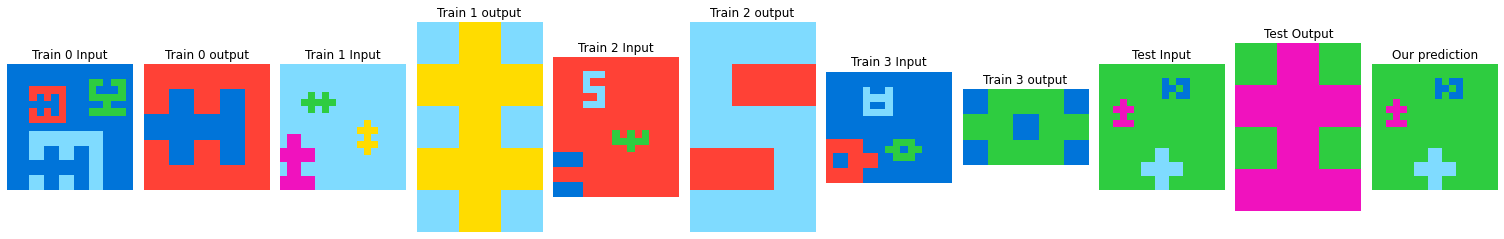

traininput_objects: [[9, 17, 3, 13, 8, 10, 8, 48, 8, 48, 1, 32, 2, 80], [0, 17, 0, 17, 17, 17, 1, 207, 1, 207, 2, 17, 4, 289], [3, 8, 3, 8, 5, 5, 2, 17, 2, 17, 1, 8, 2, 25], [2, 7, 11, 16, 5, 5, 3, 17, 3, 17, 1, 8, 2, 25], [15, 17, 7, 9, 2, 2, 8, 4, 8, 4, 8, 4, 1, 4], [15, 17, 3, 5, 2, 2, 8, 4, 8, 4, 8, 4, 1, 4]]
trainoutput_objects: [[0, 5, 0, 5, 5, 5, 2, 17, 2, 17, 1, 8, 2, 25], [1, 4, 0, 4, 3, 4, 1, 8, 1, 8, 2, 4, 2, 12]]
is_out_obj_in_in_objs: [(True, 2), (False, -1)]
overall_movement: [(True, (3, 3)), (False, ())]
325
contraction:
[[0, 5, 4, 5, 0, 3, 4, 3, 0], [0, 5, 4, 3, 3, 4, 5, 0, 0, 5, 4, 3, 3, 4, 5, 0], [0, 5, 4, 5, 0, 3, 4, 3, 0, 3, 4, 5, 0, 5, 4, 5, 0, 3]] [[(0, 0), (0, 2), (0, 4), (2, 0), (2, 2), (2, 4), (4, 0), (4, 2), (4, 4)], [(0, 0), (0, 2), (0, 4), (0, 6), (2, 0), (2, 2), (2, 4), (2, 6), (4, 0), (4, 2), (4, 4), (4, 6), (6, 0), (6, 2), (6, 4), (6, 6)], [(0, 0), (0, 2), (0, 4), (2, 0), (2, 2), (2, 4), (4, 0), (4, 2), (4, 4), (6, 0), (6, 2), (6, 4), (8, 0), (8, 2), (8, 

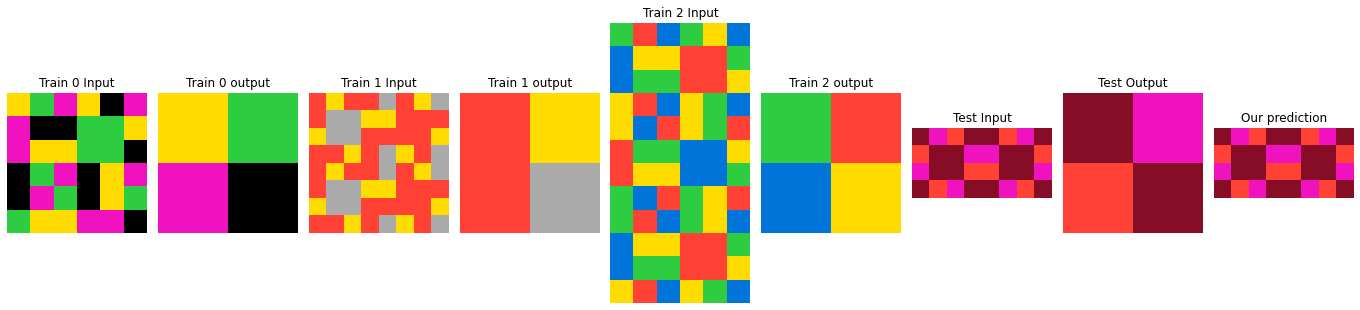

traininput_objects: [[1, 3, 3, 5, 2, 2, 3, 4, 3, 4, 3, 4, 1, 4], [2, 3, 1, 3, 1, 2, 4, 2, 4, 2, 4, 2, 1, 2], [3, 5, 0, 1, 2, 1, 0, 2, 0, 2, 0, 2, 1, 2], [1, 2, 1, 3, 1, 2, 0, 2, 0, 2, 0, 2, 1, 2], [3, 5, 3, 4, 2, 1, 0, 2, 0, 2, 0, 2, 1, 2], [1, 3, 0, 1, 2, 1, 6, 2, 6, 2, 6, 2, 1, 2], [3, 5, 4, 5, 2, 1, 4, 2, 4, 2, 4, 2, 1, 2], [5, 6, 1, 3, 1, 2, 4, 2, 4, 2, 4, 2, 1, 2], [5, 6, 3, 5, 1, 2, 6, 2, 6, 2, 6, 2, 1, 2], [3, 5, 1, 3, 2, 2, 6, 2, 3, 2, 3, 2, 2, 4], [3, 5, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 2, 4], [0, 1, 3, 4, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [0, 1, 0, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [1, 2, 5, 6, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1], [0, 1, 5, 6, 1, 1, 6, 1, 6, 1, 6, 1, 1, 1], [0, 1, 4, 5, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1], [4, 5, 5, 6, 1, 1, 3, 1, 3, 1, 3, 1, 1, 1], [5, 6, 5, 6, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1], [2, 3, 5, 6, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1], [0, 1, 2, 3, 1, 1, 6, 1, 6, 1, 6, 1, 1, 1], [3, 4, 5, 6, 1, 1, 6, 1, 6, 1, 6, 1, 1, 1], [5, 6, 0, 1, 1, 1, 3, 1, 3, 1, 3, 1, 1, 1], [0, 1, 1, 2

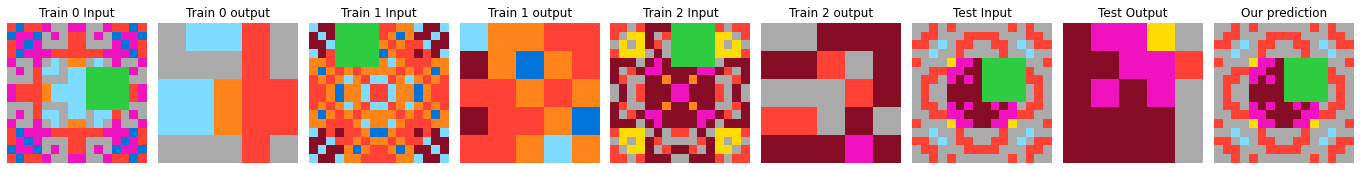

traininput_objects: [[5, 10, 9, 14, 5, 5, 3, 25, 3, 25, 3, 25, 1, 25], [5, 11, 5, 9, 6, 4, 8, 18, 8, 18, 5, 6, 2, 24], [9, 12, 4, 7, 3, 3, 5, 6, 5, 6, 8, 3, 2, 9], [12, 15, 12, 15, 3, 3, 1, 3, 6, 6, 1, 3, 2, 9], [4, 7, 4, 7, 3, 3, 5, 6, 5, 6, 8, 3, 2, 9], [1, 4, 1, 4, 3, 3, 1, 3, 6, 6, 1, 3, 2, 9], [1, 4, 12, 15, 3, 3, 1, 3, 6, 6, 1, 3, 2, 9], [12, 15, 1, 4, 3, 3, 1, 3, 6, 6, 1, 3, 2, 9], [11, 15, 1, 5, 4, 4, 6, 8, 6, 8, 1, 3, 3, 16], [1, 5, 11, 15, 4, 4, 6, 8, 6, 8, 1, 3, 3, 16], [11, 15, 11, 15, 4, 4, 6, 8, 6, 8, 1, 3, 3, 16], [1, 5, 1, 5, 4, 4, 6, 8, 6, 8, 1, 3, 3, 16], [10, 12, 9, 10, 2, 1, 5, 2, 5, 2, 5, 2, 1, 2], [2, 4, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [7, 9, 14, 15, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [7, 9, 0, 1, 2, 1, 6, 2, 6, 2, 6, 2, 1, 2], [15, 16, 12, 14, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2], [7, 9, 4, 5, 2, 1, 7, 2, 7, 2, 7, 2, 1, 2], [12, 14, 15, 16, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [12, 14, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2], [15, 16, 2, 4, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2], [0, 1, 

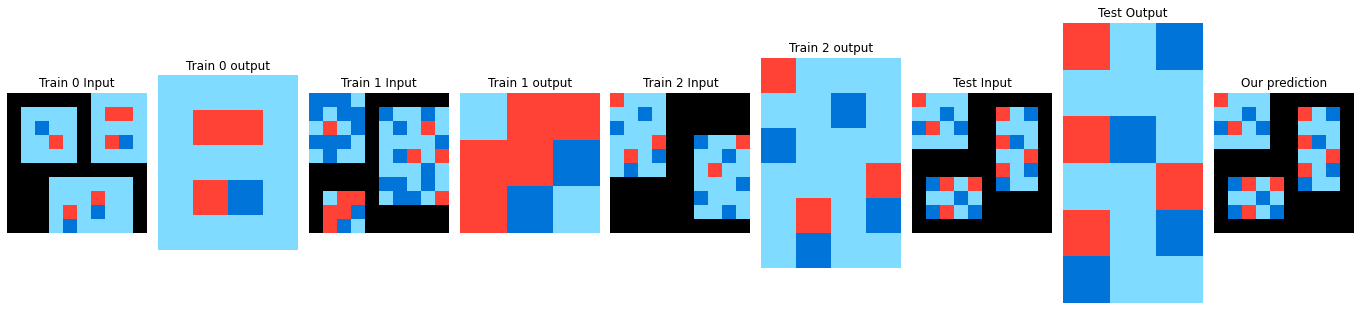

traininput_objects: [[0, 10, 0, 10, 10, 10, 0, 40, 8, 50, 1, 4, 4, 100], [1, 2, 7, 9, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2], [6, 10, 3, 9, 4, 6, 8, 20, 8, 20, 1, 2, 3, 24], [8, 9, 6, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [3, 4, 3, 4, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [3, 4, 7, 8, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [2, 3, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [7, 8, 6, 7, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [3, 4, 8, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [8, 9, 4, 5, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [9, 10, 4, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 5, 1, 5, 4, 4, 8, 14, 8, 14, 1, 1, 3, 16], [0, 5, 6, 10, 5, 4, 8, 16, 8, 16, 1, 1, 3, 20]]
trainoutput_objects: [[1, 2, 1, 3, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2], [3, 4, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [3, 4, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [0, 5, 0, 4, 5, 4, 8, 16, 8, 16, 1, 1, 3, 20]]
is_out_obj_in_in_objs: [(True, 1), (True, 3), (True, 4), (True, 12)]
overall_movement: [(True, (0, 6)), (True, (5, 4)), (True, (0, 2)), (True, (0, 6))]
375
expansion:
[[0, 4, 0, 4], [0, 

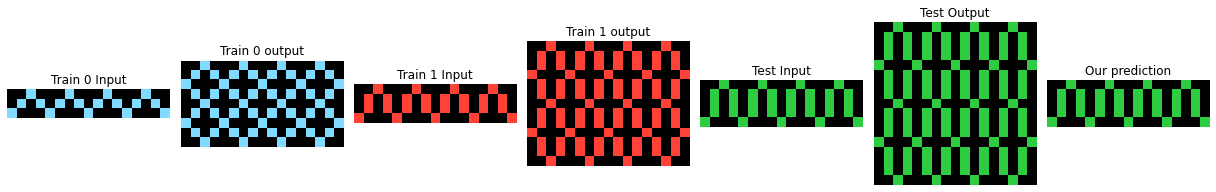

traininput_objects: [[0, 3, 0, 17, 3, 17, 8, 17, 8, 17, 8, 17, 1, 17]]
trainoutput_objects: [[0, 9, 0, 17, 9, 17, 8, 54, 8, 54, 8, 54, 1, 54]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
393
contraction:
[[5, 1, 5, 1, 0, 3, 0, 3, 5, 1, 0, 3], [], [2, 3, 2, 3, 5, 0, 5, 0, 2, 3, 5, 0]] [[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 2), (3, 3)], [], [(1, 1), (1, 2), (1, 4), (1, 5), (2, 1), (2, 2), (2, 4), (2, 5), (4, 1), (4, 2), (5, 1), (5, 2)]]


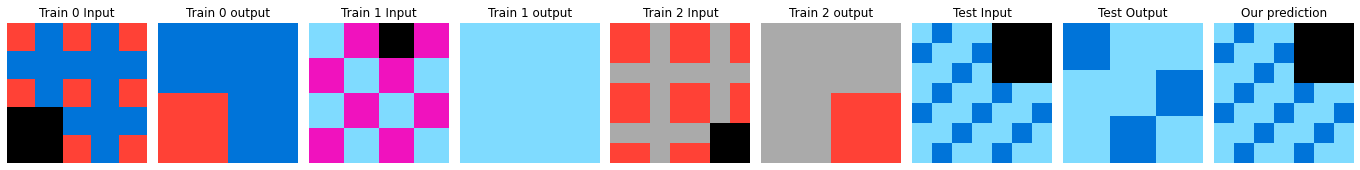

traininput_objects: [[3, 5, 0, 2, 2, 2, 0, 4, 0, 4, 0, 4, 1, 4], [0, 5, 0, 5, 5, 5, 1, 13, 1, 13, 0, 4, 3, 25], [4, 5, 2, 3, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [0, 1, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [4, 5, 4, 5, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [2, 3, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [2, 3, 2, 3, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [0, 1, 2, 3, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [2, 3, 4, 5, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [0, 1, 4, 5, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1]]
trainoutput_objects: [[1, 2, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1], [0, 2, 0, 2, 2, 2, 1, 3, 1, 3, 2, 1, 2, 4]]
is_out_obj_in_in_objs: [(True, 2), (False, -1)]
overall_movement: [(True, (3, 2)), (False, ())]
399
contraction:
[[7, 3, 1, 5, 4, 6], [5, 1, 4, 7, 3], [4, 6, 2, 3, 5, 1]] [[(0, 1), (1, 0), (18, 0), (18, 19), (19, 1), (19, 18)], [(6, 8), (6, 11), (8, 13), (11, 13), (13, 11)], [(4, 9), (4, 10), (9, 4), (9, 15), (10, 4), (10, 15)]]


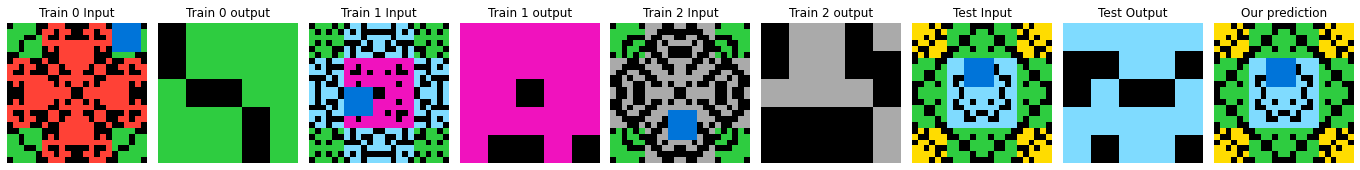

traininput_objects: [[18, 24, 0, 6, 6, 6, 3, 27, 3, 27, 3, 27, 1, 27], [0, 6, 0, 6, 6, 6, 3, 27, 3, 27, 3, 27, 1, 27], [18, 24, 18, 24, 6, 6, 3, 27, 3, 27, 3, 27, 1, 27], [0, 5, 18, 23, 5, 5, 1, 25, 1, 25, 1, 25, 1, 25], [0, 24, 0, 24, 24, 24, 2, 272, 2, 272, 1, 25, 3, 386], [5, 6, 18, 22, 1, 4, 3, 4, 3, 4, 3, 4, 1, 4], [1, 5, 23, 24, 4, 1, 3, 4, 3, 4, 3, 4, 1, 4]]
trainoutput_objects: [[0, 5, 0, 5, 5, 5, 3, 19, 3, 19, 3, 19, 1, 19]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]


In [11]:
tests = 0
for n in range(400):
    this_task = this_analysis[n]
    if this_task.is_out_in_rel and all([x[2] == this_task.out_in_rel[0][2] for x in this_task.out_in_rel]):
        scenario = this_task.out_in_rel[0][2]
        arrangements = [[j[0] for j in i[1]] for i in this_task.out_in_rel]
        steps = [[j[1] for j in i[1]] for i in this_task.out_in_rel]
        if scenario == 'contraction':
            print(n)
            print('contraction:')
            print(arrangements, steps)
            tests += 1
            plot_task_eval(tt[n], this_task.testinputs)
            print('traininput_objects:', this_task.traininput_objects[0])
            print('trainoutput_objects:', this_task.trainoutput_objects[0])
            print('is_out_obj_in_in_objs:', [is_out_obj_in_in_objs(x, this_task.traininput_objects[0]) for x in this_task.trainoutput_objects[0]])
            print('overall_movement:', overall_movement(this_task.trainoutput_objects[0], this_task.traininput_objects[0]))
        elif scenario == 'expansion' and all([len(x[1]) >= 2 for x in this_task.out_in_rel]):
            print(n)
            print('expansion:')
            print(arrangements, steps)
            tests += 1
            plot_task_eval(tt[n], this_task.testinputs)
            print('traininput_objects:', this_task.traininput_objects[0])
            print('trainoutput_objects:', this_task.trainoutput_objects[0])
            print('is_out_obj_in_in_objs:', [is_out_obj_in_in_objs(x, this_task.traininput_objects[0]) for x in this_task.trainoutput_objects[0]])
            print('overall_movement:', overall_movement(this_task.trainoutput_objects[0], this_task.traininput_objects[0]))

173
is_out_in_rel: True
(True, [(0, (6, 3))], 'contraction')
trainoutput_dims_in_traininputs_objects: True
this_task.traininput_objects: [[6, 8, 3, 7, 2, 4, 6, 6, 6, 6, 6, 6, 1, 6], [1, 3, 1, 5, 2, 4, 2, 5, 2, 5, 2, 5, 1, 5], [2, 4, 6, 9, 2, 3, 7, 4, 7, 4, 7, 4, 1, 4]]
this_task.trainoutput_objects: [[0, 2, 0, 4, 2, 4, 6, 6, 6, 6, 6, 6, 1, 6]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (6, 3))]


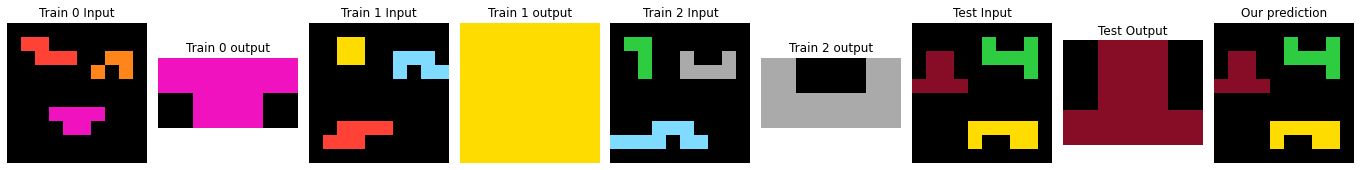

====
299
is_out_in_rel: True
(True, [(0, (1, 1))], 'contraction')
trainoutput_dims_in_traininputs_objects: True
this_task.traininput_objects: [[1, 5, 1, 4, 4, 3, 2, 8, 2, 8, 2, 8, 1, 8], [2, 5, 8, 11, 3, 3, 1, 6, 1, 6, 1, 6, 1, 6], [1, 3, 5, 7, 2, 2, 3, 3, 3, 3, 3, 3, 1, 3]]
this_task.trainoutput_objects: [[0, 4, 0, 3, 4, 3, 2, 8, 2, 8, 2, 8, 1, 8]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (1, 1))]


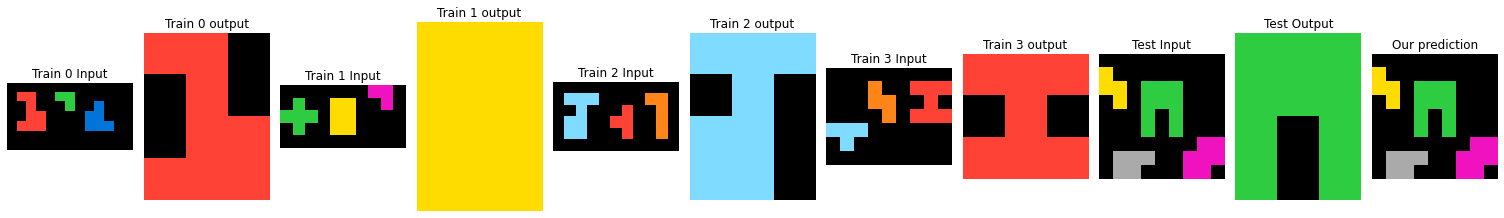

====
324
is_out_in_rel: False
(False, [], 'non_dimension_related')
trainoutput_dims_in_traininputs_objects: False
this_task.traininput_objects: [[1, 5, 1, 4, 4, 3, 8, 8, 8, 8, 8, 8, 1, 8], [6, 9, 4, 7, 3, 3, 8, 6, 8, 6, 8, 6, 1, 6], [10, 13, 1, 5, 3, 4, 8, 6, 8, 6, 8, 6, 1, 6], [12, 14, 7, 9, 2, 2, 8, 4, 8, 4, 8, 4, 1, 4]]
this_task.trainoutput_objects: [[0, 4, 0, 4, 4, 4, 8, 4, 8, 4, 8, 4, 1, 4]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]


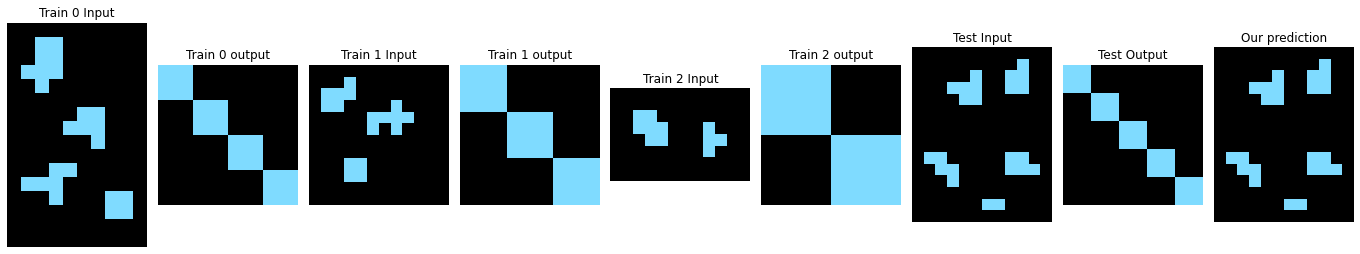

====
395
is_out_in_rel: False
(False, [], 'non_dimension_related')
trainoutput_dims_in_traininputs_objects: True
this_task.traininput_objects: [[3, 7, 10, 13, 4, 3, 2, 10, 2, 10, 2, 10, 1, 10], [9, 11, 9, 11, 2, 2, 4, 2, 4, 2, 4, 2, 1, 2], [2, 9, 0, 7, 7, 7, 2, 24, 2, 24, 4, 2, 2, 26]]
this_task.trainoutput_objects: [[0, 7, 0, 7, 7, 7, 4, 26, 4, 26, 4, 26, 1, 26]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]


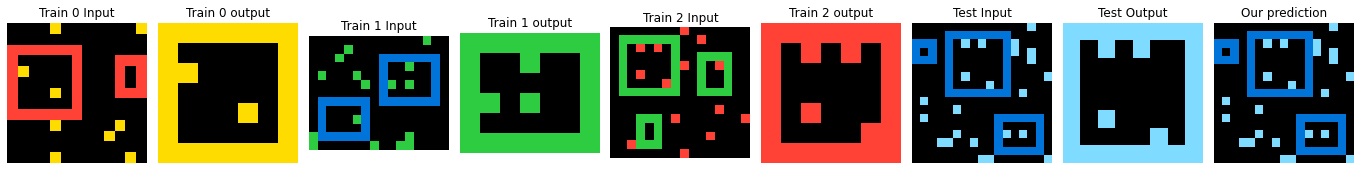

====


In [8]:
expansion_contractiosn = 0
for n in range(400):
    this_task = this_analysis[n]
    if (this_task.is_out_in_rel and this_task.dimension_status == 'deduced' and not this_task.is_same_dim_couple and (this_task.is_sim_int_div or this_task.is_sim_internal_int_div)) or this_task.is_one_object_in_output:
        print(n)
        print('is_out_in_rel:', this_task.is_out_in_rel)
        print(this_task.out_in_rel[0])    
        print('trainoutput_dims_in_traininputs_objects:', this_task.trainoutput_dims_in_traininputs_objects)
        print('this_task.traininput_objects:', this_task.traininput_objects[0])
        print('this_task.trainoutput_objects:', this_task.trainoutput_objects[0])
        print('is_out_obj_in_in_objs:', [is_out_obj_in_in_objs(x, this_task.traininput_objects[0]) for x in this_task.trainoutput_objects[0]])
        print('overall_movement:', overall_movement(this_task.trainoutput_objects[0], this_task.traininput_objects[0]))
        plot_task_eval(tt[n], this_task.testinputs)
        expansion_contractiosn += 1
        print('====')

In [23]:
expansion_contractiosn

83

In [ ]:
opportunities = 0
for n in range(len(this_analysis)) :
    this_task = this_analysis[n]
    if this_task.dimension_status == 'undeduced':
        plot_task_eval(tt[n], this_task.testinputs)
        print(n)
        print('is_out_in_rel:', this_task.is_out_in_rel)
        print(this_task.row_dim_ouputs, this_task.col_dim_ouputs, this_task.is_one_row, this_task.is_one_col, this_task.is_one_row_or_column, this_task.is_unique_train_outputs, this_task.bg_in_unique_train_outputs)
        print('Input dimensions: ', this_task.traininputs_shapes[0])
        print('Output dimensions: ', this_task.trainoutputs_shapes[0])
        num_cells_traininputs = [x[0] * x[1] for x in this_task.traininputs_shapes]
        num_cells_trainoutputs = [x[0] * x[1] for x in this_task.trainoutputs_shapes]
        print('num_calls:', num_cells_traininputs[0], num_cells_trainoutputs[0])
        freqs_traininputs = [np.unique(x, return_counts = True) for x in this_task.traininputs]
        freqs_trainoutputs = [np.unique(x, return_counts = True) for x in this_task.trainoutputs]
        freqs_traininputs = [sort_two_lists_based_on_second(x[0].tolist(), x[1].tolist()) for x in freqs_traininputs]
        freqs_trainoutputs = [sort_two_lists_based_on_second(x[0].tolist(), x[1].tolist()) for x in freqs_trainoutputs]
        print('freqs:', freqs_traininputs,freqs_trainoutputs[0])
        print('bg: ', this_task.bg)
        print('Traininput_objects:', this_task.traininput_objects[0])
        print('traininput_ex:')
        assess_connected_components_from_coordinates(this_task.traininputs[0], this_task.global_bg, this_task.bg)
        print('Trainotput_objects:', this_task.trainoutput_objects[0])
        print('trainoutput_ex:')
        assess_connected_components_from_coordinates(this_task.trainoutputs[0], this_task.global_bg, this_task.bg)
        print('====')


In [ ]:
# Action:
# single solutions
# this_task.out_in_rel, this_task.is_out_in_rel, 
# this_task.traininput_objects_dims, this_task.traininput_objects

# 106: dim is input dim * number of nonbg: dimensions determined by len of freq_nonbg (2, 3, 4)
# 299 (dim and soln): output the object with the most frequent nonbg: use freqs of traininputs and traininput_objects to find that
# the most frequent value of the output object is the most frequent value in the freqs_nonbg. We thought 173
# could be solved this way but it turns that the next level is to spit multiple objects in the scenario the system 
# can't find a rule (so, 299 wull be solved logically, 173 will be solved stochatically/heuristically) until
# the system evolves enough
# 212 (dim, needs sense of orientation for soln): the only square
# 220 true convolve, expansion: (dim, is_sim_internal_int_div) multiply the current dimension with the 
# number of bg find out where this is

# 246: interesting, the dimension is the maximum frequenct
# multiplied by 1 if it is not repeated or it is multiplied by its repetiton notice it is not the value
# 268, 288 (output dim is the input dim * num_unique_nonbg): (dim) dim is multiplied with the number of unique nonbg
# 274: output dim is a square of a side = square root of row dim of the input
# 294(output_dim = [input_x*input_y/2, input_y], 397([input_y*num_unique_nobg, input_y*num_unique_nobg]): single row expands to half the columns, single row expoands to a square of largest dim multiplied with 
# the number of nonbg
# 338 (0utput_dim = [1, num_nonbg]): (dim and soln): dim is one row and num of columns == frequency of the only unqiue nonbg
#

# Multiple solutions: have to do this ya man
# 187: you have multiples from convolutions, it is just not clear whether why split
# horizontally or vertically (give two solutions in this case)
# 173 : thought we got it, it is more difficult thant this


# incomplete implementation:
# 215 shows that the find_objects of scipy can't solve these porblems, Our colvolution
# method is not applicable to unseen cases since it starts with the target. we need to
# implement the test compatiblel version of convolve that spits objects not identified
# by scipy and this starts with bridging the gap between scipy and the real world object 
# detection which we started with an easy search convolution.
# 173 : thought we got it, it is more difficult thant this
# 364 similar situation, better object detection is going to be needed
# 395 is the same


# Intractable at the moment.
# 114, 177: row_dim_ouputs, col_dim_ouputs, is_one_row
#      the non-1 dim is the len of freqs (3, 3, 4) which is determined
# based on whether colors are stacked vertically of horizontally
# we have a hige gab of prior knowledge on orientation
# in theory this should be easy to implement
# 20 (unique output, true contraction, other infor is irrelevant), 45: dimensions and solutions are determined by identifying horizontal
# and or vertical lines of nonbg or a bg respectively.

# 134: return rectangle with the largest number of red dots and extend
# these dots into lines
# 304 is similar but returns the rectangle (blue) with a few red dots and go ahead and extend them
# 

# 95, 169, 183, 217, 232, 238, 243,  is sort of higher rank
